# Product-Level Retail Demand Forecasting

This notebook accompanies an MSc dissertation comparing statistical, machine-learning and deep-learning approaches for weekly product-level retail demand forecasting using the **Online Retail II** dataset.

**Models:** Naive, Seasonal Naive, Linear Regression, XGBoost, LSTM and ARIMA.

**Evaluation:** chronological train/validation/final-test design with rolling one-step-ahead final evaluation. Model-development decisions were locked before the final test period was evaluated.

**Dataset:** Chen, D. (2012), *Online Retail II*, UCI Machine Learning Repository. DOI: https://doi.org/10.24432/C5CG6D

Official dataset page: https://archive.ics.uci.edu/dataset/502/online+retail+ii

> The raw dataset is not redistributed in this repository. Download it from UCI and place the Excel file at `data/online_retail_II.xlsx` (or upload it to `/content/online_retail_II.xlsx` in Google Colab).

**Note:** saved outputs are intentionally retained so that the documented dissertation results are visible directly on GitHub without rerunning the notebook.


# Online Retail Demand Forecasting

## Data Loading, Quality Inspection, Anomaly Analysis and Cleaning

This notebook documents the first stage of my dissertation analysis.  
The aim of this stage is to understand the dataset, identify data quality problems, investigate unusual records, and create a clean dataset that can later be used for demand forecasting.

The dataset contains online retail transactions from two consecutive periods:

- 2009–2010
- 2010–2011

At this stage, I do not build forecasting models yet. First, I make sure that the data represents real product demand as accurately as possible.


## 1. Importing the Libraries

I import the main libraries that I need for data handling and visualisation.

- `pandas` is used for reading, cleaning, and analysing the data.
- `numpy` is used for numerical operations.
- `matplotlib` is used for basic charts.

I also change the display settings so that all columns are visible and numerical outputs are easier to read.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 2. Reading the Excel File

The dataset is stored in one Excel file with two worksheets.  
Before loading the full data, I first check the worksheet names to confirm their structure.


In [174]:
from pathlib import Path

# Download Online Retail II from the official UCI repository and place it here.
file_path = Path("data/online_retail_II.xlsx")

# Google Colab fallback if the Excel file is uploaded directly to /content.
if not file_path.exists() and Path("/content/online_retail_II.xlsx").exists():
    file_path = Path("/content/online_retail_II.xlsx")

if not file_path.exists():
    raise FileNotFoundError(
        "Dataset not found. Download Online Retail II from UCI and place it at "
        "data/online_retail_II.xlsx (or upload it to /content in Colab)."
    )

excel_file = pd.ExcelFile(file_path)

print("Sheet names:")
print(excel_file.sheet_names)


Sheet names:
['Year 2009-2010', 'Year 2010-2011']


The file contains two worksheets:

- `Year 2009-2010`
- `Year 2010-2011`

I load them separately because I want to check their sizes before combining them.


In [175]:
df_2009_2010 = pd.read_excel(
    file_path,
    sheet_name="Year 2009-2010"
)

df_2010_2011 = pd.read_excel(
    file_path,
    sheet_name="Year 2010-2011"
)

print("2009-2010 shape:", df_2009_2010.shape)
print("2010-2011 shape:", df_2010_2011.shape)

2009-2010 shape: (525461, 8)
2010-2011 shape: (541910, 8)


### Observed result

- The 2009–2010 worksheet contains **525,461 rows and 8 columns**.
- The 2010–2011 worksheet contains **541,910 rows and 8 columns**.

Together, the dataset contains more than one million transaction records.


## 3. Initial Data Inspection

I display the first rows of both worksheets to confirm that the columns and data structure are the same.


In [176]:
display(df_2009_2010.head())
display(df_2010_2011.head())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


The two worksheets contain the same variables:

- `Invoice`
- `StockCode`
- `Description`
- `Quantity`
- `InvoiceDate`
- `Price`
- `Customer ID`
- `Country`

Because the structure is the same, they can be combined.


## 4. Combining the Two Periods

Before combining the worksheets, I create a new variable named `Period`.  
This allows me to keep the source period of each transaction after merging the datasets.


In [177]:
df_2009_2010["Period"] = "2009-2010"
df_2010_2011["Period"] = "2010-2011"

df = pd.concat(
    [df_2009_2010, df_2010_2011],
    ignore_index=True
)

print("Combined dataset shape:", df.shape)
display(df.head())

Combined dataset shape: (1067371, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Period
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom,2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom,2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom,2009-2010


### Observed result

The combined dataset contains:

- **1,067,371 rows**
- **9 columns**

The new ninth column is `Period`.


## 5. Checking the Dataset Structure

I use `df.info()` to inspect the number of non-missing values and the data type of each column.


In [178]:
print("Dataset information:\n")
df.info()

Dataset information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
 8   Period       1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 73.3+ MB


I also print the dataset dimensions and column names in a simpler format.


In [179]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 1067371
Number of columns: 9

Column names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Period']


The `InvoiceDate` variable is already stored as a datetime variable, which is useful for future daily or weekly aggregation.


# 2. Data Quality Inspection

In this section, I check the main data quality problems before making any cleaning decision.

I examine:

- missing values,
- duplicate records,
- data types,
- negative or zero quantities,
- negative or zero prices,
- cancelled invoices.


## 6. Missing Values

I calculate both the number and percentage of missing values for each column.  
This helps me understand which variables may require special treatment.


In [180]:
missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_values = missing_values.sort_values(
    by="Missing Count",
    ascending=False
)

display(missing_values)

,Missing Count,Missing Percentage
Customer ID,243007,22.77
Description,4382,0.41
Invoice,0,0.00
Quantity,0,0.00
StockCode,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Country,0,0.00
Period,0,0.00


### Observed result

The main missing-value problems are:

- `Customer ID`: **243,007 missing values**, around **22.77%**
- `Description`: **4,382 missing values**, around **0.41%**

I do not immediately remove rows with missing `Customer ID` because this dissertation focuses on product-level demand, not customer behaviour.


## 7. Duplicate Records

I check for rows that are completely identical.  
Exact duplicates may create double counting and can distort total demand.


In [181]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print("Number of duplicate rows:", duplicate_count)
print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

Number of duplicate rows: 12133
Duplicate percentage: 1.14%


### Observed result

The dataset contains:

- **12,133 duplicate rows**
- around **1.14%** of the full dataset

These exact duplicates will be removed during cleaning.


## 8. Data Types

I create a simple table of data types to make sure that each variable is stored correctly.


In [182]:
data_types = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values
})

display(data_types)

,Column,Data Type
0,Invoice,object
1,StockCode,object
2,Description,object
3,Quantity,int64
4,InvoiceDate,datetime64[ns]
5,Price,float64
6,Customer ID,float64
7,Country,object
8,Period,object


The important data types are appropriate:

- `Quantity` is integer.
- `Price` is float.
- `InvoiceDate` is datetime.
- Product, invoice, description, country, and period variables are stored as object/string-type data.


## 9. Numerical Summary of Quantity and Price

I examine descriptive statistics for `Quantity` and `Price`.

This helps identify unusual minimum and maximum values.


In [183]:
display(
    df[["Quantity", "Price"]].describe().T
)

,count,mean,std,min,25%,50%,75%,max
Quantity,"1,067,371.00",9.94,172.71,"-80,995.00",1.00,3.00,10.00,"80,995.00"
Price,"1,067,371.00",4.65,123.55,"-53,594.36",1.25,2.10,4.15,"38,970.00"


### Observed result

The summary shows extreme values:

- Quantity minimum: **-80,995**
- Quantity maximum: **80,995**
- Price minimum: **-53,594.36**
- Price maximum: **38,970.00**

These extreme values suggest cancellations, returns, stock corrections, accounting adjustments, or data entry problems.


## 10. Checking Non-Positive Quantity and Price Values

For demand forecasting, positive quantity and valid price values are important.  
I count negative and zero values separately before deciding how to clean them.


In [184]:
quality_summary = pd.DataFrame({
    "Condition": [
        "Quantity below zero",
        "Quantity equal to zero",
        "Price below zero",
        "Price equal to zero"
    ],
    "Number of Rows": [
        (df["Quantity"] < 0).sum(),
        (df["Quantity"] == 0).sum(),
        (df["Price"] < 0).sum(),
        (df["Price"] == 0).sum()
    ]
})

display(quality_summary)

,Condition,Number of Rows
0,Quantity below zero,22950
1,Quantity equal to zero,0
2,Price below zero,5
3,Price equal to zero,6202


### Observed result

- Negative quantity rows: **22,950**
- Zero quantity rows: **0**
- Negative price rows: **5**
- Zero price rows: **6,202**

These records require investigation because they may not represent actual customer demand.


## 11. Identifying Cancelled Invoices

In this dataset, cancelled invoices usually begin with the letter `C`.

I convert the invoice variable to string and create a Boolean variable named `CancelledInvoice`.


In [185]:
df["Invoice"] = df["Invoice"].astype(str)

df["CancelledInvoice"] = df["Invoice"].str.startswith("C")

cancelled_count = df["CancelledInvoice"].sum()
cancelled_percentage = (cancelled_count / len(df)) * 100

print("Cancelled invoice rows:", cancelled_count)
print(f"Cancelled invoice percentage: {cancelled_percentage:.2f}%")

Cancelled invoice rows: 19494
Cancelled invoice percentage: 1.83%


### Observed result

The dataset contains:

- **19,494 cancelled invoice rows**
- around **1.83%** of the dataset


I display sample cancelled transactions to confirm their structure.


In [186]:
display(
    df[df["CancelledInvoice"]].head(10)
)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Period,CancelledInvoice
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia,2009-2010,True
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,"16,321.00",Australia,2009-2010,True
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,"16,321.00",Australia,2009-2010,True
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,"16,321.00",Australia,2009-2010,True
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia,2009-2010,True
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,"16,321.00",Australia,2009-2010,True
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,"16,321.00",Australia,2009-2010,True
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,"16,321.00",Australia,2009-2010,True
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia,2009-2010,True
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,"17,592.00",United Kingdom,2009-2010,True


The examples show that cancelled invoices usually have negative quantities, which confirms that they represent returns or reversed transactions.


## 12. Relationship Between Cancellation and Negative Quantity

I create a cross-tabulation to compare cancellation codes and negative quantities.

This helps me check whether all negative quantities are explained by cancelled invoices.


In [187]:
cancellation_quantity_table = pd.crosstab(
    df["CancelledInvoice"],
    df["Quantity"] < 0,
    rownames=["Cancelled Invoice"],
    colnames=["Negative Quantity"]
)

display(cancellation_quantity_table)

Negative Quantity,False,True
Cancelled Invoice,,
False,1044420,3457
True,1,19493


### Observed result

- 19,493 rows are both cancelled and negative.
- 1 cancelled row has a positive quantity.
- 3,457 negative-quantity rows do not begin with `C`.

This means that some negative records represent other processes such as stock loss, damages, missing items, or manual inventory corrections.


# 3. Investigation of Anomalous Transactions

Before removing unusual records, I investigate them in more detail.  
This is important because cleaning decisions should be based on evidence, not only on numerical rules.


## 13. Negative Quantity Without Cancellation Code

I isolate records with negative quantity but without a cancellation invoice code.


In [188]:
negative_non_cancelled = df[
    (df["Quantity"] < 0) &
    (~df["CancelledInvoice"])
]

print("Negative quantity without cancellation code:",
      len(negative_non_cancelled))

display(negative_non_cancelled.head(20))

Negative quantity without cancellation code: 3457


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Period,CancelledInvoice
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom,2009-2010,False
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom,2009-2010,False
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom,2009-2010,False
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom,2009-2010,False
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.00,NaN,United Kingdom,2009-2010,False
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.00,NaN,United Kingdom,2009-2010,False
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.00,NaN,United Kingdom,2009-2010,False
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.00,NaN,United Kingdom,2009-2010,False
4538,489820,21133,invcd as 84879?,-720,2009-12-02 13:23:00,0.00,NaN,United Kingdom,2009-2010,False
4566,489821,85049G,NaN,-240,2009-12-02 13:25:00,0.00,NaN,United Kingdom,2009-2010,False


The examples include descriptions such as:

- `lost`
- `damages`
- `short`
- `missing`
- `sold as gold`
- mixed or corrected product codes

Most of these rows also have zero price and missing customer information.  
They appear to be stock-control records rather than customer sales.


I check the most common descriptions and stock codes in this group.


In [189]:
print("Most common descriptions:")
display(
    negative_non_cancelled["Description"]
    .value_counts(dropna=False)
    .head(20)
)

print("\nMost common stock codes:")
display(
    negative_non_cancelled["StockCode"]
    .value_counts()
    .head(20)
)

Most common descriptions:


,count
Description,
NaN,2689
check,123
damages,84
?,83
damaged,78
missing,27
sold as set on dotcom,20
Damaged,17
smashed,9



Most common stock codes:


,count
StockCode,
22423,12
46000M,6
22719,6
82494L,6
84016,5
85017A,5
21830,5
85175,5
47566B,5


### Observed result

Most of these descriptions are missing or contain terms such as:

- `check`
- `damages`
- `damaged`
- `missing`
- `smashed`
- `thrown away`
- `unsaleable`

Therefore, these records should not be treated as real demand.


## 14. Cancelled Invoice With Positive Quantity

There is one cancelled invoice with a non-negative quantity.  
I display it separately because it does not follow the normal cancellation pattern.


In [190]:
cancelled_positive = df[
    (df["CancelledInvoice"]) &
    (df["Quantity"] >= 0)
]

display(cancelled_positive)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Period,CancelledInvoice
76799,C496350,M,Manual,1,2010-02-01 08:24:00,373.57,NaN,United Kingdom,2009-2010,True


The record has:

- description: `Manual`
- quantity: 1
- a high price
- missing Customer ID

This appears to be a manual or administrative transaction, not a product sale.


## 15. Negative Prices

I inspect the five rows with negative prices.


In [191]:
negative_price_rows = df[df["Price"] < 0]

display(negative_price_rows)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Period,CancelledInvoice
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,"-53,594.36",NaN,United Kingdom,2009-2010,False
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,"-44,031.79",NaN,United Kingdom,2009-2010,False
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,"-38,925.87",NaN,United Kingdom,2009-2010,False
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,"-11,062.06",NaN,United Kingdom,2010-2011,False
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,"-11,062.06",NaN,United Kingdom,2010-2011,False


### Observed result

All five rows have:

- StockCode `B`
- Description `Adjust bad debt`

These are accounting adjustments and do not represent customer demand.


## 16. Zero-Price Transactions

I inspect rows where the price is zero.


In [192]:
zero_price_rows = df[df["Price"] == 0]

print("Zero-price rows:", len(zero_price_rows))

display(zero_price_rows.head(20))

Zero-price rows: 6202


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Period,CancelledInvoice
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom,2009-2010,False
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom,2009-2010,False
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom,2009-2010,False
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom,2009-2010,False
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.00,NaN,United Kingdom,2009-2010,False
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.00,NaN,United Kingdom,2009-2010,False
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.00,NaN,United Kingdom,2009-2010,False
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.00,NaN,United Kingdom,2009-2010,False
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.00,NaN,United Kingdom,2009-2010,False
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.00,NaN,United Kingdom,2009-2010,False


Many zero-price rows are related to:

- missing descriptions,
- stock checks,
- damages,
- lost products,
- manual corrections,
- free or administrative entries.

Some rows may look like products, but a zero price makes their sales meaning uncertain.  
For a clean demand dataset, I later remove all non-positive price records.


I check the most common descriptions among zero-price rows.


In [193]:
display(
    zero_price_rows["Description"]
    .value_counts(dropna=False)
    .head(20)
)

,count
Description,
NaN,4382
check,162
?,92
damages,84
damaged,81
found,28
missing,27
sold as set on dotcom,20
Damaged,17


The largest group contains missing descriptions.  
Other common descriptions include `check`, `damages`, `missing`, `adjustment`, and similar non-sales terms.


## 17. Missing Product Descriptions

I inspect the rows with missing product descriptions.


In [194]:
missing_description_rows = df[df["Description"].isna()]

print("Rows with missing description:",
      len(missing_description_rows))

display(missing_description_rows.head(20))

Rows with missing description: 4382


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Period,CancelledInvoice
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom,2009-2010,False
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.00,NaN,United Kingdom,2009-2010,False
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.00,NaN,United Kingdom,2009-2010,False
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.00,NaN,United Kingdom,2009-2010,False
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.00,NaN,United Kingdom,2009-2010,False
4566,489821,85049G,NaN,-240,2009-12-02 13:25:00,0.00,NaN,United Kingdom,2009-2010,False
6378,489882,35751C,NaN,12,2009-12-02 16:22:00,0.00,NaN,United Kingdom,2009-2010,False
6555,489898,79323G,NaN,954,2009-12-03 09:40:00,0.00,NaN,United Kingdom,2009-2010,False
6576,489901,21098,NaN,-200,2009-12-03 09:47:00,0.00,NaN,United Kingdom,2009-2010,False
6581,489903,21166,NaN,48,2009-12-03 09:57:00,0.00,NaN,United Kingdom,2009-2010,False


I also examine the quantity and price distribution of these rows.


In [195]:
display(
    missing_description_rows[
        ["Quantity", "Price"]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
Quantity,"4,382.00",-17.26,509.70,"-9,600.00",-28.00,-4.00,3.00,"9,600.00"
Price,"4,382.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00


### Observed result

All **4,382** rows with missing descriptions have a price of zero.

Their quantities include both positive and negative values, with large extremes.  
This strongly suggests that these are inventory adjustment records rather than genuine sales.


## 18. Product-Level Summary

I create a simple summary by StockCode to understand how each product appears in the original dataset.


In [196]:
stockcode_summary = (
    df.groupby("StockCode")
      .agg(
          Description=("Description", "first"),
          TransactionCount=("Invoice", "count"),
          TotalQuantity=("Quantity", "sum"),
          AveragePrice=("Price", "mean")
      )
      .reset_index()
)

display(stockcode_summary.head(20))

,StockCode,Description,TransactionCount,TotalQuantity,AveragePrice
0,10002,INFLATABLE POLITICAL GLOBE,400,7790,0.98
1,10080,GROOVY CACTUS INFLATABLE,31,597,0.46
2,10109,BENDY COLOUR PENCILS,2,0,0.21
3,10120,DOGGY RUBBER,79,-8350,0.24
4,10125,MINI FUNKY DESIGN TAPES,181,2151,0.93
5,10133,COLOURING PENCILS BROWN TUBE,302,3780,0.75
6,10134,COLOURING PENCILS BROWN TUBE,59,586,1.24
7,10135,COLOURING PENCILS BROWN TUBE,341,4262,1.41
8,10138,ASSORTED COLOUR JUMBO PEN,28,-260,0.43
9,11001,ASSTD DESIGN RACING CAR PEN,277,4073,1.87


This table shows that some product codes have negative total quantities or zero average prices.  
This confirms that the raw dataset includes returns and stock corrections in addition to normal sales.


## 19. Alphabetic and Special Stock Codes

Some StockCodes are not normal product codes.  
They may represent postage, discounts, commissions, manual entries, fees, or adjustments.

I first identify StockCodes containing only letters.


In [197]:
special_stockcodes = df[
    df["StockCode"]
      .astype(str)
      .str.contains(r"^[A-Za-z]+$", regex=True, na=False)
]

print("Rows with alphabetic stock codes:",
      len(special_stockcodes))

display(
    special_stockcodes[
        ["StockCode", "Description"]
    ]
    .drop_duplicates()
    .sort_values("StockCode")
    .head(50)
)

Rows with alphabetic stock codes: 5477


,StockCode,Description
208669,ADJUST,Adjustment by Peter on 24/05/2010 1
70975,ADJUST,Adjustment by john on 26/01/2010 16
71058,ADJUST,Adjustment by john on 26/01/2010 17
440688,AMAZONFEE,AMAZON FEE
179403,B,Adjust bad debt
842969,CRUK,CRUK Commission
735,D,Discount
89000,DCGSLBOY,NaN
101693,DCGSLGIRL,NaN
244830,DCGSSBOY,BOYS PARTY BAG


### Observed examples

Examples of non-product codes include:

- `ADJUST`
- `AMAZONFEE`
- `B`
- `CRUK`
- `D`
- `DOT`
- `M`
- `POST`
- `S`

However, I do not remove every alphabetic code automatically because some alphabetic codes can represent real products.  
I only remove codes that are clearly administrative or service-related.


## 20. Extreme Quantity Values

I display the largest positive and negative quantity records.


In [198]:
print("Largest positive quantities:")
display(
    df.nlargest(
        15,
        "Quantity"
    )[
        [
            "Invoice",
            "StockCode",
            "Description",
            "Quantity",
            "InvoiceDate",
            "Price",
            "Country"
        ]
    ]
)

print("\nLargest negative quantities:")
display(
    df.nsmallest(
        15,
        "Quantity"
    )[
        [
            "Invoice",
            "StockCode",
            "Description",
            "Quantity",
            "InvoiceDate",
            "Price",
            "Country"
        ]
    ]
)

Largest positive quantities:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Country
1065882,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,United Kingdom
587080,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,United Kingdom
90857,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,2010-02-15 11:57:00,0.10,Denmark
127166,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,2010-03-17 13:09:00,0.10,Denmark
127168,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,2010-03-17 13:09:00,0.10,Denmark
127169,501534,21085,SET/6 WOODLAND PAPER CUPS,12744,2010-03-17 13:09:00,0.10,Denmark
1027583,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.00,United Kingdom
127167,501534,21092,SET/6 STRAWBERRY PAPER PLATES,12480,2010-03-17 13:09:00,0.10,Denmark
192197,507637,84016,FLAG OF ST GEORGE CAR FLAG,10200,2010-05-10 14:55:00,0.00,United Kingdom
135027,502269,21984,PACK OF 12 PINK PAISLEY TISSUES,10000,2010-03-23 15:36:00,0.25,United Kingdom



Largest negative quantities:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Country
1065883,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,United Kingdom
587085,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,United Kingdom
303996,519017,22759,NaN,-9600,2010-08-13 09:14:00,0.00,United Kingdom
750990,556690,23005,printing smudges/thrown away,-9600,2011-06-14 10:37:00,0.00,United Kingdom
750991,556691,23005,printing smudges/thrown away,-9600,2011-06-14 10:37:00,0.00,United Kingdom
507225,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,2010-12-02 14:23:00,0.03,United Kingdom
529729,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,2010-12-02 14:23:00,0.03,United Kingdom
156488,504311,22197,NaN,-9200,2010-04-12 14:39:00,0.00,United Kingdom
750989,556687,23003,Printing smudges/thrown away,-9058,2011-06-14 10:36:00,0.00,United Kingdom
194372,507913,10120,Zebra invcing error,-9000,2010-05-11 17:16:00,0.00,United Kingdom


### Observed result

Some very large positive transactions are followed shortly by an equal negative cancellation.

Examples include:

- +80,995 followed by -80,995
- +74,215 followed by -74,215

Other large negative records contain descriptions such as `printing smudges`, `thrown away`, `given away`, or invoice errors.

These extreme records should not be treated as normal demand.


# 4. Data Cleaning

Based on the previous investigation, I create a cleaned dataset that focuses on genuine positive product sales.

The cleaning process removes:

- exact duplicate rows,
- cancelled invoices,
- non-positive quantities,
- non-positive prices,
- missing product descriptions,
- confirmed administrative and service-related StockCodes.

I keep missing Customer ID values because customer identity is not required for product-level forecasting.


## 21. Creating a Copy

I create a copy of the original dataframe so that the raw data remains unchanged.


In [199]:
df_clean = df.copy()

print("Initial number of rows:", len(df_clean))

Initial number of rows: 1067371


## 22. Removing Duplicate Rows

I remove exact duplicate rows to prevent double counting.


In [200]:
rows_before = len(df_clean)

df_clean = df_clean.drop_duplicates().copy()

print("Duplicate rows removed:", rows_before - len(df_clean))
print("Remaining rows:", len(df_clean))

Duplicate rows removed: 12133
Remaining rows: 1055238


### Observed result

- Duplicate rows removed: **12,133**
- Remaining rows: **1,055,238**


## 23. Removing Cancelled and Non-Positive Quantity Records

I keep only transactions that are not cancelled and have positive quantity.

This removes:

- cancelled returns,
- reversed transactions,
- stock losses,
- damages,
- missing inventory,
- other negative stock adjustments.


In [201]:
rows_before = len(df_clean)

df_clean = df_clean[
    (~df_clean["CancelledInvoice"]) &
    (df_clean["Quantity"] > 0)
].copy()

print("Cancelled or non-positive quantity rows removed:",
      rows_before - len(df_clean))
print("Remaining rows:", len(df_clean))

Cancelled or non-positive quantity rows removed: 22890
Remaining rows: 1032348


### Observed result

- Rows removed: **22,890**
- Remaining rows: **1,032,348**


## 24. Removing Non-Positive Price Records

I keep only rows with a price greater than zero.

This removes zero-price stock corrections, free or unclear transactions, and negative accounting adjustments.


In [202]:
rows_before = len(df_clean)

df_clean = df_clean[
    df_clean["Price"] > 0
].copy()

print("Non-positive price rows removed:",
      rows_before - len(df_clean))
print("Remaining rows:", len(df_clean))

Non-positive price rows removed: 2739
Remaining rows: 1029609


### Observed result

- Rows removed: **2,739**
- Remaining rows: **1,029,609**


## 25. Removing Missing Product Descriptions

I remove any remaining rows with missing descriptions.

After the price filter, no missing-description rows remain because all of them had zero prices.


In [203]:
rows_before = len(df_clean)

df_clean = df_clean.dropna(
    subset=["Description"]
).copy()

print("Rows with missing description removed:",
      rows_before - len(df_clean))
print("Remaining rows:", len(df_clean))

Rows with missing description removed: 0
Remaining rows: 1029609


### Observed result

- Rows removed: **0**
- Remaining rows: **1,029,609**


## 26. Removing Confirmed Non-Product Codes

I create a list of StockCodes that clearly represent administrative, accounting, service, postage, discount, test, or manual entries.

I standardise StockCode values by converting them to uppercase and removing extra spaces before filtering.


In [204]:
non_product_codes = [
    "ADJUST",
    "ADJUST2",
    "AMAZONFEE",
    "B",
    "BANK CHARGES",
    "C2",
    "CRUK",
    "D",
    "DOT",
    "GIFT",
    "M",
    "POST",
    "S",
    "TEST001",
    "TEST002"
]

df_clean["StockCode"] = (
    df_clean["StockCode"]
    .astype(str)
    .str.strip()
    .str.upper()
)

rows_before = len(df_clean)

df_clean = df_clean[
    ~df_clean["StockCode"].isin(non_product_codes)
].copy()

print("Administrative or service rows removed:",
      rows_before - len(df_clean))
print("Remaining rows:", len(df_clean))

Administrative or service rows removed: 4562
Remaining rows: 1025047


### Observed result

- Administrative or service rows removed: **4,562**
- Remaining rows: **1,025,047**

I do not remove all alphabetic StockCodes because some of them represent real products.


## 27. Final Check for Suspicious Descriptions

I search the remaining descriptions for keywords linked to adjustments, damages, missing items, postage, manual entries, or other non-product activities.

This is a final validation step.


In [205]:
non_product_keywords = (
    r"adjust|bad debt|bank charge|commission|"
    r"postage|discount|manual|amazon fee|"
    r"damaged|damage|missing|lost|"
    r"thrown away|smashed|crushed|"
    r"printing smudge|unsaleable|"
    r"given away|stock check"
)

suspected_non_products = df_clean[
    df_clean["Description"]
    .astype(str)
    .str.lower()
    .str.contains(
        non_product_keywords,
        regex=True,
        na=False
    )
]

print("Remaining suspected non-product rows:",
      len(suspected_non_products))

display(
    suspected_non_products[
        ["StockCode", "Description", "Quantity", "Price"]
    ]
    .drop_duplicates()
    .head(50)
)

Remaining suspected non-product rows: 0


,StockCode,Description,Quantity,Price


### Observed result

The number of remaining suspected non-product rows is **0**.

This provides additional support that the cleaning rules removed the known administrative and stock-adjustment records.


## 28. Cleaning Summary

I compare the size, number of products, and date range of the original and cleaned datasets.


In [206]:
cleaning_summary = pd.DataFrame({
    "Dataset": [
        "Original dataset",
        "Cleaned dataset"
    ],
    "Number of Rows": [
        len(df),
        len(df_clean)
    ],
    "Number of Products": [
        df["StockCode"].nunique(),
        df_clean["StockCode"].nunique()
    ],
    "Start Date": [
        df["InvoiceDate"].min(),
        df_clean["InvoiceDate"].min()
    ],
    "End Date": [
        df["InvoiceDate"].max(),
        df_clean["InvoiceDate"].max()
    ]
})

display(cleaning_summary)

,Dataset,Number of Rows,Number of Products,Start Date,End Date
0,Original dataset,1067371,5305,2009-12-01 07:45:00,2011-12-09 12:50:00
1,Cleaned dataset,1025047,4732,2009-12-01 07:45:00,2011-12-09 12:50:00


### Observed result

Original dataset:

- **1,067,371 rows**
- **5,305 unique StockCodes**

Cleaned dataset:

- **1,025,047 rows**
- **4,732 unique StockCodes**

The date range remains unchanged:

- Start: **1 December 2009**
- End: **9 December 2011**


## 29. Final Data Quality Check

I confirm that no invalid records remain according to the final cleaning rules.


In [207]:
final_quality_check = pd.DataFrame({
    "Check": [
        "Missing descriptions",
        "Non-positive quantities",
        "Non-positive prices",
        "Cancelled invoices",
        "Duplicate rows"
    ],
    "Remaining Rows": [
        df_clean["Description"].isna().sum(),
        (df_clean["Quantity"] <= 0).sum(),
        (df_clean["Price"] <= 0).sum(),
        df_clean["CancelledInvoice"].sum(),
        df_clean.duplicated().sum()
    ]
})

display(final_quality_check)

,Check,Remaining Rows
0,Missing descriptions,0
1,Non-positive quantities,0
2,Non-positive prices,0
3,Cancelled invoices,0
4,Duplicate rows,0


### Observed result

All final checks return **0**:

- no missing descriptions,
- no non-positive quantities,
- no non-positive prices,
- no cancelled invoices,
- no duplicate rows.

The cleaned data is now suitable for the next stage of demand forecasting analysis.


## 30. Creating Sales Value

I calculate transaction-level sales value by multiplying quantity by unit price.

This variable is not the forecasting target at this stage, but it will help with product and country analysis.


In [208]:
df_clean["SalesValue"] = (
    df_clean["Quantity"] *
    df_clean["Price"]
)

display(df_clean.head())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Period,CancelledInvoice,SalesValue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom,2009-2010,False,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,2009-2010,False,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,2009-2010,False,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom,2009-2010,False,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom,2009-2010,False,30.00


# 5. Country and Product Selection

The first decision after cleaning is the forecasting scope.

The original dataset contains transactions from several countries and thousands of products, but not every country or product has enough consistent history for reliable forecasting.

So I first identify the most appropriate market and then select products with sufficiently long and regular sales histories.

## 31. Country-Level Summary

I first summarise the cleaned dataset by country using transaction count, total quantity, total sales value, and number of unique products.

The main purpose here is to see whether demand is distributed relatively evenly across countries or whether one market clearly dominates the dataset.

In [209]:
country_summary = (
    df_clean.groupby("Country")
    .agg(
        TransactionCount=("Invoice", "count"),
        TotalQuantity=("Quantity", "sum"),
        TotalSalesValue=("SalesValue", "sum"),
        UniqueProducts=("StockCode", "nunique")
    )
    .sort_values("TransactionCount", ascending=False)
)

display(country_summary.head(15))

,TransactionCount,TotalQuantity,TotalSalesValue,UniqueProducts
Country,,,,
United Kingdom,944167,9337560,"17,179,124.28",4721
EIRE,17085,339810,"628,546.94",2833
Germany,16011,225665,"388,271.08",2169
France,13417,273736,"316,750.71",2029
Netherlands,4982,383721,"549,951.01",1244
Spain,3605,50463,"98,561.47",1406
Switzerland,3073,52720,"94,247.99",1279
Belgium,2922,34873,"57,303.27",987
Portugal,2485,28186,"48,750.79",957


In [210]:
uk_rows = (df_clean["Country"] == "United Kingdom").sum()
uk_percentage = (uk_rows / len(df_clean)) * 100

print("United Kingdom transactions:", uk_rows)
print(f"United Kingdom share: {uk_percentage:.2f}%")

United Kingdom transactions: 944167
United Kingdom share: 92.11%


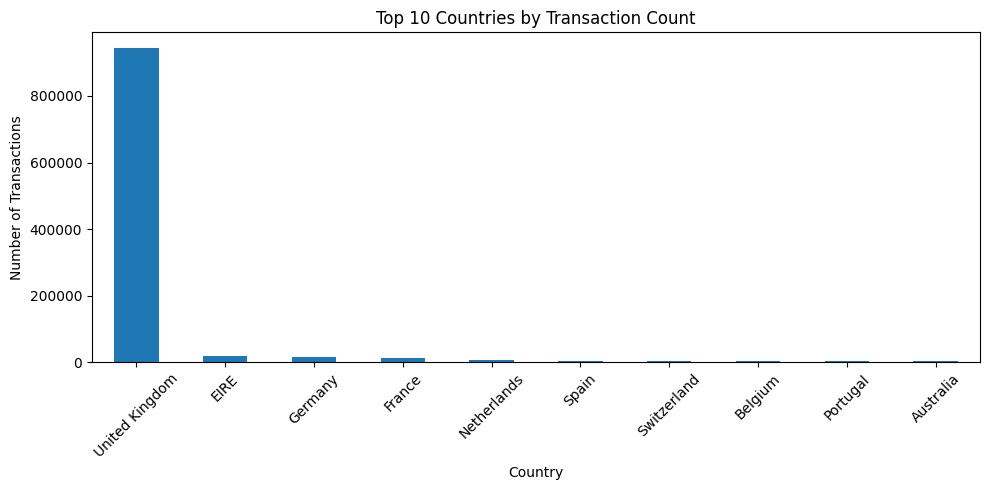

In [211]:
country_summary.head(10)["TransactionCount"].plot(
    kind="bar",
    figsize=(10, 5),
    title="Top 10 Countries by Transaction Count"
)

plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Country Selection Decision

The result shows that the **United Kingdom clearly dominates the dataset**.

It contains **944,167 cleaned transaction records**, which is approximately **92.11% of all cleaned transactions**. The next largest countries, such as EIRE, Germany, and France, contain much smaller transaction volumes.

Because my forecasting target is product-level demand, combining all countries could introduce additional geographical variation and create sparse time series for many country-product combinations.

For that reason, I focus on the **United Kingdom** for the initial forecasting analysis. This gives me a much larger and more stable transaction history and makes the first model comparison easier to interpret.

## 32. Creating the United Kingdom Dataset

After selecting the United Kingdom as the main market, I create a separate UK dataset.

I also create daily and weekly time variables from `InvoiceDate`.

The weekly variable is especially important because my forecasting target will be **weekly product demand**, rather than individual transactions.

In [212]:
df_uk = df_clean[
    df_clean["Country"] == "United Kingdom"
].copy()

df_uk["Date"] = df_uk["InvoiceDate"].dt.date

df_uk["Week"] = (
    df_uk["InvoiceDate"]
    .dt.to_period("W-SUN")
    .apply(lambda period: period.start_time)
)

print("UK dataset shape:", df_uk.shape)
print("Unique UK products:", df_uk["StockCode"].nunique())

print("\nDate range:")
print("Start:", df_uk["InvoiceDate"].min())
print("End:", df_uk["InvoiceDate"].max())

display(
    df_uk[
        ["InvoiceDate", "Date", "Week"]
    ].head()
)

UK dataset shape: (944167, 13)
Unique UK products: 4721

Date range:
Start: 2009-12-01 07:45:00
End: 2011-12-09 12:49:00


,InvoiceDate,Date,Week
0,2009-12-01 07:45:00,2009-12-01,2009-11-30
1,2009-12-01 07:45:00,2009-12-01,2009-11-30
2,2009-12-01 07:45:00,2009-12-01,2009-11-30
3,2009-12-01 07:45:00,2009-12-01,2009-11-30
4,2009-12-01 07:45:00,2009-12-01,2009-11-30


## 33. Measuring Product Activity

The UK dataset still contains more than 4,700 products, but many of them may have short or irregular sales histories.

So instead of selecting products only by total sales, I measure how consistently each product appears over time.

I look at transaction frequency, active days, active weeks, first and last sale dates, total quantity, total sales value, and the overall sales span.

This helps me identify products that contain enough historical information to support forecasting.

In [213]:
product_activity = (
    df_uk.groupby("StockCode")
    .agg(
        Description=("Description", "first"),
        TotalQuantity=("Quantity", "sum"),
        TransactionCount=("Invoice", "count"),
        ActiveDays=("Date", "nunique"),
        ActiveWeeks=("Week", "nunique"),
        FirstSale=("InvoiceDate", "min"),
        LastSale=("InvoiceDate", "max"),
        TotalSalesValue=("SalesValue", "sum")
    )
    .reset_index()
)

product_activity["SalesSpanDays"] = (
    product_activity["LastSale"] -
    product_activity["FirstSale"]
).dt.days

display(
    product_activity.sort_values(
        ["ActiveWeeks", "TransactionCount"],
        ascending=False
    ).head(20)
)

,StockCode,Description,TotalQuantity,TransactionCount,ActiveDays,ActiveWeeks,FirstSale,LastSale,TotalSalesValue,SalesSpanDays
4142,85123A,WHITE HANGING HEART T-LIGHT HOLDER,88949,5521,603,104,2009-12-01 09:46:00,2011-12-09 11:34:00,"246,564.41",738
4120,85099B,JUMBO BAG RED WHITE SPOTTY,89381,3852,586,104,2009-12-01 10:06:00,2011-12-09 10:26:00,"168,664.22",738
250,20725,LUNCH BAG RED SPOTTY,32430,2833,592,104,2009-12-01 10:06:00,2011-12-09 12:23:00,"59,150.05",738
607,21212,PACK OF 72 RETRO SPOT CAKE CASES,72301,2823,586,104,2009-12-01 10:49:00,2011-12-09 10:23:00,"41,300.67",737
3881,84879,ASSORTED COLOUR BIRD ORNAMENT,75794,2751,579,104,2009-12-01 09:06:00,2011-12-09 12:31:00,"122,675.37",738
252,20727,LUNCH BAG BLACK SKULL.,24153,2339,578,104,2009-12-01 12:13:00,2011-12-09 11:34:00,"41,837.04",737
624,21232,STRAWBERRY CERAMIC TRINKET BOX,35280,2337,564,104,2009-12-01 07:45:00,2011-12-09 10:26:00,"46,271.03",738
1210,21931,JUMBO STORAGE BAG SUKI,27532,2285,576,104,2009-12-01 11:34:00,2011-12-09 12:19:00,"58,629.83",738
1420,22197,"POPCORN HOLDER , SMALL",83617,2266,554,104,2009-12-01 11:45:00,2011-12-09 12:19:00,"75,984.79",738
1061,21754,HOME BUILDING BLOCK WORD,7455,2063,568,104,2009-12-01 09:06:00,2011-12-09 10:26:00,"45,752.99",738


## 34. Selecting Products With Sufficient History

Before choosing the modelling sample, I inspect the distribution of product activity.

The purpose is to understand how long and how frequently products are actually sold in this dataset before defining any threshold.

This is important because a forecasting model needs enough historical observations to learn from, while products with very short or highly irregular histories may not provide a meaningful time series.

In [214]:
activity_distribution = product_activity[
    [
        "TransactionCount",
        "ActiveDays",
        "ActiveWeeks",
        "SalesSpanDays"
    ]
].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90]
).T

display(activity_distribution)

,count,mean,std,min,25%,50%,75%,90%,max
TransactionCount,"4,721.00",199.99,321.60,1.00,25.00,84.00,236.00,518.00,"5,521.00"
ActiveDays,"4,721.00",106.63,116.32,1.00,21.00,65.00,149.00,278.00,603.00
ActiveWeeks,"4,721.00",40.59,31.10,1.00,13.00,33.00,64.00,91.00,104.00
SalesSpanDays,"4,721.00",471.89,257.57,0.00,230.00,537.00,726.00,736.00,738.00


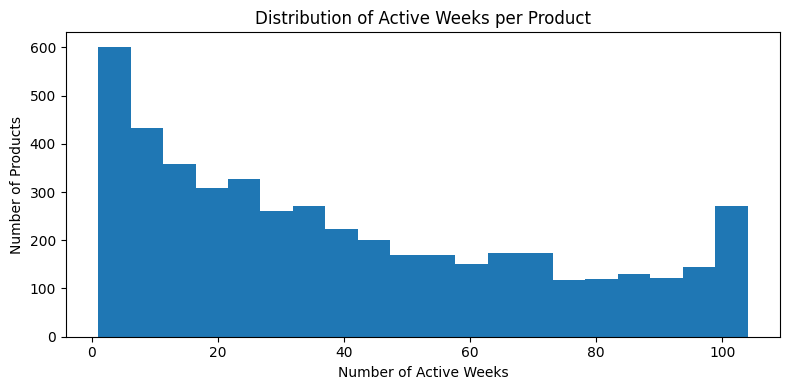

In [215]:
plt.figure(figsize=(8, 4))
plt.hist(
    product_activity["ActiveWeeks"],
    bins=20
)

plt.title("Distribution of Active Weeks per Product")
plt.xlabel("Number of Active Weeks")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

### Selection Criteria

The activity distribution shows that many products have relatively short or irregular histories.

The median product is active for only **33 weeks**, while the 75th percentile is **64 weeks**.

Based on this distribution, I use three practical eligibility criteria:

- at least **60 active weeks**,
- at least **100 transaction records**,
- and at least **365 days** between the first and last sale.

The purpose of these criteria is to remove products that are too sparse, too infrequent, or too short-lived, while still keeping a sufficiently large product pool for later modelling.

### Filtering Eligible Products

I now apply the three eligibility criteria.

At this stage, I am not selecting the final products yet. I am only creating a pool of products that have enough historical activity to be considered suitable for forecasting.

In [216]:
eligible_products = product_activity[
    (product_activity["ActiveWeeks"] >= 60) &
    (product_activity["TransactionCount"] >= 100) &
    (product_activity["SalesSpanDays"] >= 365)
].copy()

eligible_products = eligible_products.sort_values(
    ["ActiveWeeks", "TransactionCount", "TotalQuantity"],
    ascending=False
)

print("Number of eligible products:", len(eligible_products))

display(
    eligible_products[
        [
            "StockCode",
            "Description",
            "TotalQuantity",
            "TransactionCount",
            "ActiveWeeks",
            "SalesSpanDays",
            "TotalSalesValue"
        ]
    ].head(20)
)

Number of eligible products: 1334


,StockCode,Description,TotalQuantity,TransactionCount,ActiveWeeks,SalesSpanDays,TotalSalesValue
4142,85123A,WHITE HANGING HEART T-LIGHT HOLDER,88949,5521,104,738,"246,564.41"
4120,85099B,JUMBO BAG RED WHITE SPOTTY,89381,3852,104,738,"168,664.22"
250,20725,LUNCH BAG RED SPOTTY,32430,2833,104,738,"59,150.05"
607,21212,PACK OF 72 RETRO SPOT CAKE CASES,72301,2823,104,737,"41,300.67"
3881,84879,ASSORTED COLOUR BIRD ORNAMENT,75794,2751,104,738,"122,675.37"
252,20727,LUNCH BAG BLACK SKULL.,24153,2339,104,737,"41,837.04"
624,21232,STRAWBERRY CERAMIC TRINKET BOX,35280,2337,104,738,"46,271.03"
1210,21931,JUMBO STORAGE BAG SUKI,27532,2285,104,738,"58,629.83"
1420,22197,"POPCORN HOLDER , SMALL",83617,2266,104,738,"75,984.79"
1061,21754,HOME BUILDING BLOCK WORD,7455,2063,104,738,"45,752.99"


## 35. Selecting an Initial Modelling Subset

For the first modelling stage, I select only five highly active products from the eligible pool.

I do this deliberately because using all 1,334 products immediately would make it much harder to inspect the weekly series, validate the feature engineering, understand model errors, and identify methodological problems.

So these five products are used as a **pilot modelling subset**.

The final analysis can later be expanded to more eligible products, especially for global models such as XGBoost and LSTM.

In [217]:
selected_products = (
    eligible_products
    .sort_values(
        ["ActiveWeeks", "TransactionCount", "TotalQuantity"],
        ascending=False
    )
    .head(5)["StockCode"]
    .tolist()
)

selected_product_info = eligible_products[
    eligible_products["StockCode"].isin(selected_products)
][
    [
        "StockCode",
        "Description",
        "TotalQuantity",
        "TransactionCount",
        "ActiveWeeks",
        "SalesSpanDays",
        "TotalSalesValue"
    ]
].sort_values(
    ["ActiveWeeks", "TransactionCount"],
    ascending=False
)

display(selected_product_info)

,StockCode,Description,TotalQuantity,TransactionCount,ActiveWeeks,SalesSpanDays,TotalSalesValue
4142,85123A,WHITE HANGING HEART T-LIGHT HOLDER,88949,5521,104,738,"246,564.41"
4120,85099B,JUMBO BAG RED WHITE SPOTTY,89381,3852,104,738,"168,664.22"
250,20725,LUNCH BAG RED SPOTTY,32430,2833,104,738,"59,150.05"
607,21212,PACK OF 72 RETRO SPOT CAKE CASES,72301,2823,104,737,"41,300.67"
3881,84879,ASSORTED COLOUR BIRD ORNAMENT,75794,2751,104,738,"122,675.37"


# 6. Weekly Demand Dataset

The original dataset contains individual transaction records, but my forecasting target is **weekly product demand**.

So I now convert the transaction-level data into a Product × Week structure.

For each selected product, the target variable will be the total quantity sold during each week.

## 36. Removing Incomplete Boundary Weeks

Before aggregating the data, I check whether the first and last calendar weeks are complete.

The dataset begins on a Tuesday and ends on a Friday.

If I kept these two partial weeks, their demand would appear artificially low simply because only part of the week is observed.

So I remove only the first and last incomplete boundary weeks before constructing the final weekly series.

In [218]:
first_week = df_uk["Week"].min()
last_week = df_uk["Week"].max()

complete_start = first_week + pd.Timedelta(weeks=1)
complete_end = last_week - pd.Timedelta(weeks=1)

complete_weeks = pd.date_range(
    start=complete_start,
    end=complete_end,
    freq="W-MON"
)

print("First raw week:", first_week)
print("Last raw week:", last_week)

print("\nFirst complete week:", complete_start)
print("Last complete week:", complete_end)

print("\nNumber of complete weeks:", len(complete_weeks))

First raw week: 2009-11-30 00:00:00
Last raw week: 2011-12-05 00:00:00

First complete week: 2009-12-07 00:00:00
Last complete week: 2011-11-28 00:00:00

Number of complete weeks: 104


## 37. Aggregating Weekly Demand

I now convert the transaction-level data into weekly demand.

For each selected product, I sum the quantity sold within each complete week.

I also create a complete product-week grid. This means that if a product has no recorded sales during a particular week, I keep that week and record the demand as zero rather than dropping it.

This preserves the full chronological sequence and avoids creating artificial gaps in the time series.

In [219]:
weekly_demand = (
    df_uk[
        df_uk["StockCode"].isin(selected_products)
    ]
    .groupby(
        ["StockCode", "Week"],
        as_index=False
    )
    .agg(
        WeeklyDemand=("Quantity", "sum")
    )
)

product_week_index = pd.MultiIndex.from_product(
    [selected_products, complete_weeks],
    names=["StockCode", "Week"]
)

weekly_demand = (
    weekly_demand
    .set_index(["StockCode", "Week"])
    .reindex(product_week_index)
    .reset_index()
)

weekly_demand["WeeklyDemand"] = (
    weekly_demand["WeeklyDemand"]
    .fillna(0)
)

print("Weekly dataset shape:", weekly_demand.shape)

display(
    weekly_demand.head(15)
)

Weekly dataset shape: (520, 3)


,StockCode,Week,WeeklyDemand
0,85123A,2009-12-07,"3,045.00"
1,85123A,2009-12-14,"1,255.00"
2,85123A,2009-12-21,127.00
3,85123A,2009-12-28,0.00
4,85123A,2010-01-04,"1,577.00"
5,85123A,2010-01-11,843.00
6,85123A,2010-01-18,917.00
7,85123A,2010-01-25,"1,364.00"
8,85123A,2010-02-01,677.00
9,85123A,2010-02-08,574.00


## 38. Inspecting Weekly Demand Patterns

Before building any forecasting model, I inspect the behaviour of weekly demand for the five selected products.

I look at the number of zero-demand weeks, average demand, standard deviation, minimum demand, and maximum demand.

The purpose is to understand whether the products are relatively stable, highly volatile, or intermittent before interpreting model performance.

In [220]:
weekly_product_summary = (
    weekly_demand.groupby("StockCode")
    .agg(
        Weeks=("Week", "count"),
        ZeroDemandWeeks=("WeeklyDemand", lambda x: (x == 0).sum()),
        MeanWeeklyDemand=("WeeklyDemand", "mean"),
        StdWeeklyDemand=("WeeklyDemand", "std"),
        MinWeeklyDemand=("WeeklyDemand", "min"),
        MaxWeeklyDemand=("WeeklyDemand", "max")
    )
)

display(weekly_product_summary)

,Weeks,ZeroDemandWeeks,MeanWeeklyDemand,StdWeeklyDemand,MinWeeklyDemand,MaxWeeklyDemand
StockCode,,,,,,
20725,104,2,307.60,145.21,0.00,780.00
21212,104,2,680.26,452.91,0.00,"2,083.00"
84879,104,2,703.49,707.84,0.00,"5,584.00"
85099B,104,2,844.44,481.89,0.00,"2,636.00"
85123A,104,2,837.15,580.75,0.00,"3,328.00"


## 39. Visualising Weekly Demand

I also plot each weekly demand series.

The purpose is to inspect the data visually for changes in demand level, volatility, possible trend, possible seasonality, and unusual spikes.

This is important because summary statistics alone do not show how these changes occur over time.

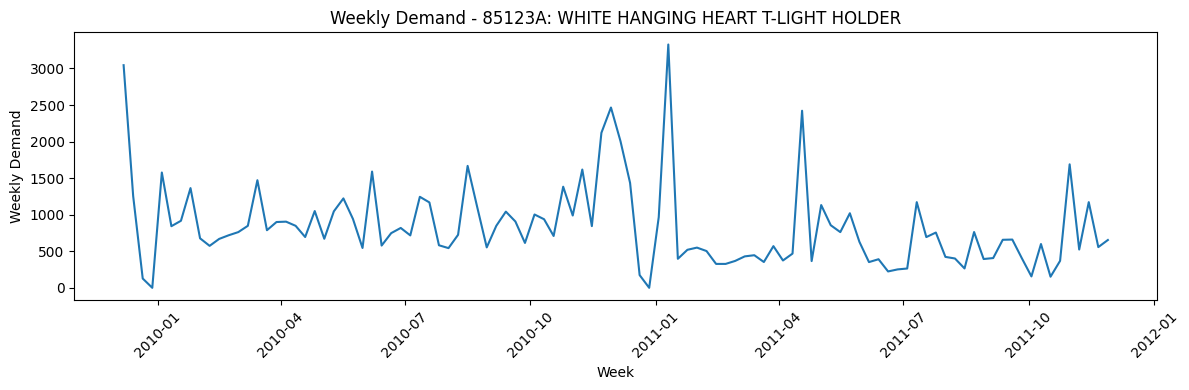

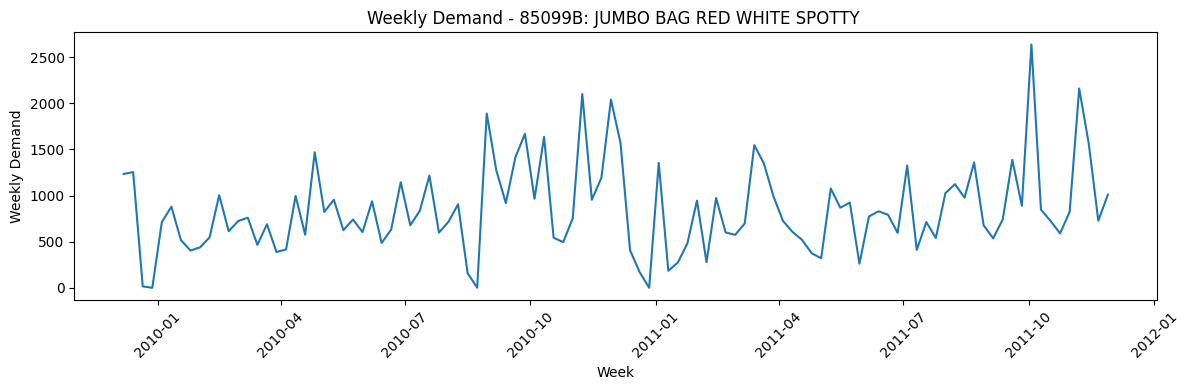

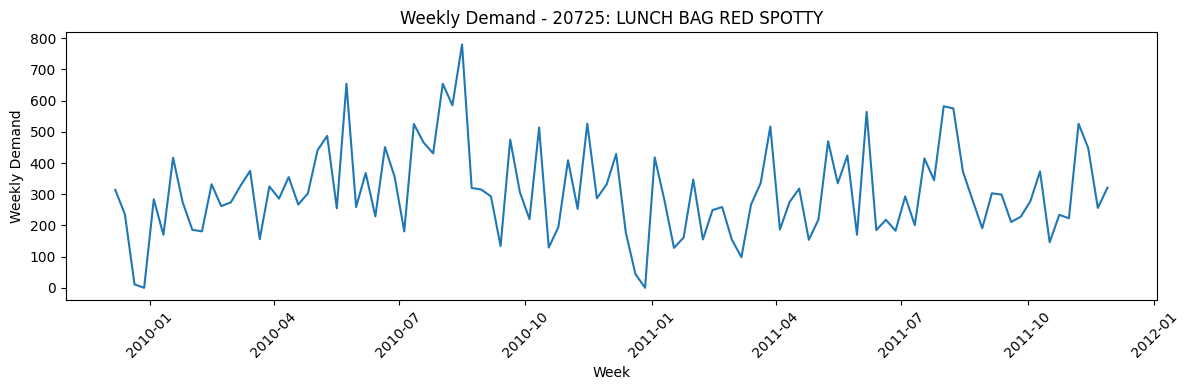

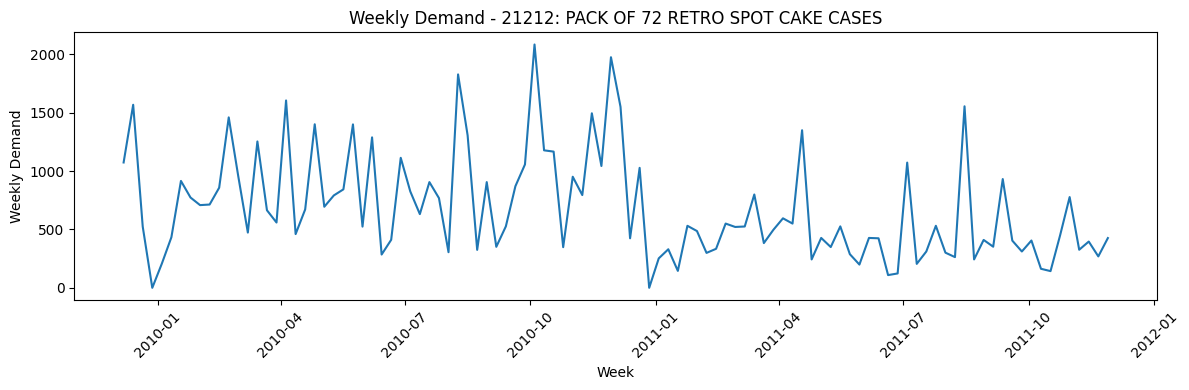

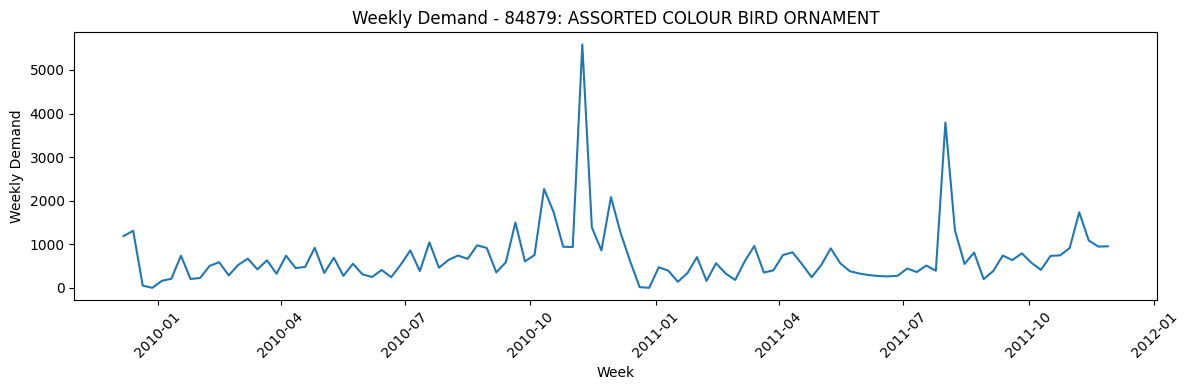

In [221]:
for stock_code in selected_products:
    product_series = weekly_demand[
        weekly_demand["StockCode"] == stock_code
    ]

    description = selected_product_info.loc[
        selected_product_info["StockCode"] == stock_code,
        "Description"
    ].iloc[0]

    plt.figure(figsize=(12, 4))

    plt.plot(
        product_series["Week"],
        product_series["WeeklyDemand"]
    )

    plt.title(
        f"Weekly Demand - {stock_code}: {description}"
    )
    plt.xlabel("Week")
    plt.ylabel("Weekly Demand")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

## 40. Checking Temporal Dependence

Before creating forecasting features, I check whether current weekly demand is related to previous demand.

I calculate correlations at lags of **1, 4, 13, and 52 weeks**.

The shorter lags help me understand whether recent demand contains predictive information, while the 52-week lag gives an initial indication of possible yearly seasonality.

In [222]:
lag_correlations = []

for stock_code in selected_products:
    series = (
        weekly_demand[
            weekly_demand["StockCode"] == stock_code
        ]
        .sort_values("Week")
        ["WeeklyDemand"]
    )

    lag_correlations.append({
        "StockCode": stock_code,
        "Lag_1": series.corr(series.shift(1)),
        "Lag_4": series.corr(series.shift(4)),
        "Lag_13": series.corr(series.shift(13)),
        "Lag_52": series.corr(series.shift(52))
    })

lag_correlation_table = pd.DataFrame(lag_correlations)

display(lag_correlation_table)

,StockCode,Lag_1,Lag_4,Lag_13,Lag_52
0,85123A,0.22,0.12,-0.05,0.24
1,85099B,0.20,0.08,0.01,0.26
2,20725,0.21,0.04,0.05,0.50
3,21212,0.25,0.05,0.04,0.09
4,84879,0.27,0.23,-0.05,0.35


# 7. Forecasting Strategy

At this point, I define the modelling framework.

I want the dissertation to compare **different forecasting families**, rather than simply testing several similar algorithms.

The current structure is:

- **Naive and Seasonal Naive** as simple baselines,
- **Linear Regression** as a simple feature-based machine-learning benchmark,
- **XGBoost** as a nonlinear feature-based machine-learning model,
- a **classical statistical time-series approach**, initially considering SARIMA,
- and **LSTM** as a recurrent neural-network approach.

The main idea is to compare simple forecasting, classical time-series modelling, feature-based machine learning, and sequence-based deep learning.

This also allows me to test whether additional model complexity actually produces a meaningful improvement in forecasting accuracy.

## 41. Why I Do Not Use a Random Train-Test Split

Because this is a forecasting problem, the chronological order of the observations must be preserved.

A random train-test split could place future weeks in the training set and earlier weeks in validation or testing.

That would create an unrealistic forecasting scenario and could allow future information to influence model development.

So throughout the modelling process, I train on earlier weeks and evaluate on later weeks.

## 42. Chronological Train, Validation and Test Split

Before feature engineering, I first define the intended chronological structure using the full 104-week dataset.

The earliest observations are used for training, the following period for validation, and the most recent period for final testing.

The validation period is used for model development and comparison.

The final test period is kept separate and will not be used until the modelling decisions are complete.

In [223]:
unique_weeks = pd.Index(
    sorted(weekly_demand["Week"].unique())
)

print("Total number of weeks:", len(unique_weeks))
print("First week:", unique_weeks.min())
print("Last week:", unique_weeks.max())

Total number of weeks: 104
First week: 2009-12-07 00:00:00
Last week: 2011-11-28 00:00:00


### Split Design

The full weekly dataset contains **104 complete weeks**.

I initially use approximately **70% for training, 15% for validation, and 15% for testing**.

This first split is mainly used to define the forecasting timeline.

After feature engineering, some early weeks can no longer be used as modelling targets because longer lag and rolling features require historical observations. For that reason, I recalculate the exact final modelling split later using the usable modelling period.

In [224]:
train_weeks = unique_weeks[:73]
validation_weeks = unique_weeks[73:88]
test_weeks = unique_weeks[88:]

train_data = weekly_demand[
    weekly_demand["Week"].isin(train_weeks)
].copy()

validation_data = weekly_demand[
    weekly_demand["Week"].isin(validation_weeks)
].copy()

test_data = weekly_demand[
    weekly_demand["Week"].isin(test_weeks)
].copy()

print(
    "Train:",
    train_data["Week"].min(),
    "to",
    train_data["Week"].max(),
    "| weeks:",
    train_data["Week"].nunique(),
    "| rows:",
    len(train_data)
)

print(
    "Validation:",
    validation_data["Week"].min(),
    "to",
    validation_data["Week"].max(),
    "| weeks:",
    validation_data["Week"].nunique(),
    "| rows:",
    len(validation_data)
)

print(
    "Test:",
    test_data["Week"].min(),
    "to",
    test_data["Week"].max(),
    "| weeks:",
    test_data["Week"].nunique(),
    "| rows:",
    len(test_data)
)

Train: 2009-12-07 00:00:00 to 2011-04-25 00:00:00 | weeks: 73 | rows: 365
Validation: 2011-05-02 00:00:00 to 2011-08-08 00:00:00 | weeks: 15 | rows: 75
Test: 2011-08-15 00:00:00 to 2011-11-28 00:00:00 | weeks: 16 | rows: 80


## 43. Creating Time-Series Features

Machine-learning models such as Linear Regression and XGBoost do not automatically understand temporal order.

So I convert historical demand into explicit predictor variables.

I create demand lags of **1, 2, 4, 8, and 13 weeks**, together with rolling means and rolling standard deviations over **4, 8, and 13 weeks**.

I also include basic calendar variables such as month, week of the year, and year.

For every rolling feature, I shift the series before calculating the window. This is important because the current week's demand must never be included in the predictors used to forecast that same week.

In [225]:
forecast_data = (
    weekly_demand
    .sort_values(["StockCode", "Week"])
    .copy()
)

for lag in [1, 2, 4, 8, 13]:
    forecast_data[f"lag_{lag}"] = (
        forecast_data
        .groupby("StockCode")["WeeklyDemand"]
        .shift(lag)
    )

for window in [4, 8, 13]:
    forecast_data[f"rolling_mean_{window}"] = (
        forecast_data
        .groupby("StockCode")["WeeklyDemand"]
        .transform(
            lambda x: x.shift(1).rolling(window).mean()
        )
    )

    forecast_data[f"rolling_std_{window}"] = (
        forecast_data
        .groupby("StockCode")["WeeklyDemand"]
        .transform(
            lambda x: x.shift(1).rolling(window).std()
        )
    )

forecast_data["month"] = forecast_data["Week"].dt.month
forecast_data["week_of_year"] = (
    forecast_data["Week"].dt.isocalendar().week.astype(int)
)
forecast_data["year"] = forecast_data["Week"].dt.year

display(forecast_data.head(20))

,StockCode,Week,WeeklyDemand,lag_1,lag_2,lag_4,lag_8,lag_13,rolling_mean_4,rolling_std_4,rolling_mean_8,rolling_std_8,rolling_mean_13,rolling_std_13,month,week_of_year,year
208,20725,2009-12-07,314.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,50,2009
209,20725,2009-12-14,236.00,314.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,51,2009
210,20725,2009-12-21,11.00,236.00,314.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,52,2009
211,20725,2009-12-28,0.00,11.00,236.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,53,2009
212,20725,2010-01-04,284.00,0.00,11.00,314.00,NaN,NaN,140.25,158.88,NaN,NaN,NaN,NaN,1,1,2010
213,20725,2010-01-11,170.00,284.00,0.00,236.00,NaN,NaN,132.75,148.30,NaN,NaN,NaN,NaN,1,2,2010
214,20725,2010-01-18,417.00,170.00,284.00,11.00,NaN,NaN,116.25,136.16,NaN,NaN,NaN,NaN,1,3,2010
215,20725,2010-01-25,274.00,417.00,170.00,0.00,NaN,NaN,217.75,176.81,NaN,NaN,NaN,NaN,1,4,2010
216,20725,2010-02-01,186.00,274.00,417.00,284.00,314.00,NaN,286.25,101.27,213.25,145.96,NaN,NaN,2,5,2010
217,20725,2010-02-08,181.00,186.00,274.00,170.00,236.00,NaN,261.75,113.15,197.25,140.24,NaN,NaN,2,6,2010


## 44. Preparing the Modelling Dataset

I now create the final dataset used by the feature-based models.

I remove only the observations that do not yet contain a complete set of lag and rolling features.

The longest historical window is 13 weeks, so the first part of each series is used as historical context rather than as a modelling target.

In [226]:
feature_columns = [
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_8",
    "lag_13",
    "rolling_mean_4",
    "rolling_mean_8",
    "rolling_mean_13",
    "rolling_std_4",
    "rolling_std_8",
    "rolling_std_13",
    "month",
    "week_of_year",
    "year"
]

model_data = forecast_data.dropna(
    subset=feature_columns
).copy()

print("Rows available for modelling:", len(model_data))
print("Number of modelling weeks:", model_data["Week"].nunique())
print("First modelling week:", model_data["Week"].min())
print("Last modelling week:", model_data["Week"].max())

Rows available for modelling: 455
Number of modelling weeks: 91
First modelling week: 2010-03-08 00:00:00
Last modelling week: 2011-11-28 00:00:00


## 45. Final Chronological Modelling Split

Because feature engineering reduces the usable target period from 104 to 91 weeks, I now recreate the chronological split using the final modelling dataset.

This is the split that is actually used for Linear Regression and XGBoost.

Again, the earliest period is used for training, the next period for validation, and the most recent period remains untouched for final testing.

In [227]:
model_weeks = pd.Index(
    sorted(model_data["Week"].unique())
)

train_weeks = model_weeks[:64]
validation_weeks = model_weeks[64:77]
test_weeks = model_weeks[77:]

train_data = model_data[
    model_data["Week"].isin(train_weeks)
].copy()

validation_data = model_data[
    model_data["Week"].isin(validation_weeks)
].copy()

test_data = model_data[
    model_data["Week"].isin(test_weeks)
].copy()

print(
    "Train:",
    train_data["Week"].min(),
    "to",
    train_data["Week"].max(),
    "| weeks:",
    train_data["Week"].nunique(),
    "| rows:",
    len(train_data)
)

print(
    "Validation:",
    validation_data["Week"].min(),
    "to",
    validation_data["Week"].max(),
    "| weeks:",
    validation_data["Week"].nunique(),
    "| rows:",
    len(validation_data)
)

print(
    "Test:",
    test_data["Week"].min(),
    "to",
    test_data["Week"].max(),
    "| weeks:",
    test_data["Week"].nunique(),
    "| rows:",
    len(test_data)
)

Train: 2010-03-08 00:00:00 to 2011-05-23 00:00:00 | weeks: 64 | rows: 320
Validation: 2011-05-30 00:00:00 to 2011-08-22 00:00:00 | weeks: 13 | rows: 65
Test: 2011-08-29 00:00:00 to 2011-11-28 00:00:00 | weeks: 14 | rows: 70


## 46. Forecast Evaluation Metrics

I use three evaluation metrics because each one captures forecasting error differently.

- **MAE** gives the average absolute error in the original weekly-demand units.
- **RMSE** gives more weight to large forecasting mistakes, which is important because some products contain sudden demand spikes.
- **sMAPE** expresses error in percentage terms and is more suitable than standard MAPE when demand can be zero or very small.

Using all three metrics prevents the model comparison from depending on only one definition of forecasting accuracy.

In [228]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denominator = np.abs(y_true) + np.abs(y_pred)

    return np.mean(
        np.where(
            denominator == 0,
            0,
            2 * np.abs(y_pred - y_true) / denominator
        )
    ) * 100


def forecasting_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(
            mean_squared_error(y_true, y_pred)
        ),
        "sMAPE": smape(y_true, y_pred)
    }

## 47. Naive Forecast Baseline

I begin with the simplest possible benchmark.

The one-week Naive forecast assumes that next week's demand will be equal to the previous week's demand.

This gives me a basic reference point. A more complex model should ideally provide a meaningful improvement over simply carrying the previous week's value forward.

In [229]:
naive_metrics = forecasting_metrics(
    validation_data["WeeklyDemand"],
    validation_data["lag_1"]
)

print("Naive Forecast Validation Metrics:")
print(f"MAE: {naive_metrics['MAE']:.2f}")
print(f"RMSE: {naive_metrics['RMSE']:.2f}")
print(f"sMAPE: {naive_metrics['sMAPE']:.2f}%")

Naive Forecast Validation Metrics:
MAE: 359.68
RMSE: 663.54
sMAPE: 51.69%


## 48. Seasonal Naive Forecast

The Seasonal Naive forecast predicts demand using the same week one year earlier.

I include this model because the earlier lag analysis suggested that yearly information may be useful for some products.

It provides a simple benchmark for testing whether annual seasonality alone can explain part of the demand pattern.

In [230]:
seasonal_naive_data = (
    weekly_demand
    .sort_values(["StockCode", "Week"])
    .copy()
)

seasonal_naive_data["lag_52"] = (
    seasonal_naive_data
    .groupby("StockCode")["WeeklyDemand"]
    .shift(52)
)

seasonal_validation = seasonal_naive_data[
    seasonal_naive_data["Week"].isin(validation_weeks)
].dropna(
    subset=["lag_52"]
)

seasonal_naive_metrics = forecasting_metrics(
    seasonal_validation["WeeklyDemand"],
    seasonal_validation["lag_52"]
)

print("Seasonal Naive Validation Metrics:")
print(f"MAE: {seasonal_naive_metrics['MAE']:.2f}")
print(f"RMSE: {seasonal_naive_metrics['RMSE']:.2f}")
print(f"sMAPE: {seasonal_naive_metrics['sMAPE']:.2f}%")

print("Validation observations used:", len(seasonal_validation))

Seasonal Naive Validation Metrics:
MAE: 388.23
RMSE: 624.23
sMAPE: 56.32%
Validation observations used: 65


## 49. Linear Regression Benchmark

I next use Linear Regression as a simple feature-based machine-learning benchmark.

The purpose is not to treat Linear Regression as the main advanced forecasting model.

Instead, I use it to test whether the lag, rolling, and calendar features already contain useful predictive information before moving to a more flexible nonlinear model.

In [231]:
from sklearn.linear_model import LinearRegression

X_train = train_data[feature_columns]
X_validation = validation_data[feature_columns]

y_train = train_data["WeeklyDemand"]
y_validation = validation_data["WeeklyDemand"]

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_validation_predictions = linear_model.predict(
    X_validation
)

linear_metrics = forecasting_metrics(
    y_validation,
    linear_validation_predictions
)

print("Linear Regression Validation Metrics:")
print(f"MAE: {linear_metrics['MAE']:.2f}")
print(f"RMSE: {linear_metrics['RMSE']:.2f}")
print(f"sMAPE: {linear_metrics['sMAPE']:.2f}%")

Linear Regression Validation Metrics:
MAE: 295.34
RMSE: 501.92
sMAPE: 50.04%


## 50. XGBoost Model

I then evaluate XGBoost as the initial nonlinear feature-based model.

XGBoost can capture nonlinear relationships and interactions between lag values, rolling statistics, and calendar variables, so it is more flexible than Linear Regression.

At this stage, I intentionally use an initial specification rather than performing extensive hyperparameter tuning.

The purpose is first to see whether the additional model complexity produces an immediate improvement. Proper time-aware tuning is planned for the next stage.

In [232]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_validation_predictions = xgb_model.predict(
    X_validation
)

xgb_metrics = forecasting_metrics(
    y_validation,
    xgb_validation_predictions
)

print("XGBoost Validation Metrics:")
print(f"MAE: {xgb_metrics['MAE']:.2f}")
print(f"RMSE: {xgb_metrics['RMSE']:.2f}")
print(f"sMAPE: {xgb_metrics['sMAPE']:.2f}%")

XGBoost Validation Metrics:
MAE: 315.20
RMSE: 536.94
sMAPE: 51.51%


## 51. Initial Model Comparison

I now compare all four models on the same validation period.

The Naive and Seasonal Naive approaches provide simple reference points, while Linear Regression and XGBoost provide the first machine-learning comparison.

This lets me see clearly whether additional modelling complexity is actually improving the forecast.

In [233]:
current_results = pd.DataFrame([
    {
        "Model": "Naive",
        **naive_metrics
    },
    {
        "Model": "Seasonal Naive",
        **seasonal_naive_metrics
    },
    {
        "Model": "Linear Regression",
        **linear_metrics
    },
    {
        "Model": "Initial XGBoost",
        **xgb_metrics
    }
])

display(
    current_results.sort_values("RMSE")
)

,Model,MAE,RMSE,sMAPE
2,Linear Regression,295.34,501.92,50.04
3,Initial XGBoost,315.20,536.94,51.51
1,Seasonal Naive,388.23,624.23,56.32
0,Naive,359.68,663.54,51.69


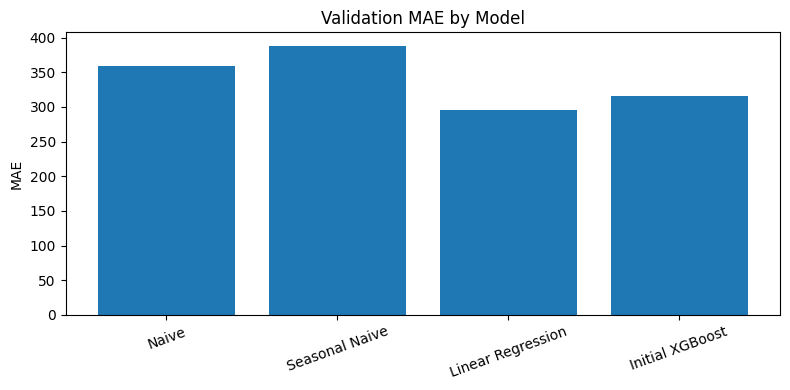

In [234]:
plt.figure(figsize=(8, 4))

plt.bar(
    current_results["Model"],
    current_results["MAE"]
)

plt.title("Validation MAE by Model")
plt.ylabel("MAE")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

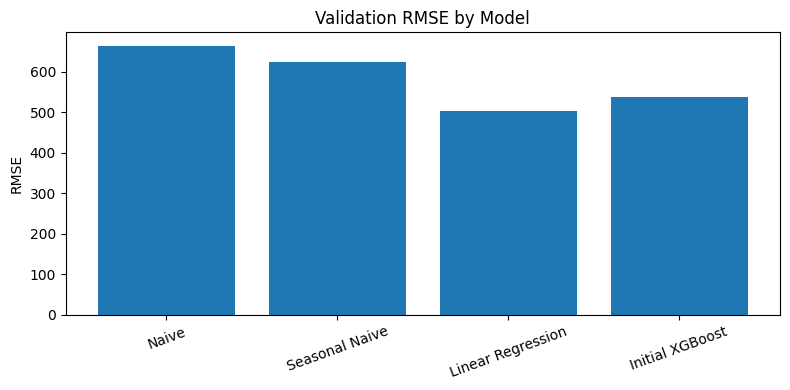

In [235]:
plt.figure(figsize=(8, 4))

plt.bar(
    current_results["Model"],
    current_results["RMSE"]
)

plt.title("Validation RMSE by Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

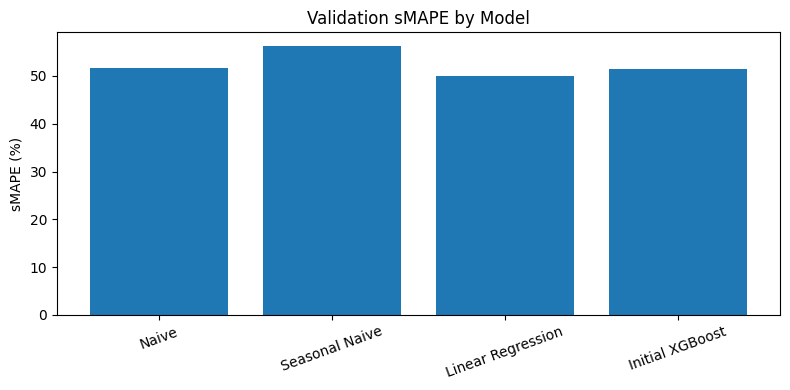

In [236]:
plt.figure(figsize=(8, 4))

plt.bar(
    current_results["Model"],
    current_results["sMAPE"]
)

plt.title("Validation sMAPE by Model")
plt.ylabel("sMAPE (%)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## 52. Actual vs Predicted Demand

The overall metrics show which models perform better on average, but they do not show how the predictions behave over time.

So I also compare the actual weekly demand with the predictions visually.

For clarity, I focus on **Linear Regression and XGBoost** in these plots because they are the two feature-based machine-learning models.

The Naive and Seasonal Naive methods are still retained as baseline benchmarks in the metric comparison.

Looking at the predictions over time helps me see whether the models follow the normal demand level and how they react to sudden peaks or drops.

In [237]:
validation_predictions = validation_data[
    ["StockCode", "Week", "WeeklyDemand"]
].copy()

validation_predictions["LinearPrediction"] = (
    linear_validation_predictions
)

validation_predictions["XGBoostPrediction"] = (
    xgb_validation_predictions
)

display(validation_predictions.head())

,StockCode,Week,WeeklyDemand,LinearPrediction,XGBoostPrediction
285,20725,2011-05-30,170.00,439.81,320.86
286,20725,2011-06-06,564.00,514.34,315.29
287,20725,2011-06-13,185.00,559.47,375.89
288,20725,2011-06-20,218.00,404.19,269.85
289,20725,2011-06-27,183.00,420.23,282.74


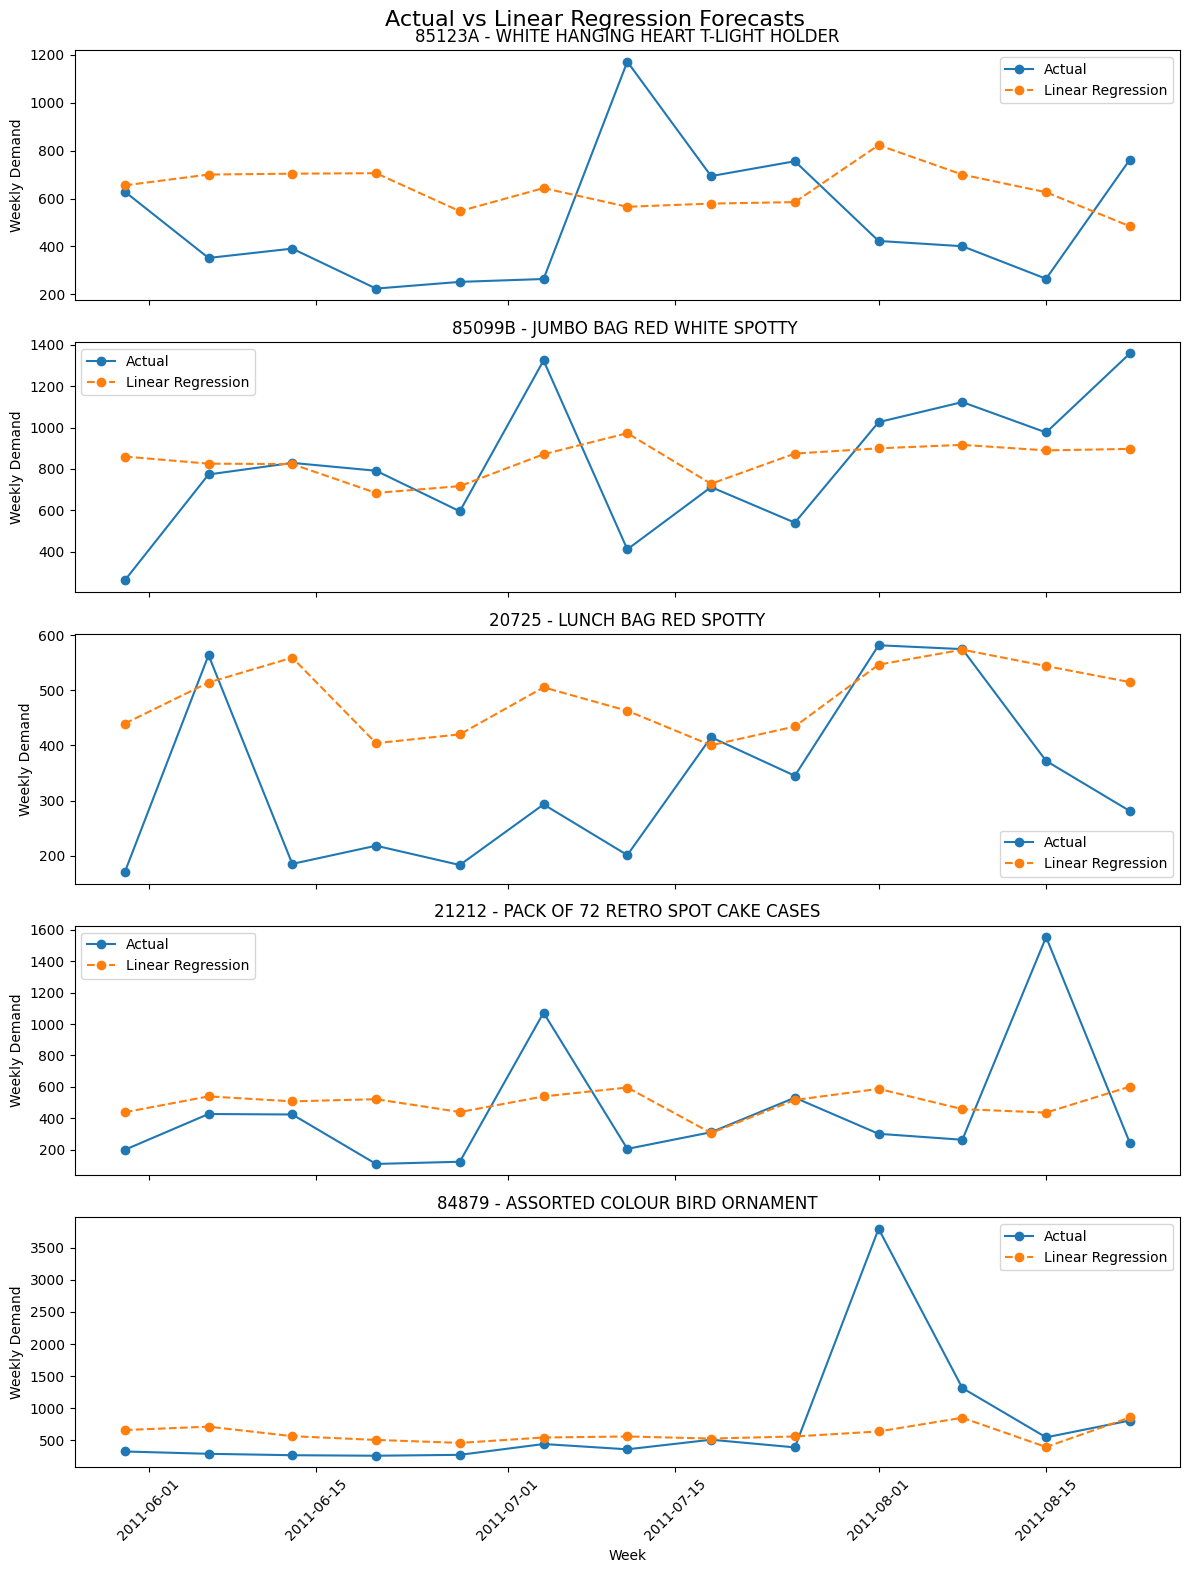

In [238]:
fig, axes = plt.subplots(
    len(selected_products),
    1,
    figsize=(12, 16),
    sharex=True
)

for ax, stock_code in zip(axes, selected_products):

    product_plot = validation_predictions[
        validation_predictions["StockCode"] == stock_code
    ]

    description = selected_product_info.loc[
        selected_product_info["StockCode"] == stock_code,
        "Description"
    ].iloc[0]

    ax.plot(
        product_plot["Week"],
        product_plot["WeeklyDemand"],
        marker="o",
        label="Actual"
    )

    ax.plot(
        product_plot["Week"],
        product_plot["LinearPrediction"],
        marker="o",
        linestyle="--",
        label="Linear Regression"
    )

    ax.set_title(
        f"{stock_code} - {description}"
    )

    ax.set_ylabel("Weekly Demand")
    ax.legend()

fig.suptitle(
    "Actual vs Linear Regression Forecasts",
    fontsize=16
)

plt.xlabel("Week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

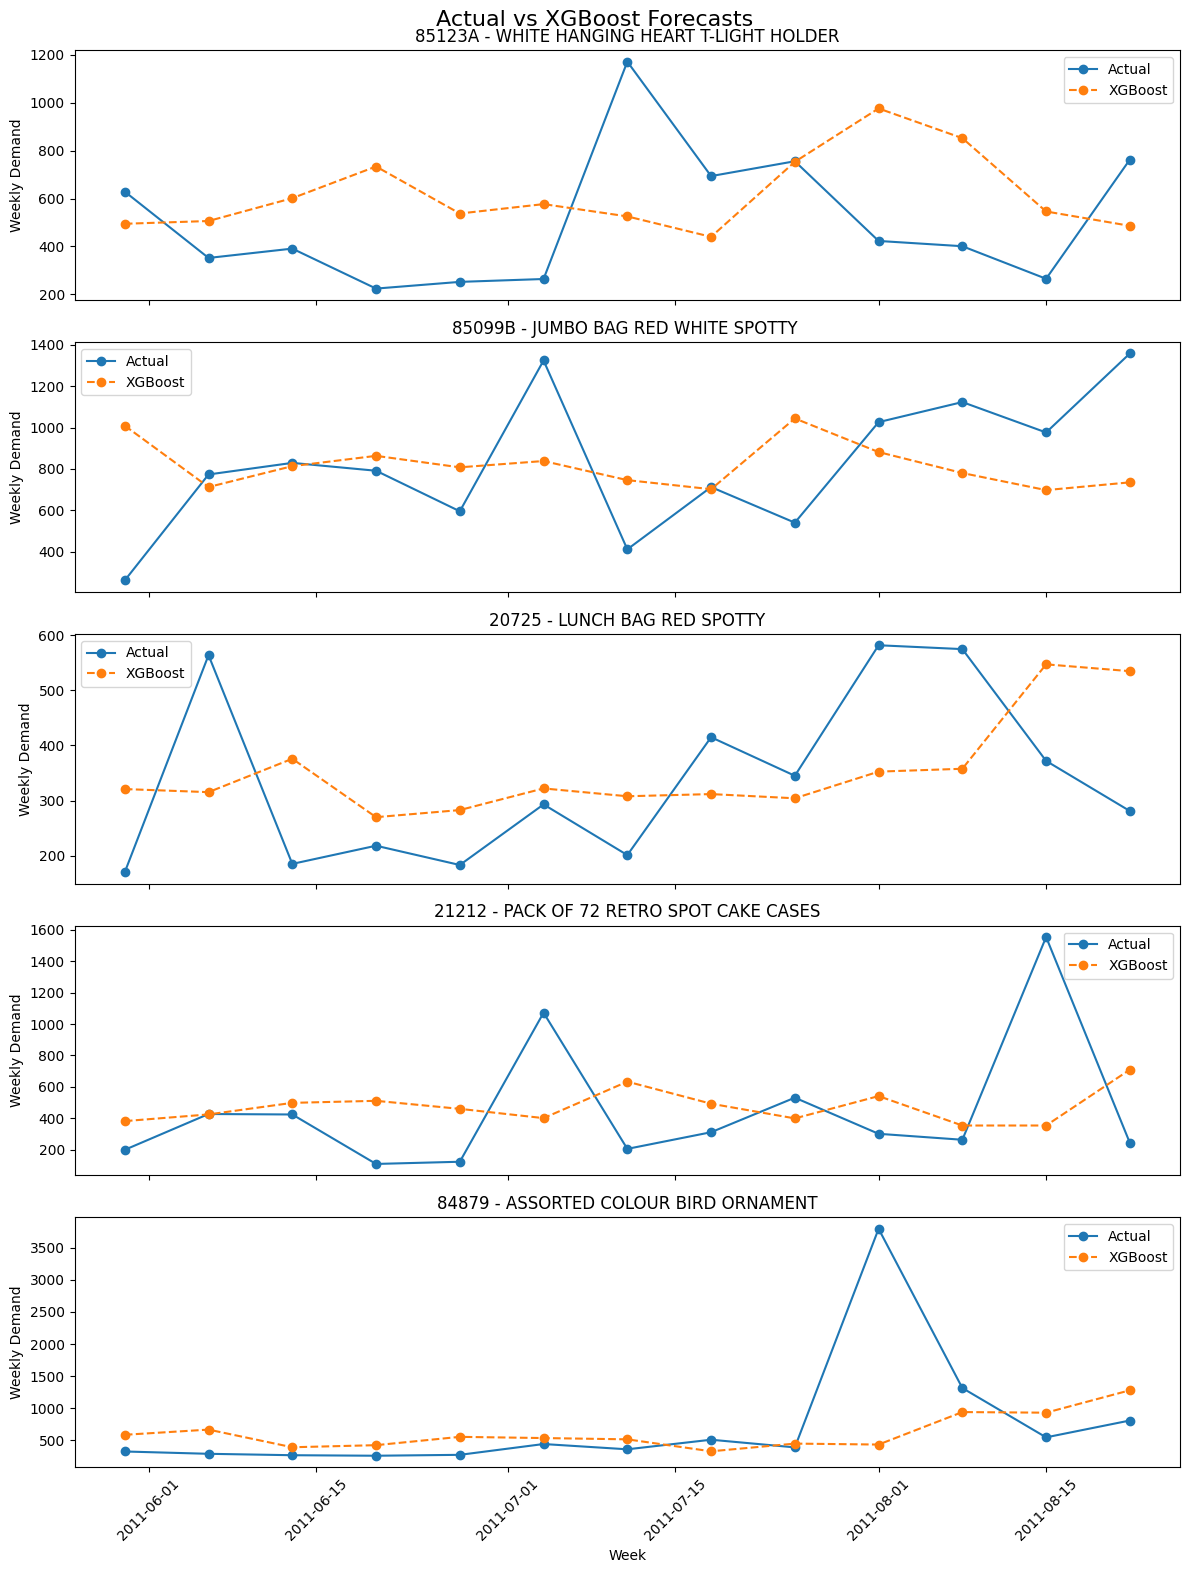

In [239]:
fig, axes = plt.subplots(
    len(selected_products),
    1,
    figsize=(12, 16),
    sharex=True
)

for ax, stock_code in zip(axes, selected_products):

    product_plot = validation_predictions[
        validation_predictions["StockCode"] == stock_code
    ]

    description = selected_product_info.loc[
        selected_product_info["StockCode"] == stock_code,
        "Description"
    ].iloc[0]

    ax.plot(
        product_plot["Week"],
        product_plot["WeeklyDemand"],
        marker="o",
        label="Actual"
    )

    ax.plot(
        product_plot["Week"],
        product_plot["XGBoostPrediction"],
        marker="o",
        linestyle="--",
        label="XGBoost"
    )

    ax.set_title(
        f"{stock_code} - {description}"
    )

    ax.set_ylabel("Weekly Demand")
    ax.legend()

fig.suptitle(
    "Actual vs XGBoost Forecasts",
    fontsize=16
)

plt.xlabel("Week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 53. Product-Level Error Analysis

The overall validation metrics combine all five products, so they can hide important differences between individual demand series.

I therefore calculate MAE, RMSE, and sMAPE separately for each product for Linear Regression and XGBoost.

This allows me to check whether the overall model ranking is consistent across every product or whether different demand patterns favour different models.

In [240]:
product_level_results = []

for stock_code in selected_products:

    product_data = validation_predictions[
        validation_predictions["StockCode"] == stock_code
    ]

    for model_name, prediction_column in [
        ("Linear Regression", "LinearPrediction"),
        ("XGBoost", "XGBoostPrediction")
    ]:

        metrics = forecasting_metrics(
            product_data["WeeklyDemand"],
            product_data[prediction_column]
        )

        product_level_results.append({
            "StockCode": stock_code,
            "Model": model_name,
            **metrics
        })

product_level_results = pd.DataFrame(
    product_level_results
)

display(
    product_level_results.sort_values(
        ["StockCode", "RMSE"]
    )
)

,StockCode,Model,MAE,RMSE,sMAPE
5,20725,XGBoost,146.00,164.87,41.44
4,20725,Linear Regression,164.50,198.88,46.02
6,21212,Linear Regression,312.64,418.96,64.88
7,21212,XGBoost,339.13,457.60,69.38
8,84879,Linear Regression,445.03,908.42,50.90
9,84879,XGBoost,482.70,967.56,52.86
2,85099B,Linear Regression,240.92,316.14,30.98
3,85099B,XGBoost,294.85,374.18,36.84
0,85123A,Linear Regression,313.58,345.53,57.41
1,85123A,XGBoost,313.34,358.85,57.04


## 54. Product-Level RMSE Comparison

To make the product-level differences easier to interpret, I visualise the RMSE of Linear Regression and XGBoost for each selected product.

I focus on RMSE here because it gives more weight to large forecasting errors, which is particularly relevant for products that contain sudden demand spikes.

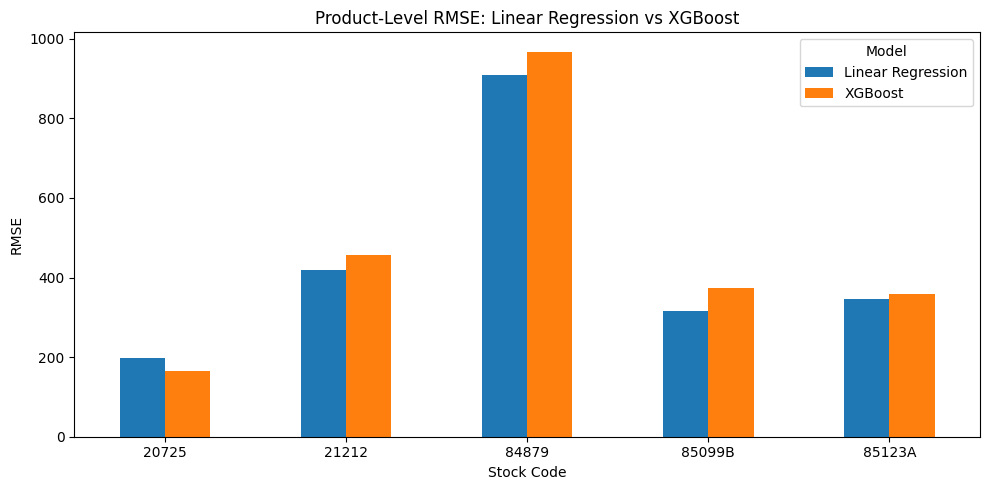

In [241]:
rmse_comparison = product_level_results.pivot(
    index="StockCode",
    columns="Model",
    values="RMSE"
)

rmse_comparison.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Product-Level RMSE: Linear Regression vs XGBoost")
plt.xlabel("Stock Code")
plt.ylabel("RMSE")
plt.xticks(rotation=0)
plt.legend(title="Model")

plt.tight_layout()
plt.show()

# 9. Refining the Forecasting Models

The previous stage established the initial forecasting pipeline and provided the first comparison between the baseline models, Linear Regression, and XGBoost.

Before moving to hyperparameter tuning and additional model families, I now refine the feature-based modelling setup.

The current Linear Regression and XGBoost models are trained globally using observations from all five selected products. However, product identity is not explicitly included as an input variable. The models currently distinguish products mainly through their historical lag and rolling-demand characteristics.

For a global forecasting model, it is more appropriate to also provide information about which product each observation belongs to.

Therefore, I add `StockCode` as a categorical predictor using one-hot encoding and then re-evaluate Linear Regression and XGBoost using the same chronological training and validation periods.

## 55. Adding Product Identity to the Global Models

The Linear Regression and XGBoost models are trained globally using observations from all five selected products.

However, the previous feature set did not explicitly tell the models which product each observation belonged to. The models could only distinguish products indirectly through their lag and rolling-demand patterns.

To address this, I add `StockCode` as a categorical predictor.

Because `StockCode` is a categorical variable rather than a numerical measurement, I convert it using **one-hot encoding**. This creates a separate binary variable for each product. For example, an observation belonging to product `20725` receives a value of 1 for `Product_20725` and 0 for the other product indicators.

This allows the global models to learn both common forecasting relationships across products and product-specific demand differences.

The chronological train and validation periods remain unchanged, so the updated results can still be compared directly with the previous models.

In [242]:
model_features_with_product = [
    "StockCode"
] + feature_columns

X_train_product = pd.get_dummies(
    train_data[model_features_with_product],
    columns=["StockCode"],
    prefix="Product"
)

X_validation_product = pd.get_dummies(
    validation_data[model_features_with_product],
    columns=["StockCode"],
    prefix="Product"
)

X_validation_product = X_validation_product.reindex(
    columns=X_train_product.columns,
    fill_value=0
)

print("Training feature shape:", X_train_product.shape)
print("Validation feature shape:", X_validation_product.shape)

print("\nProduct identity features:")
print([
    column
    for column in X_train_product.columns
    if column.startswith("Product_")
])

Training feature shape: (320, 19)
Validation feature shape: (65, 19)

Product identity features:
['Product_20725', 'Product_21212', 'Product_84879', 'Product_85099B', 'Product_85123A']


## 56. Updating Linear Regression With Product Identity

I first re-evaluate Linear Regression using the new feature set that includes the one-hot encoded product identity variables.

The purpose is to test whether explicitly identifying each product improves the global Linear Regression benchmark.

The training period, validation period, target variable, and temporal features remain unchanged. Therefore, any difference in performance can be attributed to the addition of product identity information.

In [243]:
linear_product_model = LinearRegression()

linear_product_model.fit(
    X_train_product,
    y_train
)

linear_product_predictions = (
    linear_product_model.predict(
        X_validation_product
    )
)

linear_product_metrics = forecasting_metrics(
    y_validation,
    linear_product_predictions
)

print("Updated Linear Regression Validation Metrics:")
print(f"MAE: {linear_product_metrics['MAE']:.2f}")
print(f"RMSE: {linear_product_metrics['RMSE']:.2f}")
print(f"sMAPE: {linear_product_metrics['sMAPE']:.2f}%")

Updated Linear Regression Validation Metrics:
MAE: 333.01
RMSE: 512.42
sMAPE: 53.86%


## 57. Updating XGBoost With Product Identity

I now repeat the same test with XGBoost.

The only change is the addition of the one-hot encoded product identity variables, so I can check whether XGBoost benefits from knowing which product each observation belongs to.

In [244]:
xgb_product_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_product_model.fit(
    X_train_product,
    y_train
)

xgb_product_predictions = (
    xgb_product_model.predict(
        X_validation_product
    )
)

xgb_product_metrics = forecasting_metrics(
    y_validation,
    xgb_product_predictions
)

print("Updated XGBoost Validation Metrics:")
print(f"MAE: {xgb_product_metrics['MAE']:.2f}")
print(f"RMSE: {xgb_product_metrics['RMSE']:.2f}")
print(f"sMAPE: {xgb_product_metrics['sMAPE']:.2f}%")

Updated XGBoost Validation Metrics:
MAE: 326.87
RMSE: 546.15
sMAPE: 52.30%


## 58. Chronological XGBoost Tuning

The initial XGBoost model has not been tuned yet.

Because this is a forecasting problem, I do not use random cross-validation. Instead, I use the fixed chronological training and validation periods already defined above.

I test a small set of important XGBoost parameters and select the combination with the lowest validation RMSE. A stronger expanding-window tuning procedure is introduced later in Meeting 5.


In [245]:
from sklearn.model_selection import ParameterGrid

xgb_param_grid = {
    "n_estimators": [200, 400, 600],
    "learning_rate": [0.01, 0.03, 0.05],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

tuning_results = []

for params in ParameterGrid(xgb_param_grid):

    model = XGBRegressor(
        **params,
        random_state=42,
        objective="reg:squarederror"
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_validation
    )

    metrics = forecasting_metrics(
        y_validation,
        predictions
    )

    tuning_results.append({
        **params,
        **metrics
    })

tuning_results = pd.DataFrame(
    tuning_results
)

best_xgb_result = (
    tuning_results
    .sort_values("RMSE")
    .iloc[0]
)

display(
    tuning_results
    .sort_values("RMSE")
    .head(10)
)

print("\nBest Parameters:")
print(best_xgb_result[
    [
        "n_estimators",
        "learning_rate",
        "max_depth",
        "subsample",
        "colsample_bytree"
    ]
])

print("\nBest Validation Metrics:")
print(f"MAE: {best_xgb_result['MAE']:.2f}")
print(f"RMSE: {best_xgb_result['RMSE']:.2f}")
print(f"sMAPE: {best_xgb_result['sMAPE']:.2f}%")

,colsample_bytree,learning_rate,max_depth,n_estimators,subsample,MAE,RMSE,sMAPE
67,1.00,0.01,4,200,1.00,299.24,513.60,50.51
13,0.80,0.01,4,200,1.00,297.99,515.55,50.04
69,1.00,0.01,4,400,1.00,298.25,517.89,50.05
78,1.00,0.03,3,200,0.80,298.37,518.75,49.72
7,0.80,0.01,3,200,1.00,300.66,519.10,50.38
79,1.00,0.03,3,200,1.00,298.19,519.78,49.70
61,1.00,0.01,3,200,1.00,298.30,520.21,50.07
66,1.00,0.01,4,200,0.80,302.58,520.32,50.71
11,0.80,0.01,3,600,1.00,299.02,520.50,49.70
71,1.00,0.01,4,600,1.00,303.69,520.52,50.67



Best Parameters:
n_estimators       200.00
learning_rate        0.01
max_depth            4.00
subsample            1.00
colsample_bytree     1.00
Name: 67, dtype: float64

Best Validation Metrics:
MAE: 299.24
RMSE: 513.60
sMAPE: 50.51%


## 59. Final Tuned XGBoost Model

I now train XGBoost again using the best parameter combination found during tuning.

I keep the same training and validation periods and save the validation predictions for the later model comparison.

In [246]:
tuned_xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.01,
    max_depth=4,
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42,
    objective="reg:squarederror"
)

tuned_xgb_model.fit(
    X_train,
    y_train
)

tuned_xgb_validation_predictions = (
    tuned_xgb_model.predict(
        X_validation
    )
)

tuned_xgb_metrics = forecasting_metrics(
    y_validation,
    tuned_xgb_validation_predictions
)

print("Tuned XGBoost Validation Metrics:")
print(f"MAE: {tuned_xgb_metrics['MAE']:.2f}")
print(f"RMSE: {tuned_xgb_metrics['RMSE']:.2f}")
print(f"sMAPE: {tuned_xgb_metrics['sMAPE']:.2f}%")


Tuned XGBoost Validation Metrics:
MAE: 299.24
RMSE: 513.60
sMAPE: 50.51%


## 60. Checking Whether Seasonal Modelling Is Suitable

Before fitting a classical time-series model, I first check whether the available history is long enough for yearly seasonality.

The full dataset contains 104 complete weeks, so a 52-week seasonal model would only have around two yearly cycles.

I therefore check the amount of training history before deciding whether SARIMA is appropriate.

In [247]:
classical_training_weeks = [
    week
    for week in complete_weeks
    if week < validation_weeks[0]
]

print(
    "Classical training weeks:",
    len(classical_training_weeks)
)

print(
    "Training period:",
    classical_training_weeks[0],
    "to",
    classical_training_weeks[-1]
)

print(
    "Approximate yearly cycles:",
    len(classical_training_weeks) / 52
)

Classical training weeks: 77
Training period: 2009-12-07 00:00:00 to 2011-05-23 00:00:00
Approximate yearly cycles: 1.4807692307692308


## 61. ARIMA Classical Forecasting Model

I use ARIMA as the classical statistical forecasting model.

Unlike Linear Regression and XGBoost, ARIMA models each product directly from its own historical demand sequence without using engineered lag or rolling features.

I test a small number of ARIMA specifications and select the best one using the same validation period.

## 62. Selecting the ARIMA Specification

I test a small set of ARIMA `(p, d, q)` combinations separately for each product.

For each specification, I train the model only on the historical training period and forecast the same validation weeks used by the other models.

I select the ARIMA order with the lowest validation RMSE for each product.

In [248]:
from statsmodels.tsa.arima.model import ARIMA
from itertools import product
import warnings

warnings.filterwarnings("ignore")

arima_orders = list(
    product(
        [0, 1, 2],
        [0, 1],
        [0, 1, 2]
    )
)

arima_results = []
arima_predictions = []

for stock_code in selected_products:

    product_series = (
        weekly_demand[
            weekly_demand["StockCode"] == stock_code
        ]
        .sort_values("Week")
        .set_index("Week")["WeeklyDemand"]
    )

    train_series = product_series[
        product_series.index < validation_weeks[0]
    ]

    validation_series = product_series[
        product_series.index.isin(validation_weeks)
    ]

    best_rmse = float("inf")
    best_order = None
    best_predictions = None

    for order in arima_orders:

        try:
            model = ARIMA(
                train_series,
                order=order
            )

            fitted_model = model.fit()

            predictions = fitted_model.forecast(
                steps=len(validation_series)
            )

            metrics = forecasting_metrics(
                validation_series.values,
                predictions.values
            )

            if metrics["RMSE"] < best_rmse:
                best_rmse = metrics["RMSE"]
                best_order = order
                best_predictions = predictions.values

        except:
            continue

    final_metrics = forecasting_metrics(
        validation_series.values,
        best_predictions
    )

    arima_results.append({
        "StockCode": stock_code,
        "BestOrder": best_order,
        **final_metrics
    })

    for week, actual, prediction in zip(
        validation_series.index,
        validation_series.values,
        best_predictions
    ):
        arima_predictions.append({
            "StockCode": stock_code,
            "Week": week,
            "WeeklyDemand": actual,
            "ARIMAPrediction": prediction
        })

arima_results = pd.DataFrame(
    arima_results
)

arima_predictions = pd.DataFrame(
    arima_predictions
)

display(arima_results)

,StockCode,BestOrder,MAE,RMSE,sMAPE
0,85123A,"(2, 1, 0)",453.95,494.47,69.97
1,85099B,"(1, 0, 2)",252.07,303.06,32.78
2,20725,"(1, 1, 2)",117.37,141.14,35.30
3,21212,"(1, 1, 2)",310.19,394.15,65.48
4,84879,"(2, 0, 1)",510.44,920.18,60.60


In [249]:
arima_overall_metrics = forecasting_metrics(
    arima_predictions["WeeklyDemand"],
    arima_predictions["ARIMAPrediction"]
)

print("Overall ARIMA Validation Metrics:")
print(f"MAE: {arima_overall_metrics['MAE']:.2f}")
print(f"RMSE: {arima_overall_metrics['RMSE']:.2f}")
print(f"sMAPE: {arima_overall_metrics['sMAPE']:.2f}%")

Overall ARIMA Validation Metrics:
MAE: 328.80
RMSE: 521.22
sMAPE: 52.83%


## 63. Preparing Sequential Data for LSTM

I now prepare the data for the recurrent neural-network model.

Unlike Linear Regression and XGBoost, LSTM uses sequences of previous demand values directly rather than manually created lag and rolling features.

I use the previous 13 weeks of demand to predict the following week. I keep the chronological training and validation periods unchanged.

## 64. Creating LSTM Sequences

For the LSTM model, I use the previous 13 weeks of demand to predict the next week.

I scale the demand values using only the training period to avoid data leakage.

The sequences from all five products are then combined into one global training dataset.

In [250]:
from sklearn.preprocessing import MinMaxScaler

sequence_length = 13

lstm_scaler = MinMaxScaler()

training_demand = weekly_demand[
    weekly_demand["Week"] < validation_weeks[0]
][["WeeklyDemand"]]

lstm_scaler.fit(training_demand)

scaled_weekly_demand = weekly_demand.copy()

scaled_weekly_demand["ScaledDemand"] = (
    lstm_scaler.transform(
        scaled_weekly_demand[["WeeklyDemand"]]
    )
)

X_lstm_train = []
y_lstm_train = []

X_lstm_validation = []
y_lstm_validation = []

lstm_validation_info = []

for stock_code in selected_products:

    product_data = (
        scaled_weekly_demand[
            scaled_weekly_demand["StockCode"] == stock_code
        ]
        .sort_values("Week")
        .reset_index(drop=True)
    )

    for i in range(
        sequence_length,
        len(product_data)
    ):

        target_week = product_data.loc[i, "Week"]

        sequence = product_data.loc[
            i - sequence_length:i - 1,
            "ScaledDemand"
        ].values

        target = product_data.loc[
            i,
            "ScaledDemand"
        ]

        if target_week in train_weeks:

            X_lstm_train.append(sequence)
            y_lstm_train.append(target)

        elif target_week in validation_weeks:

            X_lstm_validation.append(sequence)
            y_lstm_validation.append(target)

            lstm_validation_info.append({
                "StockCode": stock_code,
                "Week": target_week
            })

X_lstm_train = np.array(
    X_lstm_train
).reshape(-1, sequence_length, 1)

y_lstm_train = np.array(
    y_lstm_train
)

X_lstm_validation = np.array(
    X_lstm_validation
).reshape(-1, sequence_length, 1)

y_lstm_validation = np.array(
    y_lstm_validation
)

lstm_validation_info = pd.DataFrame(
    lstm_validation_info
)

print(
    "LSTM training shape:",
    X_lstm_train.shape
)

print(
    "LSTM validation shape:",
    X_lstm_validation.shape
)

print(
    "Training targets:",
    y_lstm_train.shape
)

print(
    "Validation targets:",
    y_lstm_validation.shape
)

LSTM training shape: (320, 13, 1)
LSTM validation shape: (65, 13, 1)
Training targets: (320,)
Validation targets: (65,)


## 65. Building the LSTM Model

I now build a small LSTM model for weekly demand forecasting.

Because the available training sample is relatively small, I keep the network simple to reduce the risk of overfitting.

In [251]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

lstm_model = Sequential([
    LSTM(
        32,
        input_shape=(sequence_length, 1)
    ),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    min_delta=0.0001,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_delta=0.0001,
    min_lr=0.00001
)

lstm_history = lstm_model.fit(
    X_lstm_train,
    y_lstm_train,
    validation_data=(
        X_lstm_validation,
        y_lstm_validation
    ),
    epochs=100,
    batch_size=16,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0162 - val_loss: 0.0102 - learning_rate: 0.0010
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0091 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0093 - val_loss: 0.0089 - learning_rate: 0.0010
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0095 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0092 - val_loss: 0.0087 - learning_rate: 0.0010
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0092 - val_loss: 0.0087 - learning_rate: 0.0010
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0092 - val_loss: 0.0087 - learning_rate: 0.0010
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0088 - val_loss: 0.0087 - learning_rate: 0.0010
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0090 - val_loss: 0.0086 - learning_rate: 0.0010
Epoch 10/100
20/

## 66. Evaluating the LSTM Model

I now generate forecasts for the validation period and convert the scaled values back to the original weekly-demand scale.

This allows the LSTM to be compared directly with Linear Regression, XGBoost, and ARIMA using MAE, RMSE, and sMAPE.

In [252]:
lstm_scaled_predictions = (
    lstm_model.predict(
        X_lstm_validation,
        verbose=0
    )
)

lstm_predictions = (
    lstm_scaler.inverse_transform(
        lstm_scaled_predictions
    )
    .flatten()
)

lstm_actual = (
    lstm_scaler.inverse_transform(
        y_lstm_validation.reshape(-1, 1)
    )
    .flatten()
)

lstm_metrics = forecasting_metrics(
    lstm_actual,
    lstm_predictions
)

print("LSTM Validation Metrics:")
print(f"MAE: {lstm_metrics['MAE']:.2f}")
print(f"RMSE: {lstm_metrics['RMSE']:.2f}")
print(f"sMAPE: {lstm_metrics['sMAPE']:.2f}%")

LSTM Validation Metrics:
MAE: 324.64
RMSE: 520.28
sMAPE: 54.72%


## 67. Updated Model Comparison

I now compare the main forecasting models using the same validation period and the same evaluation metrics.

This gives a clearer view of how the baseline, classical, machine-learning, and deep-learning approaches perform against each other.

In [253]:
updated_results = pd.DataFrame([
    {
        "Model": "Naive",
        **naive_metrics
    },
    {
        "Model": "Seasonal Naive",
        **seasonal_naive_metrics
    },
    {
        "Model": "Linear Regression",
        **linear_metrics
    },
    {
        "Model": "Initial XGBoost",
        **xgb_metrics
    },
    {
        "Model": "Tuned XGBoost",
        **tuned_xgb_metrics
    },
    {
        "Model": "ARIMA",
        **arima_overall_metrics
    },
    {
        "Model": "LSTM",
        **lstm_metrics
    }
])

display(
    updated_results.sort_values("RMSE")
)

,Model,MAE,RMSE,sMAPE
2,Linear Regression,295.34,501.92,50.04
4,Tuned XGBoost,299.24,513.60,50.51
6,LSTM,324.64,520.28,54.72
5,ARIMA,328.80,521.22,52.83
3,Initial XGBoost,315.20,536.94,51.51
1,Seasonal Naive,388.23,624.23,56.32
0,Naive,359.68,663.54,51.69


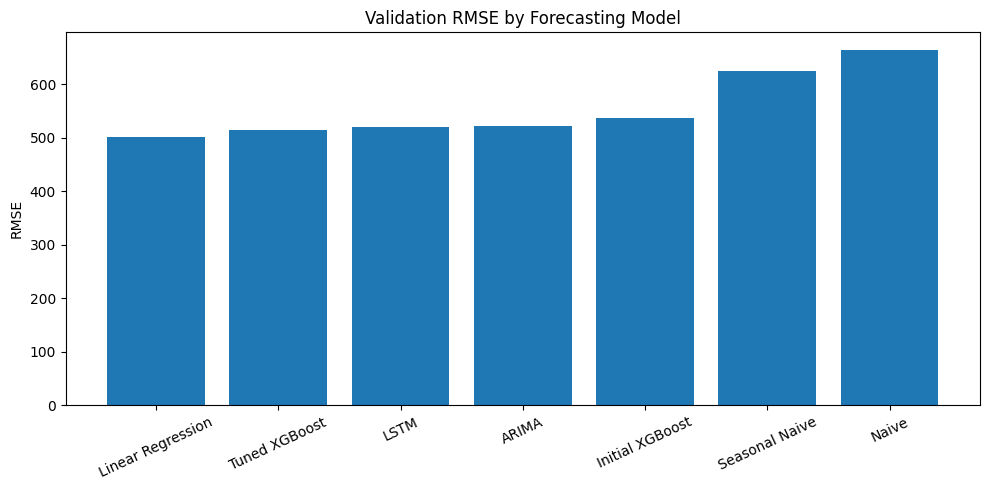

In [254]:
plt.figure(figsize=(10, 5))

comparison_plot = (
    updated_results
    .sort_values("RMSE")
)

plt.bar(
    comparison_plot["Model"],
    comparison_plot["RMSE"]
)

plt.title("Validation RMSE by Forecasting Model")
plt.ylabel("RMSE")
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

## 68. Product-Level Comparison Across Main Models

The overall results show which model performs best on average, but they can hide differences between individual products.

I therefore compare Linear Regression, Tuned XGBoost, ARIMA, and LSTM separately for each product using the same validation period.

In [255]:
# Add model predictions to one validation table

main_model_predictions = validation_data[
    ["StockCode", "Week", "WeeklyDemand"]
].copy()

main_model_predictions["LinearRegression"] = (
    linear_validation_predictions
)

main_model_predictions["TunedXGBoost"] = (
    tuned_xgb_validation_predictions
)

# Add ARIMA predictions
main_model_predictions = main_model_predictions.merge(
    arima_predictions[
        ["StockCode", "Week", "ARIMAPrediction"]
    ],
    on=["StockCode", "Week"],
    how="left"
)

# Add LSTM predictions
lstm_prediction_table = (
    lstm_validation_info.copy()
)

lstm_prediction_table["LSTMPrediction"] = (
    lstm_predictions
)

main_model_predictions = main_model_predictions.merge(
    lstm_prediction_table,
    on=["StockCode", "Week"],
    how="left"
)

display(main_model_predictions.head())

,StockCode,Week,WeeklyDemand,LinearRegression,TunedXGBoost,ARIMAPrediction,LSTMPrediction
0,20725,2011-05-30,170.00,439.81,350.71,298.65,517.62
1,20725,2011-06-06,564.00,514.34,348.83,346.10,516.17
2,20725,2011-06-13,185.00,559.47,431.85,298.66,527.85
3,20725,2011-06-20,218.00,404.19,382.26,346.10,525.87
4,20725,2011-06-27,183.00,420.23,331.39,298.66,520.88


In [256]:
main_product_results = []

for stock_code in selected_products:

    product_data = main_model_predictions[
        main_model_predictions["StockCode"] == stock_code
    ]

    for model_name, prediction_column in [
        ("Linear Regression", "LinearRegression"),
        ("Tuned XGBoost", "TunedXGBoost"),
        ("ARIMA", "ARIMAPrediction"),
        ("LSTM", "LSTMPrediction")
    ]:

        metrics = forecasting_metrics(
            product_data["WeeklyDemand"],
            product_data[prediction_column]
        )

        main_product_results.append({
            "StockCode": stock_code,
            "Model": model_name,
            **metrics
        })

main_product_results = pd.DataFrame(
    main_product_results
)

display(
    main_product_results.sort_values(
        ["StockCode", "RMSE"]
    )
)

,StockCode,Model,MAE,RMSE,sMAPE
10,20725,ARIMA,117.37,141.14,35.30
9,20725,Tuned XGBoost,165.27,183.18,45.99
8,20725,Linear Regression,164.50,198.88,46.02
11,20725,LSTM,209.20,237.67,54.39
14,21212,ARIMA,310.19,394.15,65.48
12,21212,Linear Regression,312.64,418.96,64.88
15,21212,LSTM,361.06,428.39,73.80
13,21212,Tuned XGBoost,335.18,430.33,69.76
16,84879,Linear Regression,445.03,908.42,50.90
18,84879,ARIMA,510.44,920.18,60.60


## 69. Best Model for Each Product

To summarise the product-level results, I identify the model with the lowest RMSE for each product.

This gives a simple view of whether the same forecasting approach works best across all products.

In [257]:
best_model_by_product = (
    main_product_results
    .sort_values("RMSE")
    .groupby("StockCode", as_index=False)
    .first()
)

display(
    best_model_by_product[
        [
            "StockCode",
            "Model",
            "MAE",
            "RMSE",
            "sMAPE"
        ]
    ]
)

,StockCode,Model,MAE,RMSE,sMAPE
0,20725,ARIMA,117.37,141.14,35.30
1,21212,ARIMA,310.19,394.15,65.48
2,84879,Linear Regression,445.03,908.42,50.90
3,85099B,ARIMA,252.07,303.06,32.78
4,85123A,LSTM,304.25,339.64,55.39


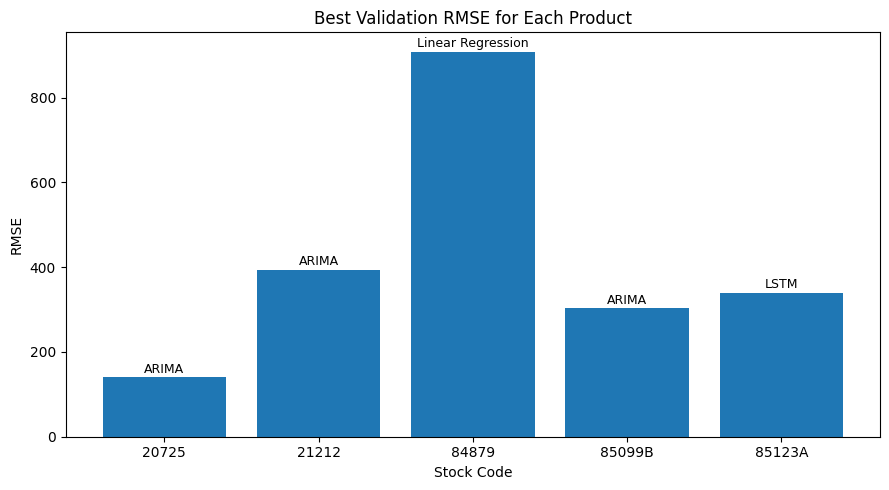

In [258]:
plt.figure(figsize=(9, 5))

plt.bar(
    best_model_by_product["StockCode"],
    best_model_by_product["RMSE"]
)

plt.title("Best Validation RMSE for Each Product")
plt.xlabel("Stock Code")
plt.ylabel("RMSE")

for i, row in best_model_by_product.iterrows():
    plt.text(
        i,
        row["RMSE"] + 10,
        row["Model"],
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## Product-Level Finding

The product-level results show a different picture from the overall ranking.

ARIMA performs best for three of the five products, Linear Regression performs best for one product, and LSTM performs best for one product.

This suggests that forecasting performance depends strongly on the demand characteristics of each product, and no single model is best in every case.

# 9. Model Development, Robustness and Larger-Sample Evaluation

In this stage, I first address the feedback from the previous meeting by looking more closely at the target, features, and product characteristics.

I then expand the analysis beyond the five pilot products and improve the final modelling setup before using the test period.

## 70. Weekly Demand Distribution

My forecasting target is `WeeklyDemand`, which is the total quantity sold for each product in each week.

I first check its distribution because strong skewness and extreme demand values can make forecasting more difficult and can have a large effect on RMSE.


count     520.00
mean      674.59
std       543.68
min         0.00
25%       324.50
50%       543.00
75%       881.50
max     5,584.00
Name: WeeklyDemand, dtype: float64

Skewness: 2.85
Zero-demand percentage: 1.92 %


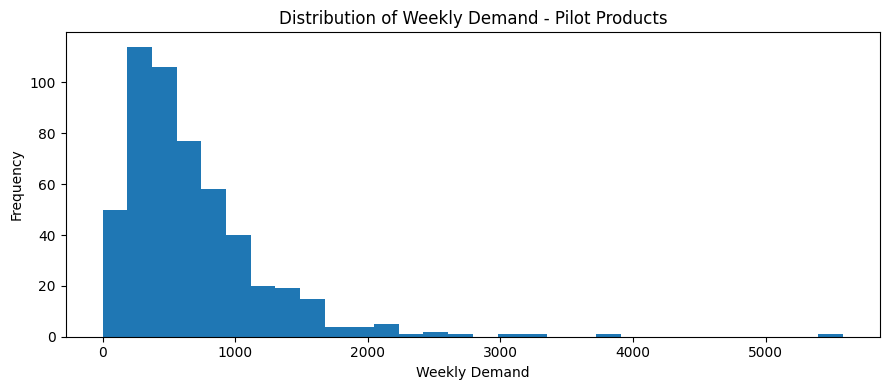

In [259]:
weekly_demand_summary = weekly_demand["WeeklyDemand"].describe()
weekly_demand_skew = weekly_demand["WeeklyDemand"].skew()
weekly_zero_percentage = (weekly_demand["WeeklyDemand"].eq(0).mean() * 100)

print(weekly_demand_summary)
print("\nSkewness:", round(weekly_demand_skew, 2))
print("Zero-demand percentage:", round(weekly_zero_percentage, 2), "%")

plt.figure(figsize=(9, 4))
plt.hist(weekly_demand["WeeklyDemand"], bins=30)
plt.title("Distribution of Weekly Demand - Pilot Products")
plt.xlabel("Weekly Demand")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## 71. Product-Level Demand Distributions

The overall target distribution can hide important differences between products.

I therefore summarise weekly demand separately for each of the five pilot products and compare their demand level, volatility, and skewness.


In [260]:
pilot_demand_distribution = (
    weekly_demand
    .groupby("StockCode")["WeeklyDemand"]
    .agg(
        Mean="mean",
        Median="median",
        Std="std",
        Min="min",
        Max="max",
        Skew="skew"
    )
    .reset_index()
)

display(pilot_demand_distribution.round(2))


,StockCode,Mean,Median,Std,Min,Max,Skew
0,20725,307.60,286.50,145.21,0.00,780.00,0.56
1,21212,680.26,526.00,452.91,0.00,"2,083.00",1.01
2,84879,703.49,557.50,707.84,0.00,"5,584.00",4.25
3,85099B,844.44,747.00,481.89,0.00,"2,636.00",1.00
4,85123A,837.15,713.00,580.75,0.00,"3,328.00",1.85


## 72. Selected Feature Distributions

I also inspect representative forecasting features rather than only the target.

The lag variables directly reflect previous weekly demand, while rolling statistics smooth the recent history. This helps me understand whether the model inputs have very different distributions and scales.


,count,mean,std,min,25%,50%,75%,max,Skew
lag_1,455.00,682.82,546.08,0.00,329.00,543.00,879.50,"5,584.00",3.00
lag_4,455.00,675.40,538.54,0.00,329.00,547.00,857.50,"5,584.00",3.10
lag_13,455.00,677.61,552.44,0.00,324.00,543.00,905.00,"5,584.00",2.93
rolling_mean_4,455.00,680.94,370.11,159.75,384.88,608.00,887.00,"2,477.75",1.29
rolling_mean_13,455.00,674.24,286.73,190.23,438.54,682.62,875.58,"1,579.23",0.49
rolling_std_13,455.00,390.28,272.53,68.36,205.39,309.39,505.81,"1,483.15",1.82


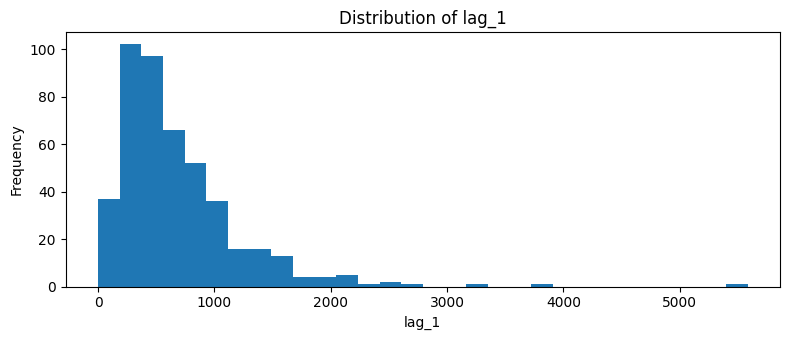

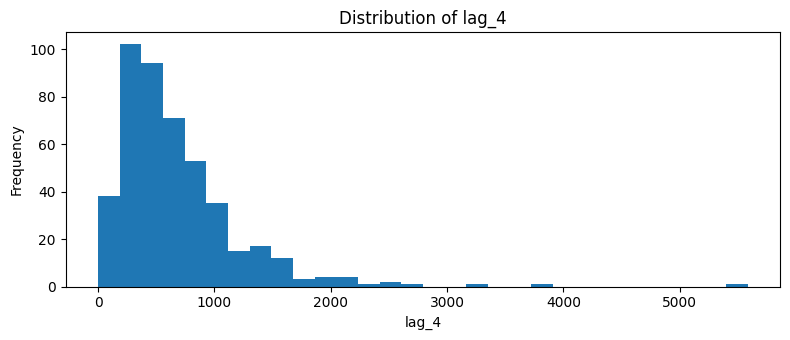

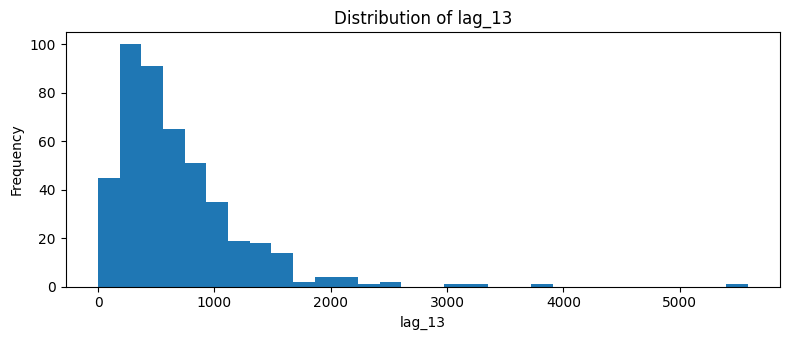

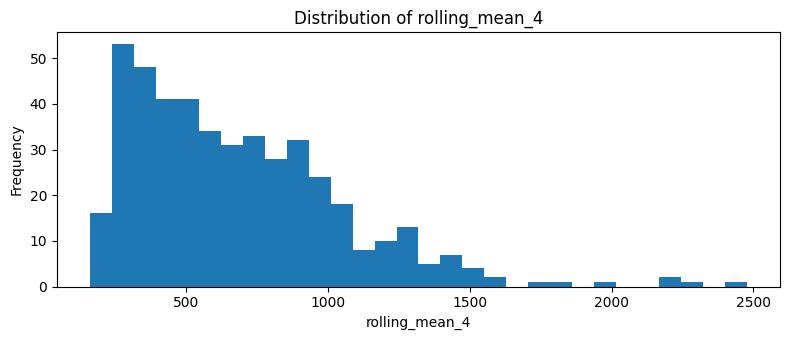

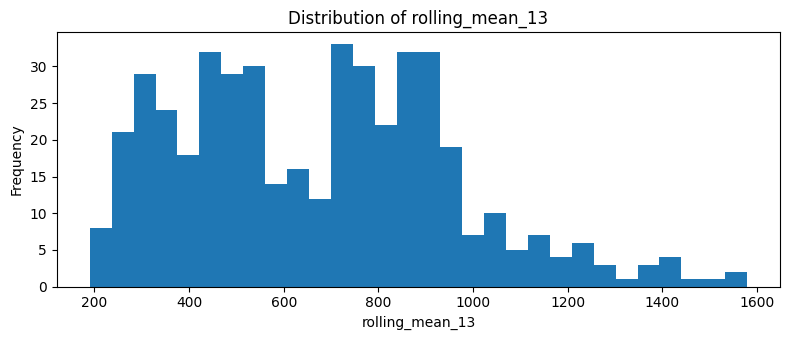

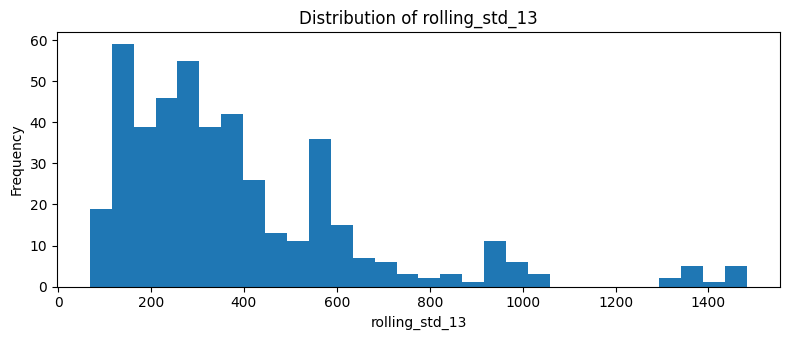

In [261]:
representative_features = [
    "lag_1",
    "lag_4",
    "lag_13",
    "rolling_mean_4",
    "rolling_mean_13",
    "rolling_std_13"
]

feature_distribution_summary = (
    model_data[representative_features]
    .describe()
    .T
)

feature_distribution_summary["Skew"] = (
    model_data[representative_features].skew()
)

display(feature_distribution_summary.round(2))

for feature in representative_features:
    plt.figure(figsize=(8, 3.5))
    plt.hist(model_data[feature], bins=30)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


## 73. Normalization for Forecasting Models

Normalization is not equally necessary for every model.

Linear Regression does not require scaling for prediction, and XGBoost is based on decision trees, so it is also not sensitive to feature scale.

LSTM is different because neural networks train more effectively with scaled inputs. For this reason, I already scale the LSTM demand values using a scaler fitted only on the training data.


In [262]:
from sklearn.preprocessing import StandardScaler

linear_scaler = StandardScaler()

X_train_scaled = linear_scaler.fit_transform(X_train)
X_validation_scaled = linear_scaler.transform(X_validation)

scaled_linear_model = LinearRegression()
scaled_linear_model.fit(X_train_scaled, y_train)

scaled_linear_predictions = scaled_linear_model.predict(
    X_validation_scaled
)

scaled_linear_metrics = forecasting_metrics(
    y_validation,
    scaled_linear_predictions
)

print("Original Linear Regression:")
print(linear_metrics)

print("\nStandardized Linear Regression:")
print(scaled_linear_metrics)

print(
    "\nMaximum absolute prediction difference:",
    np.max(np.abs(
        linear_validation_predictions - scaled_linear_predictions
    ))
)


Original Linear Regression:
{'MAE': 295.3367721882, 'RMSE': np.float64(501.9247919473868), 'sMAPE': np.float64(50.04120484728979)}

Standardized Linear Regression:
{'MAE': 295.33677218820276, 'RMSE': np.float64(501.9247919473876), 'sMAPE': np.float64(50.041204847290224)}

Maximum absolute prediction difference: 1.7621459846850485e-11


## 74. Checking LSTM Scaling Strategy

The pilot LSTM uses one global MinMax scaler across all five products.

I check whether the different product demand ranges cause some products to occupy only a small part of the global 0-1 range.


In [263]:
pilot_training_demand = weekly_demand[
    weekly_demand["Week"] < validation_weeks[0]
].copy()

pilot_training_ranges = (
    pilot_training_demand
    .groupby("StockCode")["WeeklyDemand"]
    .agg(["min", "max", "mean", "std"])
)

scaled_pilot_training = pilot_training_demand.copy()
scaled_pilot_training["GlobalScaledDemand"] = (
    lstm_scaler.transform(
        scaled_pilot_training[["WeeklyDemand"]]
    )
)

pilot_scaled_ranges = (
    scaled_pilot_training
    .groupby("StockCode")["GlobalScaledDemand"]
    .agg(["min", "max", "mean", "std"])
)

print("Training-period demand ranges:")
display(pilot_training_ranges.round(2))

print("\nRanges under the global MinMax scaler:")
display(pilot_scaled_ranges.round(2))


Training-period demand ranges:


,min,max,mean,std
StockCode,,,,
20725,0.00,780.00,306.09,150.82
21212,0.00,"2,083.00",769.13,460.55
84879,0.00,"5,584.00",684.65,712.62
85099B,0.00,"2,100.00",802.53,465.23
85123A,0.00,"3,328.00",936.16,614.90



Ranges under the global MinMax scaler:


,min,max,mean,std
StockCode,,,,
20725,0.00,0.14,0.05,0.03
21212,0.00,0.37,0.14,0.08
84879,0.00,1.00,0.12,0.13
85099B,0.00,0.38,0.14,0.08
85123A,0.00,0.60,0.17,0.11


## 75. Testing Product-Level Scaling for LSTM

I create a separate MinMax scaler for each product and fit every scaler only on observations before the validation period.

The sequence length and train-validation periods remain exactly the same as in the original LSTM so that only the scaling strategy changes.


In [264]:
product_lstm_scalers = {}
product_scaled_weekly = weekly_demand.copy()
product_scaled_weekly["ProductScaledDemand"] = np.nan

for stock_code in selected_products:
    scaler = MinMaxScaler()

    train_mask = (
        (product_scaled_weekly["StockCode"] == stock_code) &
        (product_scaled_weekly["Week"] < validation_weeks[0])
    )

    product_mask = (
        product_scaled_weekly["StockCode"] == stock_code
    )

    scaler.fit(
        product_scaled_weekly.loc[
            train_mask,
            ["WeeklyDemand"]
        ]
    )

    product_scaled_weekly.loc[
        product_mask,
        "ProductScaledDemand"
    ] = scaler.transform(
        product_scaled_weekly.loc[
            product_mask,
            ["WeeklyDemand"]
        ]
    ).ravel()

    product_lstm_scalers[stock_code] = scaler

X_product_scaled_train = []
y_product_scaled_train = []
X_product_scaled_validation = []
y_product_scaled_validation = []
product_scaled_validation_info = []

for stock_code in selected_products:
    product_data = (
        product_scaled_weekly[
            product_scaled_weekly["StockCode"] == stock_code
        ]
        .sort_values("Week")
        .reset_index(drop=True)
    )

    for i in range(sequence_length, len(product_data)):
        target_week = product_data.loc[i, "Week"]

        sequence = product_data.loc[
            i-sequence_length:i-1,
            "ProductScaledDemand"
        ].values

        target = product_data.loc[i, "ProductScaledDemand"]

        if target_week in train_weeks:
            X_product_scaled_train.append(sequence)
            y_product_scaled_train.append(target)

        elif target_week in validation_weeks:
            X_product_scaled_validation.append(sequence)
            y_product_scaled_validation.append(target)
            product_scaled_validation_info.append({
                "StockCode": stock_code,
                "Week": target_week
            })

X_product_scaled_train = np.array(
    X_product_scaled_train
).reshape(-1, sequence_length, 1)

y_product_scaled_train = np.array(
    y_product_scaled_train
)

X_product_scaled_validation = np.array(
    X_product_scaled_validation
).reshape(-1, sequence_length, 1)

y_product_scaled_validation = np.array(
    y_product_scaled_validation
)

product_scaled_validation_info = pd.DataFrame(
    product_scaled_validation_info
)

print("Training shape:", X_product_scaled_train.shape)
print("Validation shape:", X_product_scaled_validation.shape)


Training shape: (320, 13, 1)
Validation shape: (65, 13, 1)


## 76. Training the Product-Scaled LSTM

I train the same small LSTM architecture using the product-level scaled sequences.

Keeping the architecture unchanged makes the comparison focus on the scaling strategy rather than model complexity.


In [265]:
tf.keras.backend.clear_session()

np.random.seed(42)
tf.random.set_seed(42)

product_scaled_lstm = Sequential([
    LSTM(32, input_shape=(sequence_length, 1)),
    Dropout(0.2),
    Dense(1)
])

product_scaled_lstm.compile(
    optimizer="adam",
    loss="mse"
)

product_scaled_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    min_delta=0.0001,
    restore_best_weights=True
)

product_scaled_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_delta=0.0001,
    min_lr=0.00001
)

product_scaled_history = product_scaled_lstm.fit(
    X_product_scaled_train,
    y_product_scaled_train,
    validation_data=(
        X_product_scaled_validation,
        y_product_scaled_validation
    ),
    epochs=100,
    batch_size=16,
    callbacks=[
        product_scaled_early_stopping,
        product_scaled_reduce_lr
    ],
    verbose=1
)

product_scaled_best_epoch = (
    np.argmin(product_scaled_history.history["val_loss"]) + 1
)
product_scaled_best_val_loss = min(
    product_scaled_history.history["val_loss"]
)

print("Best epoch:", product_scaled_best_epoch)
print("Best validation loss:", round(product_scaled_best_val_loss, 5))


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.1207 - val_loss: 0.0379 - learning_rate: 0.0010
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0465 - val_loss: 0.0335 - learning_rate: 0.0010
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0401 - val_loss: 0.0323 - learning_rate: 0.0010
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0426 - val_loss: 0.0320 - learning_rate: 0.0010
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0396 - val_loss: 0.0316 - learning_rate: 0.0010
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0410 - val_loss: 0.0313 - learning_rate: 0.0010
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0402 - val_loss: 0.0312 - learning_rate: 0.0010
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0408 - val_loss: 0.0310 - learning_rate: 0.0010
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0391 - val_loss: 0.0309 - learning_rate: 0.0010
Epoch 10/100
20/

## 77. Evaluating Product-Level LSTM Scaling

I convert each product's predictions back to its original weekly demand scale and calculate the same validation metrics used for the other models.


In [266]:
product_scaled_predictions = product_scaled_lstm.predict(
    X_product_scaled_validation,
    verbose=0
).ravel()

product_scaled_actual_original = []
product_scaled_predictions_original = []

for i, row in product_scaled_validation_info.iterrows():
    stock_code = row["StockCode"]
    scaler = product_lstm_scalers[stock_code]

    actual_value = scaler.inverse_transform(
        [[y_product_scaled_validation[i]]]
    )[0, 0]

    predicted_value = scaler.inverse_transform(
        [[product_scaled_predictions[i]]]
    )[0, 0]

    product_scaled_actual_original.append(actual_value)
    product_scaled_predictions_original.append(predicted_value)

product_scaled_actual_original = np.array(
    product_scaled_actual_original
)
product_scaled_predictions_original = np.array(
    product_scaled_predictions_original
)

product_scaled_lstm_metrics = forecasting_metrics(
    product_scaled_actual_original,
    product_scaled_predictions_original
)

print("Product-Scaled LSTM:")
print(product_scaled_lstm_metrics)

print("\nOriginal Global-Scaled LSTM:")
print(lstm_metrics)


Product-Scaled LSTM:
{'MAE': 346.12505132464264, 'RMSE': np.float64(525.6890138491286), 'sMAPE': np.float64(55.88856430328419)}

Original Global-Scaled LSTM:
{'MAE': 324.6388394869291, 'RMSE': np.float64(520.2811948328103), 'sMAPE': np.float64(54.721560818351634)}


## 78. Making LSTM Training Reproducible

The LSTM results changed slightly when the model was retrained because neural-network optimisation includes stochastic operations.

I therefore fix the Python, NumPy, and TensorFlow random seeds and enable deterministic TensorFlow operations where available.


In [267]:
import os
import random

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("Reproducibility seed:", SEED)


Reproducibility seed: 42


## 79. Final Reproducible Global LSTM

I rebuild the original global-scaled LSTM after setting the deterministic configuration.

The architecture, sequence length, training data, and global MinMax scaling remain unchanged. This gives me one fixed LSTM result for the remaining comparisons.


In [268]:
tf.keras.backend.clear_session()

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

final_global_lstm = Sequential([
    LSTM(32, input_shape=(sequence_length, 1)),
    Dropout(0.2),
    Dense(1)
])

final_global_lstm.compile(
    optimizer="adam",
    loss="mse"
)

final_global_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    min_delta=0.0001,
    restore_best_weights=True
)

final_global_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_delta=0.0001,
    min_lr=0.00001
)

final_global_history = final_global_lstm.fit(
    X_lstm_train,
    y_lstm_train,
    validation_data=(X_lstm_validation, y_lstm_validation),
    epochs=100,
    batch_size=16,
    callbacks=[
        final_global_early_stopping,
        final_global_reduce_lr
    ],
    verbose=1
)

final_best_epoch = (
    np.argmin(final_global_history.history["val_loss"]) + 1
)
final_best_val_loss = min(
    final_global_history.history["val_loss"]
)

final_lstm_scaled_predictions = final_global_lstm.predict(
    X_lstm_validation,
    verbose=0
)

final_lstm_predictions = lstm_scaler.inverse_transform(
    final_lstm_scaled_predictions
).ravel()

final_lstm_actual = lstm_scaler.inverse_transform(
    y_lstm_validation.reshape(-1, 1)
).ravel()

final_global_lstm_metrics = forecasting_metrics(
    final_lstm_actual,
    final_lstm_predictions
)

# Lock the reproducible pilot LSTM aliases
lstm_model = final_global_lstm
lstm_predictions = final_lstm_predictions
lstm_actual = final_lstm_actual
lstm_metrics = final_global_lstm_metrics

print("Best epoch:", final_best_epoch)
print("Best validation loss:", round(final_best_val_loss, 5))
print("Final reproducible LSTM:")
print(final_global_lstm_metrics)


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0217 - val_loss: 0.0099 - learning_rate: 0.0010
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0106 - val_loss: 0.0094 - learning_rate: 0.0010
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0101 - val_loss: 0.0091 - learning_rate: 0.0010
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0100 - val_loss: 0.0092 - learning_rate: 0.0010
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0094 - val_loss: 0.0090 - learning_rate: 0.0010
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0098 - val_loss: 0.0089 - learning_rate: 0.0010
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0094 - val_loss: 0.0089 - learning_rate: 0.0010
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0094 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0093 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 10/100
20/20

## 80. Final Reproducible LSTM Product-Level Results

I recalculate the pilot product-level comparison using the fixed reproducible LSTM predictions.

This removes the small changes caused by repeated stochastic LSTM training and gives one consistent product-level result.


In [269]:
final_pilot_predictions = validation_data[
    ["StockCode", "Week", "WeeklyDemand"]
].copy()

final_pilot_predictions["LinearRegression"] = (
    linear_validation_predictions
)
final_pilot_predictions["TunedXGBoost"] = (
    tuned_xgb_validation_predictions
)

final_pilot_predictions = final_pilot_predictions.merge(
    arima_predictions[
        ["StockCode", "Week", "ARIMAPrediction"]
    ],
    on=["StockCode", "Week"],
    how="left"
)

final_pilot_lstm_table = lstm_validation_info.copy()
final_pilot_lstm_table["LSTMPrediction"] = final_lstm_predictions

final_pilot_predictions = final_pilot_predictions.merge(
    final_pilot_lstm_table,
    on=["StockCode", "Week"],
    how="left"
)

final_pilot_product_results = []

for stock_code in selected_products:
    product_data = final_pilot_predictions[
        final_pilot_predictions["StockCode"] == stock_code
    ]

    for model_name, prediction_column in [
        ("Linear Regression", "LinearRegression"),
        ("Tuned XGBoost", "TunedXGBoost"),
        ("ARIMA", "ARIMAPrediction"),
        ("LSTM", "LSTMPrediction")
    ]:
        metrics = forecasting_metrics(
            product_data["WeeklyDemand"],
            product_data[prediction_column]
        )

        final_pilot_product_results.append({
            "StockCode": stock_code,
            "Model": model_name,
            **metrics
        })

final_pilot_product_results = pd.DataFrame(
    final_pilot_product_results
)

final_best_model_by_product = (
    final_pilot_product_results
    .sort_values("RMSE")
    .groupby("StockCode", as_index=False)
    .first()
)

display(
    final_best_model_by_product[
        ["StockCode", "Model", "MAE", "RMSE", "sMAPE"]
    ].sort_values("StockCode")
)


,StockCode,Model,MAE,RMSE,sMAPE
0,20725,ARIMA,117.37,141.14,35.30
1,21212,ARIMA,310.19,394.15,65.48
2,84879,Linear Regression,445.03,908.42,50.90
3,85099B,ARIMA,252.07,303.06,32.78
4,85123A,LSTM,306.82,342.90,55.62


## 81. Demand Characteristics and Forecasting Error

The five pilot products show very different forecasting errors, so I compare their historical demand characteristics with the RMSE of the best-performing model.

This is exploratory because the pilot contains only five products. I therefore use it mainly to identify relationships that can later be tested on the larger sample.


In [270]:
pilot_characteristics = (
    weekly_demand
    .groupby("StockCode")["WeeklyDemand"]
    .agg(
        MeanDemand="mean",
        DemandStd="std",
        DemandSkew="skew"
    )
    .reset_index()
)

pilot_error_characteristics = (
    pilot_characteristics
    .merge(
        final_best_model_by_product[
            ["StockCode", "Model", "RMSE"]
        ],
        on="StockCode"
    )
    .rename(columns={
        "Model": "BestModel",
        "RMSE": "BestRMSE"
    })
)

display(pilot_error_characteristics.round(2))

pilot_characteristic_correlations = (
    pilot_error_characteristics[
        ["MeanDemand", "DemandStd", "DemandSkew", "BestRMSE"]
    ]
    .corr()["BestRMSE"]
    .drop("BestRMSE")
)

print("\nCorrelation with best RMSE:")
display(pilot_characteristic_correlations.round(2))


,StockCode,MeanDemand,DemandStd,DemandSkew,BestModel,BestRMSE
0,20725,307.60,145.21,0.56,ARIMA,141.14
1,21212,680.26,452.91,1.01,ARIMA,394.15
2,84879,703.49,707.84,4.25,Linear Regression,908.42
3,85099B,844.44,481.89,1.00,ARIMA,303.06
4,85123A,837.15,580.75,1.85,LSTM,342.90



Correlation with best RMSE:


,BestRMSE
MeanDemand,0.33
DemandStd,0.81
DemandSkew,0.96


## 82. Expanding Beyond Five Pilot Products

The five products were useful for developing and testing the forecasting framework, but they are too small a sample for general conclusions.

I therefore expand the analysis to the larger set of products that meet the activity criteria.

This allows me to test whether the relationships and model behaviour found in the pilot sample also appear across a more representative group of products.


In [271]:
# Standardise product codes before creating the larger sample
df_uk["StockCode"] = (
    df_uk["StockCode"]
    .astype(str)
    .str.strip()
)

eligible_product_codes = (
    eligible_products["StockCode"]
    .astype(str)
    .str.strip()
    .tolist()
)

print("Eligible products:", len(eligible_product_codes))
print("First five product codes:", eligible_product_codes[:5])

larger_transactions = df_uk[
    df_uk["StockCode"].isin(eligible_product_codes)
].copy()

print(
    "Transactions belonging to eligible products:",
    len(larger_transactions)
)


Eligible products: 1334
First five product codes: ['85123A', '85099B', '20725', '21212', '84879']
Transactions belonging to eligible products: 655375


## 83. Building the Larger Weekly Demand Dataset

I now expand the weekly demand dataset from the five pilot products to all 1,334 eligible products.

I use the same 104 complete weeks and the same weekly aggregation method as in the pilot analysis.

Weeks without sales are filled with zero so that every product has a complete weekly time series.


In [272]:
larger_transactions = df_uk[
    (df_uk["StockCode"].isin(eligible_product_codes)) &
    (df_uk["InvoiceDate"] >= complete_start) &
    (df_uk["InvoiceDate"] < complete_end + pd.Timedelta(days=7))
].copy()

larger_transactions["Week"] = (
    larger_transactions["InvoiceDate"]
    .dt.to_period("W-SUN")
    .dt.start_time
)

larger_weekly_demand = (
    larger_transactions
    .groupby(["StockCode", "Week"], as_index=False)
    .agg(WeeklyDemand=("Quantity", "sum"))
)

larger_product_week_index = pd.MultiIndex.from_product(
    [eligible_product_codes, complete_weeks],
    names=["StockCode", "Week"]
)

larger_weekly_demand = (
    larger_weekly_demand
    .set_index(["StockCode", "Week"])
    .reindex(larger_product_week_index)
    .reset_index()
)

larger_weekly_demand["WeeklyDemand"] = (
    larger_weekly_demand["WeeklyDemand"].fillna(0)
)

print("Products:", larger_weekly_demand["StockCode"].nunique())
print("Weeks:", larger_weekly_demand["Week"].nunique())
print("Shape:", larger_weekly_demand.shape)
print(
    "Non-zero observations:",
    (larger_weekly_demand["WeeklyDemand"] > 0).sum()
)

display(larger_weekly_demand.head())


Products: 1334
Weeks: 104
Shape: (138736, 3)
Non-zero observations: 108797


,StockCode,Week,WeeklyDemand
0,85123A,2009-12-07,"3,045.00"
1,85123A,2009-12-14,"1,255.00"
2,85123A,2009-12-21,127.00
3,85123A,2009-12-28,0.00
4,85123A,2010-01-04,"1,577.00"


## 84. Larger-Sample Demand Distribution

I inspect the target distribution again after expanding to 1,334 products.

This is important because the larger product pool may contain much lower-volume, more intermittent, and more extreme demand patterns than the five highly active pilot products.


count   138,736.00
mean         46.04
std         149.50
min           0.00
25%           1.00
50%          11.00
75%          39.00
max      11,366.00
Name: WeeklyDemand, dtype: float64

Skewness: 24.84
Zero-demand percentage: 21.58 %


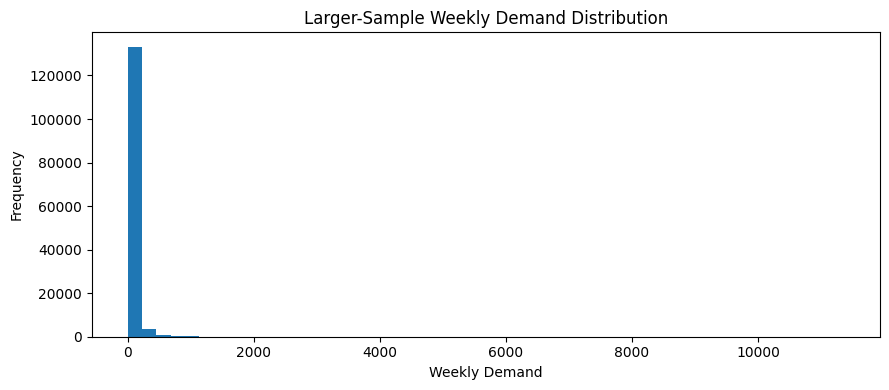

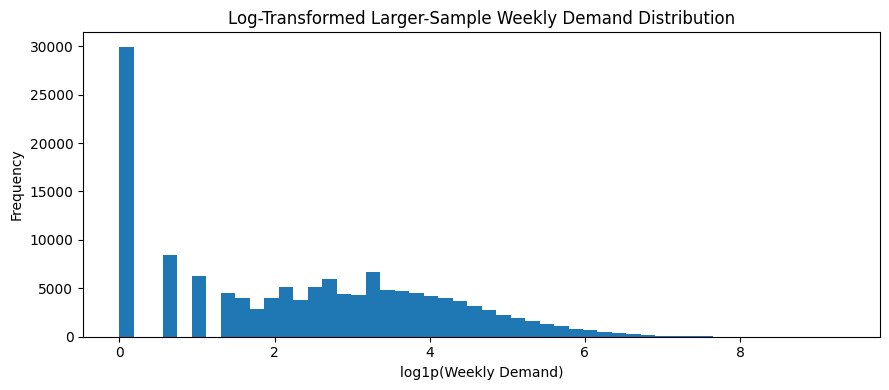

In [273]:
larger_demand_summary = larger_weekly_demand["WeeklyDemand"].describe()
larger_demand_skew = larger_weekly_demand["WeeklyDemand"].skew()
larger_zero_percentage = (
    larger_weekly_demand["WeeklyDemand"].eq(0).mean() * 100
)

print(larger_demand_summary)
print("\nSkewness:", round(larger_demand_skew, 2))
print("Zero-demand percentage:", round(larger_zero_percentage, 2), "%")

plt.figure(figsize=(9, 4))
plt.hist(larger_weekly_demand["WeeklyDemand"], bins=50)
plt.title("Larger-Sample Weekly Demand Distribution")
plt.xlabel("Weekly Demand")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.hist(np.log1p(larger_weekly_demand["WeeklyDemand"]), bins=50)
plt.title("Log-Transformed Larger-Sample Weekly Demand Distribution")
plt.xlabel("log1p(Weekly Demand)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## 85. Feature Engineering for the Larger Sample

I apply exactly the same leakage-safe feature engineering used in the pilot analysis.

This keeps the model comparison consistent while expanding the number of products.


In [274]:
larger_forecast_data = (
    larger_weekly_demand
    .sort_values(["StockCode", "Week"])
    .copy()
)

for lag in [1, 2, 4, 8, 13]:
    larger_forecast_data[f"lag_{lag}"] = (
        larger_forecast_data
        .groupby("StockCode")["WeeklyDemand"]
        .shift(lag)
    )

for window in [4, 8, 13]:
    shifted_demand = (
        larger_forecast_data
        .groupby("StockCode")["WeeklyDemand"]
        .shift(1)
    )

    larger_forecast_data[f"rolling_mean_{window}"] = (
        shifted_demand
        .groupby(larger_forecast_data["StockCode"])
        .transform(lambda x: x.rolling(window).mean())
    )

    larger_forecast_data[f"rolling_std_{window}"] = (
        shifted_demand
        .groupby(larger_forecast_data["StockCode"])
        .transform(lambda x: x.rolling(window).std())
    )

larger_forecast_data["month"] = larger_forecast_data["Week"].dt.month
larger_forecast_data["week_of_year"] = (
    larger_forecast_data["Week"].dt.isocalendar().week.astype(int)
)
larger_forecast_data["year"] = larger_forecast_data["Week"].dt.year

larger_feature_columns = feature_columns.copy()

larger_model_data = larger_forecast_data.dropna(
    subset=larger_feature_columns
).copy()

print("Shape:", larger_model_data.shape)
print("Products:", larger_model_data["StockCode"].nunique())
print("Target weeks:", larger_model_data["Week"].nunique())
print(
    "Period:",
    larger_model_data["Week"].min(),
    "to",
    larger_model_data["Week"].max()
)


Shape: (121394, 17)
Products: 1334
Target weeks: 91
Period: 2010-03-08 00:00:00 to 2011-11-28 00:00:00


## 86. Larger-Sample Chronological Split

I use the same chronological train, validation, and test periods as in the pilot analysis.

This keeps the evaluation consistent while increasing the number of products.

The final test period remains untouched during model development.


In [275]:
larger_train_data = larger_model_data[
    larger_model_data["Week"].isin(train_weeks)
].copy()

larger_validation_data = larger_model_data[
    larger_model_data["Week"].isin(validation_weeks)
].copy()

larger_test_data = larger_model_data[
    larger_model_data["Week"].isin(test_weeks)
].copy()

print("Training:")
print("Weeks:", larger_train_data["Week"].nunique())
print("Rows:", len(larger_train_data))
print(
    "Period:",
    larger_train_data["Week"].min(),
    "to",
    larger_train_data["Week"].max()
)

print("\nValidation:")
print("Weeks:", larger_validation_data["Week"].nunique())
print("Rows:", len(larger_validation_data))
print(
    "Period:",
    larger_validation_data["Week"].min(),
    "to",
    larger_validation_data["Week"].max()
)

print("\nTest:")
print("Weeks:", larger_test_data["Week"].nunique())
print("Rows:", len(larger_test_data))
print(
    "Period:",
    larger_test_data["Week"].min(),
    "to",
    larger_test_data["Week"].max()
)


Training:
Weeks: 64
Rows: 85376
Period: 2010-03-08 00:00:00 to 2011-05-23 00:00:00

Validation:
Weeks: 13
Rows: 17342
Period: 2011-05-30 00:00:00 to 2011-08-22 00:00:00

Test:
Weeks: 14
Rows: 18676
Period: 2011-08-29 00:00:00 to 2011-11-28 00:00:00


## 87. Larger-Sample Baseline Forecasts

Before training the larger machine-learning models, I recalculate the Naive and Seasonal Naive baselines for all 1,334 products.

These provide the reference point that the more advanced models should improve on.


In [276]:
larger_baseline_data = (
    larger_weekly_demand
    .sort_values(["StockCode", "Week"])
    .copy()
)

larger_baseline_data["lag_1"] = (
    larger_baseline_data
    .groupby("StockCode")["WeeklyDemand"]
    .shift(1)
)

larger_baseline_data["lag_52"] = (
    larger_baseline_data
    .groupby("StockCode")["WeeklyDemand"]
    .shift(52)
)

larger_baseline_validation = larger_baseline_data[
    larger_baseline_data["Week"].isin(validation_weeks)
].copy()

larger_naive_metrics = forecasting_metrics(
    larger_baseline_validation["WeeklyDemand"],
    larger_baseline_validation["lag_1"]
)

larger_seasonal_naive_metrics = forecasting_metrics(
    larger_baseline_validation["WeeklyDemand"],
    larger_baseline_validation["lag_52"]
)

print("Larger-Sample Naive:")
print(larger_naive_metrics)

print("\nLarger-Sample Seasonal Naive:")
print(larger_seasonal_naive_metrics)


Larger-Sample Naive:
{'MAE': 32.87631184407796, 'RMSE': np.float64(109.4542866238644), 'sMAPE': np.float64(98.36757277706701)}

Larger-Sample Seasonal Naive:
{'MAE': 43.327932187752275, 'RMSE': np.float64(121.13460770637407), 'sMAPE': np.float64(121.26390998302293)}


## 88. Larger-Sample Linear Regression

I now train Linear Regression using the same feature set as in the pilot analysis.

The objective is to test whether the strong pilot performance of the simple linear model remains when the sample is expanded to 1,334 products.


In [277]:
X_train_large = larger_train_data[larger_feature_columns]
y_train_large = larger_train_data["WeeklyDemand"]

X_validation_large = larger_validation_data[larger_feature_columns]
y_validation_large = larger_validation_data["WeeklyDemand"]

larger_linear_model = LinearRegression()
larger_linear_model.fit(X_train_large, y_train_large)

larger_linear_predictions = larger_linear_model.predict(
    X_validation_large
)

larger_linear_metrics = forecasting_metrics(
    y_validation_large,
    larger_linear_predictions
)

print("Larger-Sample Linear Regression:")
print(larger_linear_metrics)


Larger-Sample Linear Regression:
{'MAE': 25.92580006235278, 'RMSE': np.float64(76.54574717882637), 'sMAPE': np.float64(101.07425529123036)}


## 89. Larger-Sample XGBoost

I apply XGBoost to the same larger training and validation data.

I first use the tuned parameter configuration from the pilot stage so that I can test whether the earlier specification generalises to the larger sample.


In [278]:
larger_xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.01,
    max_depth=4,
    subsample=1.0,
    colsample_bytree=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

larger_xgb_model.fit(X_train_large, y_train_large)

larger_xgb_predictions = larger_xgb_model.predict(
    X_validation_large
)

larger_xgb_metrics = forecasting_metrics(
    y_validation_large,
    larger_xgb_predictions
)

print("Larger-Sample XGBoost:")
print(larger_xgb_metrics)


Larger-Sample XGBoost:
{'MAE': 29.657175595531303, 'RMSE': np.float64(76.62763056636588), 'sMAPE': np.float64(108.66176594403818)}


## 90. Re-testing Product Identity on the Larger Sample

Product identity did not improve the models in the five-product pilot.

However, the larger dataset contains 1,334 products with very different demand levels and patterns.

I therefore test product identity again to see whether it becomes more useful when the product sample is much more diverse.


In [279]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

larger_features_with_product = ["StockCode"] + larger_feature_columns

X_train_large_product = larger_train_data[
    larger_features_with_product
]
X_validation_large_product = larger_validation_data[
    larger_features_with_product
]

product_preprocessor = ColumnTransformer(
    transformers=[
        (
            "product",
            OneHotEncoder(handle_unknown="ignore"),
            ["StockCode"]
        )
    ],
    remainder="passthrough"
)

larger_linear_product_model = Pipeline([
    ("preprocessor", product_preprocessor),
    ("model", LinearRegression())
])

larger_linear_product_model.fit(
    X_train_large_product,
    y_train_large
)

larger_linear_product_predictions = (
    larger_linear_product_model.predict(
        X_validation_large_product
    )
)

larger_linear_product_metrics = forecasting_metrics(
    y_validation_large,
    larger_linear_product_predictions
)

print("Linear Regression without Product Identity:")
print(larger_linear_metrics)

print("\nLinear Regression with Product Identity:")
print(larger_linear_product_metrics)


Linear Regression without Product Identity:
{'MAE': 25.92580006235278, 'RMSE': np.float64(76.54574717882637), 'sMAPE': np.float64(101.07425529123036)}

Linear Regression with Product Identity:
{'MAE': 30.508026489878052, 'RMSE': np.float64(79.95656608376154), 'sMAPE': np.float64(107.10973163742332)}


## 91. Product Identity in Larger-Sample XGBoost

I also test product identity with XGBoost.

Although it did not help Linear Regression, XGBoost may use the product indicators differently because it can learn nonlinear interactions.


In [280]:
xgb_product_preprocessor = ColumnTransformer(
    transformers=[
        (
            "product",
            OneHotEncoder(handle_unknown="ignore"),
            ["StockCode"]
        )
    ],
    remainder="passthrough"
)

larger_xgb_product_model = Pipeline([
    ("preprocessor", xgb_product_preprocessor),
    (
        "model",
        XGBRegressor(
            n_estimators=200,
            learning_rate=0.01,
            max_depth=4,
            subsample=1.0,
            colsample_bytree=1.0,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )
    )
])

larger_xgb_product_model.fit(
    X_train_large_product,
    y_train_large
)

larger_xgb_product_predictions = (
    larger_xgb_product_model.predict(
        X_validation_large_product
    )
)

larger_xgb_product_metrics = forecasting_metrics(
    y_validation_large,
    larger_xgb_product_predictions
)

print("XGBoost without Product Identity:")
print(larger_xgb_metrics)

print("\nXGBoost with Product Identity:")
print(larger_xgb_product_metrics)


XGBoost without Product Identity:
{'MAE': 29.657175595531303, 'RMSE': np.float64(76.62763056636588), 'sMAPE': np.float64(108.66176594403818)}

XGBoost with Product Identity:
{'MAE': 30.470248252101843, 'RMSE': np.float64(78.56814719719081), 'sMAPE': np.float64(109.51384461906403)}


## 92. Preparing the Larger-Sample LSTM

The larger sample provides much more sequential training data for the LSTM.

Because weekly demand is highly skewed, I first apply a `log1p` transformation and then scale the transformed values using only observations before the validation period.

This reduces the influence of extreme demand spikes while still avoiding data leakage.


In [281]:
larger_lstm_data = (
    larger_weekly_demand
    .sort_values(["StockCode", "Week"])
    .copy()
)

larger_lstm_data["LogDemand"] = np.log1p(
    larger_lstm_data["WeeklyDemand"]
)

larger_lstm_scaler = MinMaxScaler()

larger_lstm_training_values = larger_lstm_data[
    larger_lstm_data["Week"] < validation_weeks[0]
][["LogDemand"]]

larger_lstm_scaler.fit(larger_lstm_training_values)

larger_lstm_data["ScaledDemand"] = (
    larger_lstm_scaler.transform(
        larger_lstm_data[["LogDemand"]]
    )
)

print(
    "Training observations used for scaling:",
    len(larger_lstm_training_values)
)
print(
    "Scaled range:",
    round(larger_lstm_data["ScaledDemand"].min(), 3),
    "to",
    round(larger_lstm_data["ScaledDemand"].max(), 3)
)


Training observations used for scaling: 102718
Scaled range: 0.0 to 1.0


## 93. Creating Larger-Sample LSTM Sequences

I convert the weekly demand series into 13-week sequences for all eligible products.

Each sequence uses the previous 13 weeks to predict the next week, and sequences are created separately within each product.

This gives the LSTM a much larger training sample than in the five-product pilot.


In [282]:
sequence_length = 13

X_lstm_train_large = []
y_lstm_train_large = []
X_lstm_validation_large = []
y_lstm_validation_large = []
lstm_validation_info_large = []

for stock_code in eligible_product_codes:
    product_data = (
        larger_lstm_data[
            larger_lstm_data["StockCode"] == stock_code
        ]
        .sort_values("Week")
        .reset_index(drop=True)
    )

    for i in range(sequence_length, len(product_data)):
        target_week = product_data.loc[i, "Week"]

        sequence = product_data.loc[
            i-sequence_length:i-1,
            "ScaledDemand"
        ].values

        target = product_data.loc[i, "ScaledDemand"]

        if target_week in train_weeks:
            X_lstm_train_large.append(sequence)
            y_lstm_train_large.append(target)

        elif target_week in validation_weeks:
            X_lstm_validation_large.append(sequence)
            y_lstm_validation_large.append(target)
            lstm_validation_info_large.append({
                "StockCode": stock_code,
                "Week": target_week
            })

X_lstm_train_large = np.array(
    X_lstm_train_large
).reshape(-1, sequence_length, 1)

y_lstm_train_large = np.array(y_lstm_train_large)

X_lstm_validation_large = np.array(
    X_lstm_validation_large
).reshape(-1, sequence_length, 1)

y_lstm_validation_large = np.array(y_lstm_validation_large)

lstm_validation_info_large = pd.DataFrame(
    lstm_validation_info_large
)

print("Training shape:", X_lstm_train_large.shape)
print("Validation shape:", X_lstm_validation_large.shape)


Training shape: (85376, 13, 1)
Validation shape: (17342, 13, 1)


## 94. Training the Larger-Sample LSTM

I train the LSTM on the larger sequence dataset.

I keep the same basic architecture as before so that the main differences are the much larger training sample and the preprocessing strategy.


In [283]:
tf.keras.backend.clear_session()

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

larger_lstm_model = Sequential([
    LSTM(32, input_shape=(sequence_length, 1)),
    Dropout(0.2),
    Dense(1)
])

larger_lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

larger_lstm_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    min_delta=0.0001,
    restore_best_weights=True
)

larger_lstm_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_delta=0.0001,
    min_lr=0.00001
)

larger_lstm_history = larger_lstm_model.fit(
    X_lstm_train_large,
    y_lstm_train_large,
    validation_data=(
        X_lstm_validation_large,
        y_lstm_validation_large
    ),
    epochs=100,
    batch_size=64,
    callbacks=[
        larger_lstm_early_stopping,
        larger_lstm_reduce_lr
    ],
    verbose=1
)

best_epoch_large = (
    np.argmin(larger_lstm_history.history["val_loss"]) + 1
)
best_val_loss_large = min(
    larger_lstm_history.history["val_loss"]
)

print("Best epoch:", best_epoch_large)
print("Best validation loss:", round(best_val_loss_large, 5))


Epoch 1/100
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0206 - val_loss: 0.0149 - learning_rate: 0.0010
Epoch 2/100
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.0177 - val_loss: 0.0150 - learning_rate: 0.0010
Epoch 3/100
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0175 - val_loss: 0.0151 - learning_rate: 0.0010
Epoch 4/100
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0174 - val_loss: 0.0151 - learning_rate: 0.0010
Epoch 5/100
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.0173 - val_loss: 0.0152 - learning_rate: 0.0010
Epoch 6/100
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0172 - val_loss: 0.0151 - learning_rate: 5.0000e-04
Epoch 7/100
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0171 - val_loss: 0.0150 - learning_rate: 5.0000e-04
Epoch 8/100
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.0170 - val_loss: 0.0150 - learning_rate: 5.0000e-04
Epoch 9/100
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0170 - val_loss: 0

## 95. Evaluating the Larger-Sample LSTM

I convert the LSTM predictions back to the original weekly demand scale.

This allows a direct comparison with Linear Regression, XGBoost, and the baseline models using the same evaluation metrics.


In [284]:
larger_lstm_scaled_predictions = larger_lstm_model.predict(
    X_lstm_validation_large,
    verbose=0
)

larger_lstm_log_predictions = (
    larger_lstm_scaler.inverse_transform(
        larger_lstm_scaled_predictions
    ).ravel()
)

larger_lstm_log_actual = (
    larger_lstm_scaler.inverse_transform(
        y_lstm_validation_large.reshape(-1, 1)
    ).ravel()
)

larger_lstm_predictions = np.expm1(
    larger_lstm_log_predictions
)
larger_lstm_actual = np.expm1(
    larger_lstm_log_actual
)

larger_lstm_predictions = np.maximum(
    larger_lstm_predictions,
    0
)

larger_lstm_metrics = forecasting_metrics(
    larger_lstm_actual,
    larger_lstm_predictions
)

print("Larger-Sample LSTM:")
print(larger_lstm_metrics)


Larger-Sample LSTM:
{'MAE': 24.406604476981943, 'RMSE': np.float64(82.01582459121573), 'sMAPE': np.float64(101.69188393812227)}


## 96. Larger-Sample Model Comparison

I compare the models using the same larger validation period.

This provides the first larger-sample view of whether the model ranking found in the five-product pilot remains similar after expanding to 1,334 products.


,Model,MAE,RMSE,sMAPE
0,Linear Regression,25.93,76.55,101.07
1,XGBoost,29.66,76.63,108.66
2,LSTM,24.41,82.02,101.69
3,Naive,32.88,109.45,98.37
4,Seasonal Naive,43.33,121.13,121.26


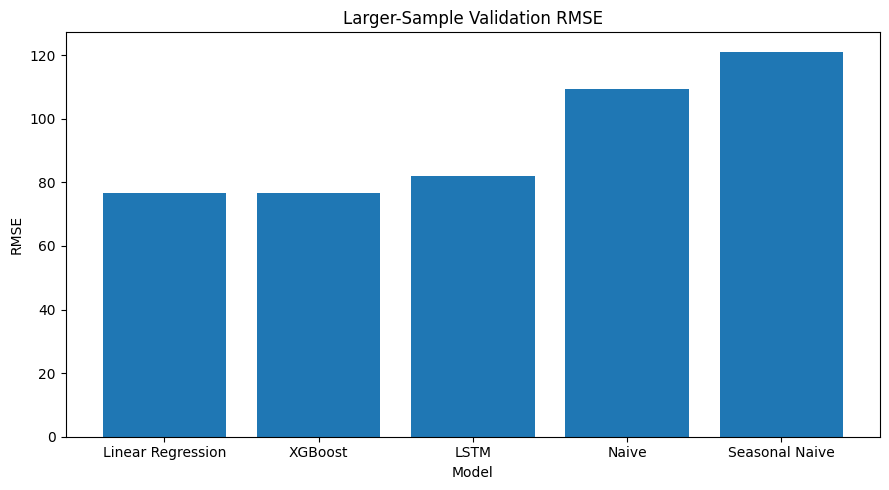

In [285]:
larger_results = pd.DataFrame([
    {"Model": "Naive", **larger_naive_metrics},
    {"Model": "Seasonal Naive", **larger_seasonal_naive_metrics},
    {"Model": "Linear Regression", **larger_linear_metrics},
    {"Model": "XGBoost", **larger_xgb_metrics},
    {"Model": "LSTM", **larger_lstm_metrics}
])

larger_results = (
    larger_results
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(larger_results.round(2))

plt.figure(figsize=(9, 5))
plt.bar(larger_results["Model"], larger_results["RMSE"])
plt.title("Larger-Sample Validation RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()


## 97. Product-Level Forecasting Error on the Larger Sample

The overall metrics combine all 1,334 products, so they can hide substantial product-level differences.

I align the Linear Regression, XGBoost, and LSTM validation predictions by product and week before calculating product-level errors.


In [286]:
large_product_predictions = larger_validation_data[
    ["StockCode", "Week", "WeeklyDemand"]
].copy()

large_product_predictions["LinearPrediction"] = (
    larger_linear_predictions
)
large_product_predictions["XGBoostPrediction"] = (
    larger_xgb_predictions
)

large_lstm_predictions_df = lstm_validation_info_large.copy()
large_lstm_predictions_df["LSTMPrediction"] = (
    larger_lstm_predictions
)

large_product_predictions = large_product_predictions.merge(
    large_lstm_predictions_df,
    on=["StockCode", "Week"],
    how="left"
)

print("Rows:", len(large_product_predictions))
display(large_product_predictions.head())


Rows: 17342


,StockCode,Week,WeeklyDemand,LinearPrediction,XGBoostPrediction,LSTMPrediction
0,10002,2011-05-30,0.00,3.24,13.85,0.91
1,10002,2011-06-06,0.00,10.64,13.80,0.78
2,10002,2011-06-13,0.00,6.43,13.27,0.71
3,10002,2011-06-20,0.00,4.67,13.27,0.67
4,10002,2011-06-27,0.00,2.94,13.27,0.65


## 98. Product Characteristics and Forecasting Difficulty

I calculate forecasting error separately for each product and compare it with its historical demand characteristics.

The product characteristics are calculated only from weeks before the validation period, so future demand is not used.

I also calculate a normalized RMSE because raw RMSE can naturally be higher for products with larger demand levels.


In [287]:
historical_product_data = larger_weekly_demand[
    larger_weekly_demand["Week"] < validation_weeks[0]
].copy()

larger_product_characteristics = (
    historical_product_data
    .groupby("StockCode")["WeeklyDemand"]
    .agg(
        MeanDemand="mean",
        DemandStd="std",
        DemandSkew="skew"
    )
    .reset_index()
)

zero_share = (
    historical_product_data
    .assign(IsZero=lambda x: x["WeeklyDemand"] == 0)
    .groupby("StockCode")["IsZero"]
    .mean()
    .mul(100)
    .reset_index(name="ZeroDemandPct")
)

larger_product_characteristics = (
    larger_product_characteristics
    .merge(zero_share, on="StockCode")
)

product_error_rows = []

for stock_code, group in large_product_predictions.groupby("StockCode"):
    product_error_rows.append({
        "StockCode": stock_code,
        "LinearRMSE": np.sqrt(mean_squared_error(
            group["WeeklyDemand"],
            group["LinearPrediction"]
        )),
        "XGBoostRMSE": np.sqrt(mean_squared_error(
            group["WeeklyDemand"],
            group["XGBoostPrediction"]
        )),
        "LSTMRMSE": np.sqrt(mean_squared_error(
            group["WeeklyDemand"],
            group["LSTMPrediction"]
        ))
    })

larger_product_errors = pd.DataFrame(product_error_rows)

larger_product_analysis = (
    larger_product_characteristics
    .merge(larger_product_errors, on="StockCode")
)

for model in ["Linear", "XGBoost", "LSTM"]:
    larger_product_analysis[f"{model}NRMSE"] = (
        larger_product_analysis[f"{model}RMSE"]
        / larger_product_analysis["MeanDemand"].clip(lower=1)
    )

print("Products:", len(larger_product_analysis))

display(
    larger_product_analysis[
        [
            "StockCode",
            "MeanDemand",
            "DemandStd",
            "DemandSkew",
            "ZeroDemandPct",
            "LinearRMSE",
            "XGBoostRMSE",
            "LSTMRMSE"
        ]
    ].head()
)


Products: 1334


,StockCode,MeanDemand,DemandStd,DemandSkew,ZeroDemandPct,LinearRMSE,XGBoostRMSE,LSTMRMSE
0,10002,84.99,169.59,3.69,11.69,5.40,13.36,0.69
1,10125,14.60,20.68,1.98,36.36,12.92,15.15,14.96
2,10133,16.12,20.39,1.66,25.97,78.23,74.32,101.72
3,10135,40.36,97.60,5.54,15.58,38.09,39.26,39.70
4,11001,43.31,94.41,4.31,25.97,102.67,102.66,107.85


## 99. Relationship Between Demand Characteristics and Forecasting Error

I test how demand level, volatility, skewness, and zero-demand frequency are related to forecasting error.

I examine both raw RMSE and normalized RMSE. This helps separate genuine forecasting difficulty from the effect of different demand scales across products.

I report both Pearson and Spearman correlations because the larger demand distribution is strongly skewed.


In [288]:
characteristic_columns = [
    "MeanDemand",
    "DemandStd",
    "DemandSkew",
    "ZeroDemandPct"
]

error_columns = [
    "LinearRMSE",
    "XGBoostRMSE",
    "LSTMRMSE",
    "LinearNRMSE",
    "XGBoostNRMSE",
    "LSTMNRMSE"
]

pearson_correlations = (
    larger_product_analysis[
        characteristic_columns + error_columns
    ]
    .corr(method="pearson")
    .loc[characteristic_columns, error_columns]
)

spearman_correlations = (
    larger_product_analysis[
        characteristic_columns + error_columns
    ]
    .corr(method="spearman")
    .loc[characteristic_columns, error_columns]
)

print("Pearson Correlations:")
display(pearson_correlations.round(2))

print("\nSpearman Correlations:")
display(spearman_correlations.round(2))


Pearson Correlations:


,LinearRMSE,XGBoostRMSE,LSTMRMSE,LinearNRMSE,XGBoostNRMSE,LSTMNRMSE
MeanDemand,0.72,0.71,0.74,-0.13,-0.21,-0.09
DemandStd,0.55,0.55,0.55,-0.11,-0.18,-0.08
DemandSkew,-0.09,-0.07,-0.09,0.02,0.06,0.01
ZeroDemandPct,-0.19,-0.19,-0.19,0.24,0.32,0.22



Spearman Correlations:


,LinearRMSE,XGBoostRMSE,LSTMRMSE,LinearNRMSE,XGBoostNRMSE,LSTMNRMSE
MeanDemand,0.71,0.69,0.68,-0.39,-0.68,-0.12
DemandStd,0.65,0.65,0.62,-0.35,-0.60,-0.12
DemandSkew,-0.19,-0.15,-0.20,0.03,0.14,-0.06
ZeroDemandPct,-0.27,-0.24,-0.25,0.36,0.46,0.23


## 100. Testing the Effect of Log Transformation on LSTM

The larger-sample LSTM currently uses a log transformation before MinMax scaling because demand is highly skewed.

To check whether this preprocessing choice actually improves forecasting performance, I compare it with the same LSTM architecture using raw demand with MinMax scaling only.


In [289]:
larger_raw_lstm_data = (
    larger_weekly_demand
    .sort_values(["StockCode", "Week"])
    .copy()
)

larger_raw_scaler = MinMaxScaler()

raw_scaler_training = larger_raw_lstm_data[
    larger_raw_lstm_data["Week"] < validation_weeks[0]
][["WeeklyDemand"]]

larger_raw_scaler.fit(raw_scaler_training)

larger_raw_lstm_data["ScaledDemand"] = (
    larger_raw_scaler.transform(
        larger_raw_lstm_data[["WeeklyDemand"]]
    )
)

X_raw_train = []
y_raw_train = []
X_raw_validation = []
y_raw_validation = []

for stock_code in eligible_product_codes:
    product_data = (
        larger_raw_lstm_data[
            larger_raw_lstm_data["StockCode"] == stock_code
        ]
        .sort_values("Week")
        .reset_index(drop=True)
    )

    for i in range(sequence_length, len(product_data)):
        target_week = product_data.loc[i, "Week"]

        sequence = product_data.loc[
            i-sequence_length:i-1,
            "ScaledDemand"
        ].values

        target = product_data.loc[i, "ScaledDemand"]

        if target_week in train_weeks:
            X_raw_train.append(sequence)
            y_raw_train.append(target)

        elif target_week in validation_weeks:
            X_raw_validation.append(sequence)
            y_raw_validation.append(target)

X_raw_train = np.array(X_raw_train).reshape(
    -1, sequence_length, 1
)
y_raw_train = np.array(y_raw_train)

X_raw_validation = np.array(X_raw_validation).reshape(
    -1, sequence_length, 1
)
y_raw_validation = np.array(y_raw_validation)

print("Training shape:", X_raw_train.shape)
print("Validation shape:", X_raw_validation.shape)


Training shape: (85376, 13, 1)
Validation shape: (17342, 13, 1)


In [290]:
tf.keras.backend.clear_session()

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

raw_lstm_model = Sequential([
    LSTM(32, input_shape=(sequence_length, 1)),
    Dropout(0.2),
    Dense(1)
])

raw_lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

raw_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    min_delta=0.0001,
    restore_best_weights=True
)

raw_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_delta=0.0001,
    min_lr=0.00001
)

raw_lstm_history = raw_lstm_model.fit(
    X_raw_train,
    y_raw_train,
    validation_data=(X_raw_validation, y_raw_validation),
    epochs=100,
    batch_size=64,
    callbacks=[raw_early_stopping, raw_reduce_lr],
    verbose=1
)

raw_best_epoch = (
    np.argmin(raw_lstm_history.history["val_loss"]) + 1
)
raw_best_val_loss = min(
    raw_lstm_history.history["val_loss"]
)

print("Best epoch:", raw_best_epoch)
print("Best validation loss:", round(raw_best_val_loss, 5))


Epoch 1/100
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 1.7818e-04 - val_loss: 5.1924e-05 - learning_rate: 0.0010
Epoch 2/100
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 1.7194e-04 - val_loss: 4.9677e-05 - learning_rate: 0.0010
Epoch 3/100
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 1.7088e-04 - val_loss: 5.0845e-05 - learning_rate: 0.0010
Epoch 4/100
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 1.6983e-04 - val_loss: 4.8517e-05 - learning_rate: 0.0010
Epoch 5/100
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 1.6921e-04 - val_loss: 4.7365e-05 - learning_rate: 0.0010
Epoch 6/100
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 1.6740e-04 - val_loss: 4.6210e-05 - learning_rate: 5.0000e-04
Epoch 7/100
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 1.6716e-04 - val_loss: 4.6246e-05 - learning_rate: 5.0000e-04
Epoch 8/100
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 1.6724e-04 - val_loss: 4.6211e-05 - learning_rate: 5.0000e-04
Epoch 9/100
1334/13

## 101. Comparing LSTM Preprocessing Strategies

I convert the raw-demand LSTM predictions back to the original demand scale and compare them with the log-transformed LSTM.

This allows the preprocessing choice to be evaluated using the same MAE, RMSE, and sMAPE metrics.


In [291]:
raw_lstm_scaled_predictions = raw_lstm_model.predict(
    X_raw_validation,
    verbose=0
)

raw_lstm_predictions = larger_raw_scaler.inverse_transform(
    raw_lstm_scaled_predictions
).ravel()

raw_lstm_actual = larger_raw_scaler.inverse_transform(
    y_raw_validation.reshape(-1, 1)
).ravel()

raw_lstm_predictions = np.maximum(raw_lstm_predictions, 0)

raw_lstm_metrics = forecasting_metrics(
    raw_lstm_actual,
    raw_lstm_predictions
)

print("Raw MinMax LSTM:")
print(raw_lstm_metrics)

print("\nLog1p + MinMax LSTM:")
print(larger_lstm_metrics)


Raw MinMax LSTM:
{'MAE': 26.551664381641576, 'RMSE': np.float64(81.00958849305195), 'sMAPE': np.float64(121.15597660104737)}

Log1p + MinMax LSTM:
{'MAE': 24.406604476981943, 'RMSE': np.float64(82.01582459121573), 'sMAPE': np.float64(101.69188393812227)}


## 102. Final Larger-Sample LSTM Specification

I lock the raw-MinMax LSTM as the final larger-sample LSTM specification so that all later product-level comparisons use the same model consistently.


In [292]:
final_larger_lstm_model = raw_lstm_model
final_larger_lstm_predictions = raw_lstm_predictions
final_larger_lstm_actual = raw_lstm_actual
final_larger_lstm_metrics = raw_lstm_metrics

print("Final Larger-Sample LSTM:")
print(final_larger_lstm_metrics)


Final Larger-Sample LSTM:
{'MAE': 26.551664381641576, 'RMSE': np.float64(81.00958849305195), 'sMAPE': np.float64(121.15597660104737)}


## 103. Updated Larger-Sample Model Comparison

I update the larger-sample comparison using the final raw-MinMax LSTM specification.


,Model,MAE,RMSE,sMAPE
0,Linear Regression,25.93,76.55,101.07
1,XGBoost,29.66,76.63,108.66
2,LSTM,26.55,81.01,121.16
3,Naive,32.88,109.45,98.37
4,Seasonal Naive,43.33,121.13,121.26


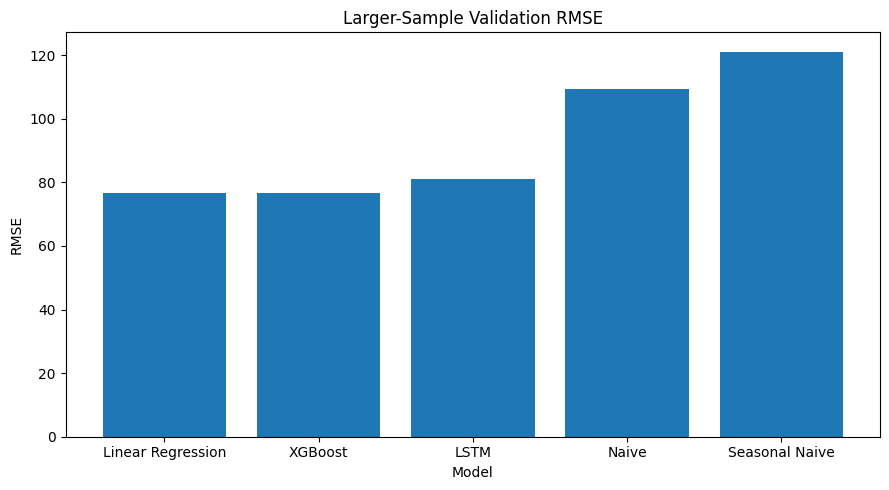

In [293]:
larger_results = pd.DataFrame([
    {"Model": "Naive", **larger_naive_metrics},
    {"Model": "Seasonal Naive", **larger_seasonal_naive_metrics},
    {"Model": "Linear Regression", **larger_linear_metrics},
    {"Model": "XGBoost", **larger_xgb_metrics},
    {"Model": "LSTM", **final_larger_lstm_metrics}
])

larger_results = (
    larger_results
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(larger_results.round(2))

plt.figure(figsize=(9, 5))
plt.bar(larger_results["Model"], larger_results["RMSE"])
plt.title("Larger-Sample Validation RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()


## 104. Best Model by Product

I identify the lowest-RMSE model for each product using Linear Regression, the current XGBoost specification, and the final raw-MinMax LSTM.

This shows whether one model performs consistently best or whether model performance depends on the individual product.


In [294]:
large_product_predictions = larger_validation_data[
    ["StockCode", "Week", "WeeklyDemand"]
].copy()

large_product_predictions["LinearPrediction"] = (
    larger_linear_predictions
)
large_product_predictions["XGBoostPrediction"] = (
    larger_xgb_predictions
)

final_lstm_predictions_df = lstm_validation_info_large.copy()
final_lstm_predictions_df["LSTMPrediction"] = (
    final_larger_lstm_predictions
)

large_product_predictions = large_product_predictions.merge(
    final_lstm_predictions_df,
    on=["StockCode", "Week"],
    how="left"
)

product_error_rows = []

for stock_code, group in large_product_predictions.groupby("StockCode"):
    product_error_rows.append({
        "StockCode": stock_code,
        "LinearRMSE": np.sqrt(mean_squared_error(
            group["WeeklyDemand"], group["LinearPrediction"]
        )),
        "XGBoostRMSE": np.sqrt(mean_squared_error(
            group["WeeklyDemand"], group["XGBoostPrediction"]
        )),
        "LSTMRMSE": np.sqrt(mean_squared_error(
            group["WeeklyDemand"], group["LSTMPrediction"]
        ))
    })

larger_product_errors = pd.DataFrame(product_error_rows)

larger_product_analysis = (
    larger_product_characteristics
    .merge(larger_product_errors, on="StockCode")
)

for model in ["Linear", "XGBoost", "LSTM"]:
    larger_product_analysis[f"{model}NRMSE"] = (
        larger_product_analysis[f"{model}RMSE"]
        / larger_product_analysis["MeanDemand"].clip(lower=1)
    )

rmse_columns = ["LinearRMSE", "XGBoostRMSE", "LSTMRMSE"]

larger_product_analysis["BestModel"] = (
    larger_product_analysis[rmse_columns]
    .idxmin(axis=1)
    .str.replace("RMSE", "", regex=False)
)

larger_product_analysis["BestRMSE"] = (
    larger_product_analysis[rmse_columns].min(axis=1)
)

best_model_counts = (
    larger_product_analysis["BestModel"]
    .value_counts()
    .rename_axis("Model")
    .reset_index(name="Products")
)

best_model_counts["Percentage"] = (
    best_model_counts["Products"]
    / len(larger_product_analysis)
    * 100
)

display(best_model_counts.round(2))


,Model,Products,Percentage
0,Linear,721,54.05
1,LSTM,377,28.26
2,XGBoost,236,17.69


## 105. Product Characteristics by Best-Performing Model

Since different models perform best for different products, I compare the historical demand characteristics of these product groups.

This helps investigate whether certain types of products are better suited to particular forecasting approaches.


In [295]:
winner_characteristics = (
    larger_product_analysis
    .groupby("BestModel")
    .agg(
        Products=("StockCode", "count"),
        MedianDemand=("MeanDemand", "median"),
        MedianDemandStd=("DemandStd", "median"),
        MedianSkew=("DemandSkew", "median"),
        MedianZeroDemandPct=("ZeroDemandPct", "median"),
        MedianBestRMSE=("BestRMSE", "median")
    )
    .reset_index()
)

display(winner_characteristics.round(2))


,BestModel,Products,MedianDemand,MedianDemandStd,MedianSkew,MedianZeroDemandPct,MedianBestRMSE
0,LSTM,377,11.95,21.38,3.30,23.38,4.14
1,Linear,721,23.65,36.01,2.57,19.48,16.56
2,XGBoost,236,50.66,65.98,2.41,14.29,47.75


## 106. Distribution of Product Characteristics by Best Model

The median values suggest that the best-performing models are associated with different types of demand behaviour.

I therefore compare the distributions of demand level, volatility, and zero-demand frequency across the three model groups.


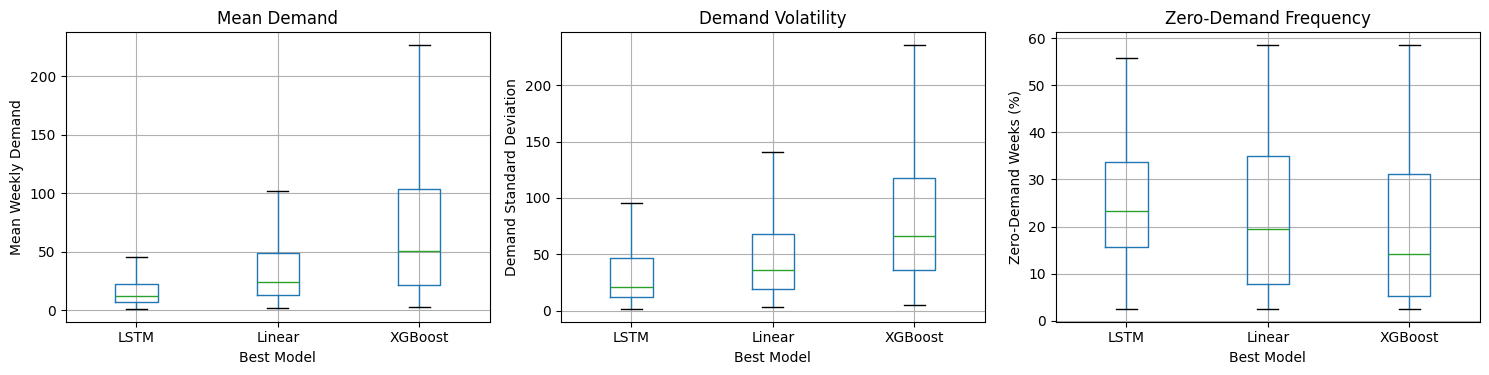

In [296]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

larger_product_analysis.boxplot(
    column="MeanDemand",
    by="BestModel",
    ax=axes[0],
    showfliers=False
)
axes[0].set_title("Mean Demand")
axes[0].set_xlabel("Best Model")
axes[0].set_ylabel("Mean Weekly Demand")

larger_product_analysis.boxplot(
    column="DemandStd",
    by="BestModel",
    ax=axes[1],
    showfliers=False
)
axes[1].set_title("Demand Volatility")
axes[1].set_xlabel("Best Model")
axes[1].set_ylabel("Demand Standard Deviation")

larger_product_analysis.boxplot(
    column="ZeroDemandPct",
    by="BestModel",
    ax=axes[2],
    showfliers=False
)
axes[2].set_title("Zero-Demand Frequency")
axes[2].set_xlabel("Best Model")
axes[2].set_ylabel("Zero-Demand Weeks (%)")

plt.suptitle("")
plt.tight_layout()
plt.show()


## 107. Best Model Across Demand Sparsity Levels

The previous analysis suggests that zero-demand frequency may be related to model suitability.

I divide the products into four groups based on their historical zero-demand frequency and examine which model performs best within each group.


In [297]:
larger_product_analysis["SparsityGroup"] = pd.qcut(
    larger_product_analysis["ZeroDemandPct"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"],
    duplicates="drop"
)

sparsity_winner_table = (
    pd.crosstab(
        larger_product_analysis["SparsityGroup"],
        larger_product_analysis["BestModel"],
        normalize="index"
    )
    * 100
)

display(sparsity_winner_table.round(2))


BestModel,LSTM,Linear,XGBoost
SparsityGroup,,,
Low,14.29,60.38,25.34
Medium-Low,32.39,50.94,16.67
Medium-High,41.46,46.34,12.20
High,26.81,57.73,15.46


## 108. Best Model Across Demand Levels

The previous results also suggest that model suitability may differ according to product demand level.

I divide products into four groups based on their historical mean demand and compare the best-performing model within each group.


In [298]:
larger_product_analysis["DemandLevelGroup"] = pd.qcut(
    larger_product_analysis["MeanDemand"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

demand_level_winner_table = (
    pd.crosstab(
        larger_product_analysis["DemandLevelGroup"],
        larger_product_analysis["BestModel"],
        normalize="index"
    )
    * 100
)

display(demand_level_winner_table.round(2))


BestModel,LSTM,Linear,XGBoost
DemandLevelGroup,,,
Low,51.50,41.32,7.19
Medium-Low,30.93,57.96,11.11
Medium-High,18.62,64.86,16.52
High,11.98,52.10,35.93


## 109. Best Model Across Demand Volatility Levels

I also examine whether model suitability changes with product demand volatility.

Products are divided into four groups according to their historical demand standard deviation, and the best-performing model is compared within each group.


In [299]:
larger_product_analysis["VolatilityGroup"] = pd.qcut(
    larger_product_analysis["DemandStd"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

volatility_winner_table = (
    pd.crosstab(
        larger_product_analysis["VolatilityGroup"],
        larger_product_analysis["BestModel"],
        normalize="index"
    )
    * 100
)

display(volatility_winner_table.round(2))


BestModel,LSTM,Linear,XGBoost
VolatilityGroup,,,
Low,46.71,47.01,6.29
Medium-Low,28.23,60.36,11.41
Medium-High,22.52,57.96,19.52
High,15.57,50.90,33.53


## 110. Normalized Forecasting Error Across Demand Levels

The previous analysis shows how often each model performs best, but it does not show the size of the forecasting errors.

I therefore compare the median normalized RMSE across the four demand-level groups.

This provides a scale-adjusted comparison of model performance for different types of products.


In [300]:
demand_level_nrmse = (
    larger_product_analysis
    .groupby("DemandLevelGroup", observed=True)
    .agg(
        LinearNRMSE=("LinearNRMSE", "median"),
        XGBoostNRMSE=("XGBoostNRMSE", "median"),
        LSTMNRMSE=("LSTMNRMSE", "median")
    )
)

display(demand_level_nrmse.round(2))


,LinearNRMSE,XGBoostNRMSE,LSTMNRMSE
DemandLevelGroup,,,
Low,1.01,1.89,0.91
Medium-Low,0.66,0.99,0.82
Medium-High,0.58,0.68,0.77
High,0.53,0.54,0.61


## 111. Normalized Forecasting Error Across Volatility Levels

I also compare normalized RMSE across the four volatility groups.

This shows whether the differences in model suitability remain after adjusting forecasting errors for product demand scale.


In [301]:
volatility_nrmse = (
    larger_product_analysis
    .groupby("VolatilityGroup", observed=True)
    .agg(
        LinearNRMSE=("LinearNRMSE", "median"),
        XGBoostNRMSE=("XGBoostNRMSE", "median"),
        LSTMNRMSE=("LSTMNRMSE", "median")
    )
)

display(volatility_nrmse.round(2))


,LinearNRMSE,XGBoostNRMSE,LSTMNRMSE
VolatilityGroup,,,
Low,0.94,1.76,0.91
Medium-Low,0.70,1.04,0.79
Medium-High,0.58,0.72,0.73
High,0.53,0.55,0.60


## 112. Larger-Sample Product-Level Findings

The larger-sample analysis shows that no single forecasting model is optimal for every product.

Linear Regression is the most consistent overall model and performs best for more than half of the products. LSTM is particularly competitive for low-demand and relatively stable products, while XGBoost becomes more competitive as demand level and volatility increase.

These findings suggest that forecasting model suitability depends partly on product demand characteristics rather than model complexity alone.


## 113. Time-Aware XGBoost Tuning Within the Training Period

I now strengthen XGBoost tuning by using expanding chronological folds created only within the 64-week training period.

Each fold trains on the past and validates on the following eight weeks, so future observations are never used to predict earlier periods.

The main 13-week validation period remains separate from this tuning process.


In [302]:
large_train_weeks = sorted(
    larger_train_data["Week"].unique()
)

fold_settings = [
    (32, 8),
    (40, 8),
    (48, 8),
    (56, 8)
]

xgb_time_folds = []

for train_end, val_length in fold_settings:
    fold_train_weeks = large_train_weeks[:train_end]
    fold_val_weeks = large_train_weeks[
        train_end:train_end + val_length
    ]
    xgb_time_folds.append(
        (fold_train_weeks, fold_val_weeks)
    )

for i, (fold_train_weeks, fold_val_weeks) in enumerate(
    xgb_time_folds,
    start=1
):
    print(f"Fold {i}")
    print(
        "Train:",
        len(fold_train_weeks),
        "weeks |",
        pd.Timestamp(fold_train_weeks[0]).date(),
        "to",
        pd.Timestamp(fold_train_weeks[-1]).date()
    )
    print(
        "Validation:",
        len(fold_val_weeks),
        "weeks |",
        pd.Timestamp(fold_val_weeks[0]).date(),
        "to",
        pd.Timestamp(fold_val_weeks[-1]).date()
    )
    print()


Fold 1
Train: 32 weeks | 2010-03-08 to 2010-10-11
Validation: 8 weeks | 2010-10-18 to 2010-12-06

Fold 2
Train: 40 weeks | 2010-03-08 to 2010-12-06
Validation: 8 weeks | 2010-12-13 to 2011-01-31

Fold 3
Train: 48 weeks | 2010-03-08 to 2011-01-31
Validation: 8 weeks | 2011-02-07 to 2011-03-28

Fold 4
Train: 56 weeks | 2010-03-08 to 2011-03-28
Validation: 8 weeks | 2011-04-04 to 2011-05-23



## 114. XGBoost Hyperparameter Search

I evaluate a compact set of XGBoost configurations across the four chronological folds.

The model with the lowest average fold RMSE is selected as the final XGBoost specification before evaluation on the separate validation period.


In [303]:
from itertools import product

xgb_parameter_grid = {
    "n_estimators": [200, 400],
    "learning_rate": [0.01, 0.03],
    "max_depth": [2, 4, 6],
    "subsample": [0.8, 1.0]
}

xgb_tuning_results = []

parameter_combinations = list(product(
    xgb_parameter_grid["n_estimators"],
    xgb_parameter_grid["learning_rate"],
    xgb_parameter_grid["max_depth"],
    xgb_parameter_grid["subsample"]
))

print("Parameter combinations:", len(parameter_combinations))
print(
    "Total model fits:",
    len(parameter_combinations) * len(xgb_time_folds)
)

for n_estimators, learning_rate, max_depth, subsample in parameter_combinations:
    fold_rmses = []

    for fold_train_weeks, fold_val_weeks in xgb_time_folds:
        fold_train = larger_train_data[
            larger_train_data["Week"].isin(fold_train_weeks)
        ]
        fold_validation = larger_train_data[
            larger_train_data["Week"].isin(fold_val_weeks)
        ]

        X_fold_train = fold_train[larger_feature_columns]
        y_fold_train = fold_train["WeeklyDemand"]

        X_fold_validation = fold_validation[larger_feature_columns]
        y_fold_validation = fold_validation["WeeklyDemand"]

        model = XGBRegressor(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            subsample=subsample,
            colsample_bytree=1.0,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_fold_train, y_fold_train)
        predictions = model.predict(X_fold_validation)

        rmse = np.sqrt(mean_squared_error(
            y_fold_validation,
            predictions
        ))
        fold_rmses.append(rmse)

    xgb_tuning_results.append({
        "n_estimators": n_estimators,
        "learning_rate": learning_rate,
        "max_depth": max_depth,
        "subsample": subsample,
        "MeanRMSE": np.mean(fold_rmses),
        "StdRMSE": np.std(fold_rmses)
    })

xgb_tuning_results = (
    pd.DataFrame(xgb_tuning_results)
    .sort_values("MeanRMSE")
    .reset_index(drop=True)
)

display(xgb_tuning_results.head(10).round(2))


Parameter combinations: 24
Total model fits: 96


,n_estimators,learning_rate,max_depth,subsample,MeanRMSE,StdRMSE
0,200,0.01,2,0.80,127.02,49.03
1,200,0.01,2,1.00,127.03,49.66
2,400,0.01,2,0.80,128.79,45.46
3,400,0.01,2,1.00,129.05,46.35
4,200,0.03,2,1.00,130.01,45.31
5,200,0.03,2,0.80,130.23,44.99
6,200,0.01,4,1.00,130.23,46.13
7,200,0.01,4,0.80,130.44,46.26
8,400,0.03,2,0.80,132.32,46.05
9,400,0.03,2,1.00,132.70,45.77


## 115. Final Tuned XGBoost on the Larger Sample

I train the selected XGBoost specification using the full 64-week training period.

I then evaluate it on the separate 13-week validation period, which was not used during the hyperparameter search.


In [304]:
final_larger_xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.01,
    max_depth=2,
    subsample=0.8,
    colsample_bytree=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

final_larger_xgb_model.fit(
    X_train_large,
    y_train_large
)

final_larger_xgb_predictions = final_larger_xgb_model.predict(
    X_validation_large
)

final_larger_xgb_metrics = forecasting_metrics(
    y_validation_large,
    final_larger_xgb_predictions
)

print("Previous Larger-Sample XGBoost:")
print(larger_xgb_metrics)

print("\nFinal Tuned Larger-Sample XGBoost:")
print(final_larger_xgb_metrics)

# Lock the final XGBoost specification
larger_xgb_model = final_larger_xgb_model
larger_xgb_predictions = final_larger_xgb_predictions
larger_xgb_metrics = final_larger_xgb_metrics


Previous Larger-Sample XGBoost:
{'MAE': 29.657175595531303, 'RMSE': np.float64(76.62763056636588), 'sMAPE': np.float64(108.66176594403818)}

Final Tuned Larger-Sample XGBoost:
{'MAE': 31.256438438104052, 'RMSE': np.float64(77.31837604754624), 'sMAPE': np.float64(111.45170606999812)}


## 116. Final Larger-Sample Validation Comparison

After completing the preprocessing and time-aware tuning checks, I compare the final specifications of the larger-sample models.

These are the model versions that will be carried forward before the final test evaluation.


In [305]:
final_larger_results = pd.DataFrame([
    {"Model": "Naive", **larger_naive_metrics},
    {"Model": "Seasonal Naive", **larger_seasonal_naive_metrics},
    {"Model": "Linear Regression", **larger_linear_metrics},
    {"Model": "XGBoost", **larger_xgb_metrics},
    {"Model": "LSTM", **final_larger_lstm_metrics}
])

final_larger_results = (
    final_larger_results
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(final_larger_results.round(2))


,Model,MAE,RMSE,sMAPE
0,Linear Regression,25.93,76.55,101.07
1,XGBoost,31.26,77.32,111.45
2,LSTM,26.55,81.01,121.16
3,Naive,32.88,109.45,98.37
4,Seasonal Naive,43.33,121.13,121.26


## 117. Updating Product-Level Results With the Final XGBoost Model

I update the product-level comparison using the final time-aware tuned XGBoost predictions.

This ensures that all subsequent product-level findings are based on the final model specifications.


In [306]:
large_product_predictions = larger_validation_data[
    ["StockCode", "Week", "WeeklyDemand"]
].copy()

large_product_predictions["LinearPrediction"] = (
    larger_linear_predictions
)
large_product_predictions["XGBoostPrediction"] = (
    final_larger_xgb_predictions
)

final_lstm_predictions_df = lstm_validation_info_large.copy()
final_lstm_predictions_df["LSTMPrediction"] = (
    final_larger_lstm_predictions
)

large_product_predictions = large_product_predictions.merge(
    final_lstm_predictions_df,
    on=["StockCode", "Week"],
    how="left"
)

print("Rows:", len(large_product_predictions))
print(
    "Duplicate product-week rows:",
    large_product_predictions.duplicated(
        ["StockCode", "Week"]
    ).sum()
)
print(
    "Missing LSTM predictions:",
    large_product_predictions["LSTMPrediction"].isna().sum()
)

display(large_product_predictions.head())


Rows: 17342
Duplicate product-week rows: 0
Missing LSTM predictions: 0


,StockCode,Week,WeeklyDemand,LinearPrediction,XGBoostPrediction,LSTMPrediction
0,10002,2011-05-30,0.00,3.24,19.03,0.00
1,10002,2011-06-06,0.00,10.64,19.03,0.00
2,10002,2011-06-13,0.00,6.43,19.03,0.00
3,10002,2011-06-20,0.00,4.67,19.03,0.00
4,10002,2011-06-27,0.00,2.94,19.03,0.00


## 118. Final Product-Level Model Comparison

I recalculate product-level RMSE using the final model specifications.

This allows me to identify which model performs best for each product after all model development decisions have been completed.


In [307]:
product_error_rows = []

for stock_code, group in large_product_predictions.groupby("StockCode"):
    product_error_rows.append({
        "StockCode": stock_code,
        "LinearRMSE": np.sqrt(mean_squared_error(
            group["WeeklyDemand"],
            group["LinearPrediction"]
        )),
        "XGBoostRMSE": np.sqrt(mean_squared_error(
            group["WeeklyDemand"],
            group["XGBoostPrediction"]
        )),
        "LSTMRMSE": np.sqrt(mean_squared_error(
            group["WeeklyDemand"],
            group["LSTMPrediction"]
        ))
    })

final_product_errors = pd.DataFrame(product_error_rows)

final_product_analysis = (
    larger_product_characteristics
    .merge(final_product_errors, on="StockCode")
)

for model in ["Linear", "XGBoost", "LSTM"]:
    final_product_analysis[f"{model}NRMSE"] = (
        final_product_analysis[f"{model}RMSE"]
        / final_product_analysis["MeanDemand"].clip(lower=1)
    )

rmse_columns = ["LinearRMSE", "XGBoostRMSE", "LSTMRMSE"]

final_product_analysis["BestModel"] = (
    final_product_analysis[rmse_columns]
    .idxmin(axis=1)
    .str.replace("RMSE", "", regex=False)
)

final_product_analysis["BestRMSE"] = (
    final_product_analysis[rmse_columns].min(axis=1)
)

final_best_model_counts = (
    final_product_analysis["BestModel"]
    .value_counts()
    .rename_axis("Model")
    .reset_index(name="Products")
)

final_best_model_counts["Percentage"] = (
    final_best_model_counts["Products"]
    / len(final_product_analysis)
    * 100
)

display(final_best_model_counts.round(2))


,Model,Products,Percentage
0,Linear,721,54.05
1,LSTM,370,27.74
2,XGBoost,243,18.22


## 119. Product Characteristics by Final Best Model

I compare the historical demand characteristics of products according to their final best-performing model.

This helps examine whether different forecasting approaches are better suited to different types of product demand.


In [308]:
final_winner_characteristics = (
    final_product_analysis
    .groupby("BestModel")
    .agg(
        Products=("StockCode", "count"),
        MedianDemand=("MeanDemand", "median"),
        MedianDemandStd=("DemandStd", "median"),
        MedianSkew=("DemandSkew", "median"),
        MedianZeroDemandPct=("ZeroDemandPct", "median"),
        MedianBestRMSE=("BestRMSE", "median")
    )
    .reset_index()
)

display(final_winner_characteristics.round(2))


,BestModel,Products,MedianDemand,MedianDemandStd,MedianSkew,MedianZeroDemandPct,MedianBestRMSE
0,LSTM,370,11.62,20.59,3.34,23.38,4.02
1,Linear,721,23.65,36.52,2.56,19.48,17.15
2,XGBoost,243,45.29,58.87,2.38,15.58,38.34


## 120. Final Best Model Across Demand Levels

I divide the products into four groups based on historical mean demand and compare the final best-performing model within each group.

This tests whether the relationship between demand level and model suitability remains after finalising all model specifications.


In [309]:
final_product_analysis["DemandLevelGroup"] = pd.qcut(
    final_product_analysis["MeanDemand"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

final_demand_level_winners = (
    pd.crosstab(
        final_product_analysis["DemandLevelGroup"],
        final_product_analysis["BestModel"],
        normalize="index"
    )
    * 100
)

display(final_demand_level_winners.round(2))


BestModel,LSTM,Linear,XGBoost
DemandLevelGroup,,,
Low,51.50,40.42,8.08
Medium-Low,30.93,59.16,9.91
Medium-High,17.72,60.36,21.92
High,10.78,56.29,32.93


## 121. Final Best Model Across Volatility Levels

I also compare the final best-performing model across four levels of historical demand volatility.

This checks whether the volatility pattern remains after finalising the XGBoost specification.


In [310]:
final_product_analysis["VolatilityGroup"] = pd.qcut(
    final_product_analysis["DemandStd"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

final_volatility_winners = (
    pd.crosstab(
        final_product_analysis["VolatilityGroup"],
        final_product_analysis["BestModel"],
        normalize="index"
    )
    * 100
)

display(final_volatility_winners.round(2))


BestModel,LSTM,Linear,XGBoost
VolatilityGroup,,,
Low,46.71,46.11,7.19
Medium-Low,27.93,59.16,12.91
Medium-High,21.62,55.56,22.82
High,14.67,55.39,29.94


## 122. Final Relationship Between Demand Characteristics and Forecasting Error

I re-examine the relationship between historical demand characteristics and forecasting error using the final model specifications.

Both raw and normalized RMSE are considered because absolute forecasting error is strongly affected by product demand scale.


In [311]:
characteristic_columns = [
    "MeanDemand",
    "DemandStd",
    "DemandSkew",
    "ZeroDemandPct"
]

error_columns = [
    "LinearRMSE",
    "XGBoostRMSE",
    "LSTMRMSE",
    "LinearNRMSE",
    "XGBoostNRMSE",
    "LSTMNRMSE"
]

final_pearson_correlations = (
    final_product_analysis[
        characteristic_columns + error_columns
    ]
    .corr(method="pearson")
    .loc[characteristic_columns, error_columns]
)

final_spearman_correlations = (
    final_product_analysis[
        characteristic_columns + error_columns
    ]
    .corr(method="spearman")
    .loc[characteristic_columns, error_columns]
)

print("Pearson Correlations:")
display(final_pearson_correlations.round(2))

print("\nSpearman Correlations:")
display(final_spearman_correlations.round(2))


Pearson Correlations:


,LinearRMSE,XGBoostRMSE,LSTMRMSE,LinearNRMSE,XGBoostNRMSE,LSTMNRMSE
MeanDemand,0.72,0.71,0.73,-0.13,-0.25,-0.12
DemandStd,0.55,0.54,0.55,-0.11,-0.21,-0.10
DemandSkew,-0.09,-0.07,-0.10,0.02,0.08,0.01
ZeroDemandPct,-0.19,-0.19,-0.20,0.24,0.34,0.24



Spearman Correlations:


,LinearRMSE,XGBoostRMSE,LSTMRMSE,LinearNRMSE,XGBoostNRMSE,LSTMNRMSE
MeanDemand,0.71,0.58,0.70,-0.39,-0.76,-0.17
DemandStd,0.65,0.57,0.62,-0.35,-0.66,-0.19
DemandSkew,-0.19,-0.09,-0.21,0.03,0.18,-0.06
ZeroDemandPct,-0.27,-0.21,-0.27,0.36,0.47,0.25


## 123. Actual Forecasting Features and Forecasting Error

Price is not used as an input feature in the forecasting models. The actual feature set consists of lagged demand, rolling demand statistics, and calendar variables.

To address the feature-level feedback directly, I summarise representative numerical forecasting features for each product using only the training period and compare them with the final product-level RMSE and normalized RMSE.

I focus on `lag_1`, `rolling_mean_13`, and `rolling_std_13` because they represent recent demand, medium-term demand level, and recent volatility. Calendar variables are not included in this product-level comparison because their distribution is the same across products over the shared time period.


In [312]:
representative_actual_features = [
    "lag_1",
    "rolling_mean_13",
    "rolling_std_13"
]

training_feature_characteristics = (
    larger_train_data
    .groupby("StockCode")[representative_actual_features]
    .median()
    .rename(columns={
        "lag_1": "MedianLag1",
        "rolling_mean_13": "MedianRollingMean13",
        "rolling_std_13": "MedianRollingStd13"
    })
    .reset_index()
)

final_feature_error_analysis = (
    final_product_analysis
    .merge(
        training_feature_characteristics,
        on="StockCode",
        how="left"
    )
)

feature_characteristic_columns = [
    "MedianLag1",
    "MedianRollingMean13",
    "MedianRollingStd13"
]

final_feature_pearson = (
    final_feature_error_analysis[
        feature_characteristic_columns + error_columns
    ]
    .corr(method="pearson")
    .loc[feature_characteristic_columns, error_columns]
)

final_feature_spearman = (
    final_feature_error_analysis[
        feature_characteristic_columns + error_columns
    ]
    .corr(method="spearman")
    .loc[feature_characteristic_columns, error_columns]
)

print("Representative feature summary:")
display(
    final_feature_error_analysis[
        ["StockCode"] + feature_characteristic_columns
    ].head()
)

print("\nPearson correlations with forecasting error:")
display(final_feature_pearson.round(2))

print("\nSpearman correlations with forecasting error:")
display(final_feature_spearman.round(2))


Representative feature summary:


,StockCode,MedianLag1,MedianRollingMean13,MedianRollingStd13
0,10002,31.00,105.04,139.56
1,10125,4.50,13.00,17.12
2,10133,10.00,14.38,17.68
3,10135,15.50,32.04,40.27
4,11001,16.00,36.50,44.92



Pearson correlations with forecasting error:


,LinearRMSE,XGBoostRMSE,LSTMRMSE,LinearNRMSE,XGBoostNRMSE,LSTMNRMSE
MedianLag1,0.64,0.63,0.66,-0.12,-0.23,-0.12
MedianRollingMean13,0.68,0.67,0.70,-0.13,-0.24,-0.12
MedianRollingStd13,0.70,0.69,0.70,-0.11,-0.24,-0.11



Spearman correlations with forecasting error:


,LinearRMSE,XGBoostRMSE,LSTMRMSE,LinearNRMSE,XGBoostNRMSE,LSTMNRMSE
MedianLag1,0.62,0.48,0.62,-0.35,-0.68,-0.15
MedianRollingMean13,0.68,0.54,0.67,-0.35,-0.71,-0.14
MedianRollingStd13,0.70,0.57,0.68,-0.32,-0.68,-0.12


# 10. Final Locked Model Evaluation and Research Findings

In the final stage, I complete the remaining model development steps before opening the untouched test period.

I first add the larger-sample demand visualisations requested in the previous meeting. I then complete the classical forecasting comparison, lock all final model specifications, and evaluate them once on the final test period.

## 125. Larger-Sample Weekly Demand Over Time

I first visualise weekly demand across the larger product sample.

The demand is aggregated across all 1,334 eligible products to show the overall demand pattern over time.

At this stage, I only display observations before the final test period so that the test data remains untouched.

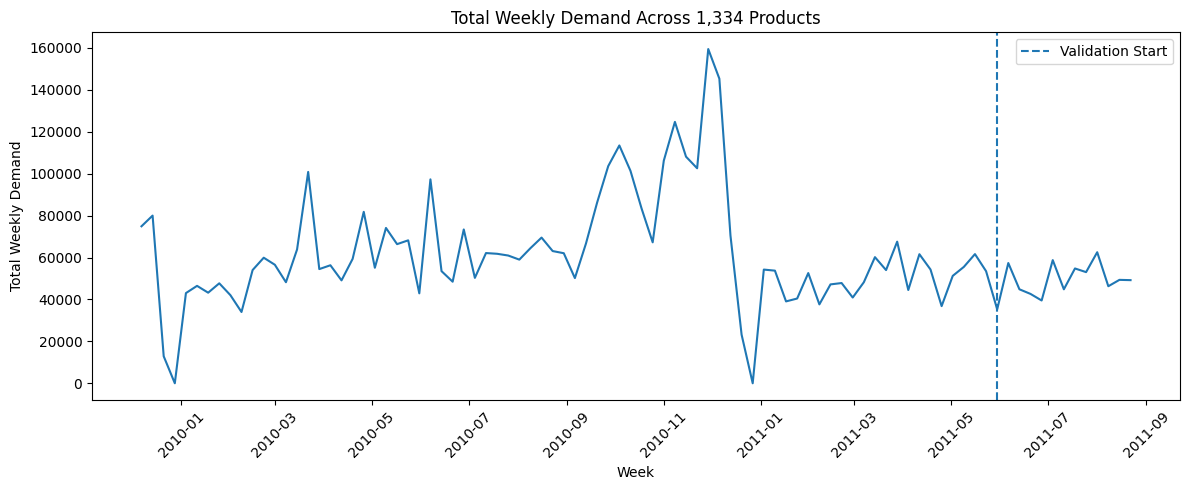

Weeks shown: 90
Period: 2009-12-07 00:00:00 to 2011-08-22 00:00:00


In [313]:
# Aggregate weekly demand across all eligible products
larger_weekly_total = (
    larger_weekly_demand
    .groupby("Week", as_index=False)["WeeklyDemand"]
    .sum()
)

# Keep the final test period hidden for now
development_weekly_total = larger_weekly_total[
    larger_weekly_total["Week"] < test_weeks[0]
].copy()

plt.figure(figsize=(12, 5))

plt.plot(
    development_weekly_total["Week"],
    development_weekly_total["WeeklyDemand"]
)

plt.title("Total Weekly Demand Across 1,334 Products")
plt.xlabel("Week")
plt.ylabel("Total Weekly Demand")

# Mark start of validation period
plt.axvline(
    validation_weeks[0],
    linestyle="--",
    label="Validation Start"
)

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Weeks shown:", development_weekly_total["Week"].nunique())
print(
    "Period:",
    development_weekly_total["Week"].min(),
    "to",
    development_weekly_total["Week"].max()
)

### Result

The larger sample shows substantial variation in total weekly demand, including several pronounced peaks and low-demand periods.

The figure shows the 90 weeks available before the final test period and marks the beginning of validation. The final 14-week test period remains untouched at this stage.

## 126. Mean Forecasting Features and RMSE

To address the previous feedback more directly, I calculate the mean value of representative forecasting features for each product using only the training period.

I then compare these product-level feature means with the validation RMSE of Linear Regression, XGBoost, and LSTM across the 1,334-product sample.

In [314]:
mean_feature_characteristics = (
    larger_train_data
    .groupby("StockCode")[
        ["lag_1", "rolling_mean_13", "rolling_std_13"]
    ]
    .mean()
    .rename(columns={
        "lag_1": "MeanLag1",
        "rolling_mean_13": "MeanRollingMean13",
        "rolling_std_13": "MeanRollingStd13"
    })
    .reset_index()
)

mean_feature_rmse_analysis = (
    final_product_analysis
    .merge(
        mean_feature_characteristics,
        on="StockCode",
        how="left"
    )
)

mean_features = [
    "MeanLag1",
    "MeanRollingMean13",
    "MeanRollingStd13"
]

rmse_columns = [
    "LinearRMSE",
    "XGBoostRMSE",
    "LSTMRMSE"
]

mean_feature_correlations = (
    mean_feature_rmse_analysis[
        mean_features + rmse_columns
    ]
    .corr(method="pearson")
    .loc[mean_features, rmse_columns]
)

print("Mean feature correlations with RMSE:")
display(mean_feature_correlations.round(3))

Mean feature correlations with RMSE:


,LinearRMSE,XGBoostRMSE,LSTMRMSE
MeanLag1,0.72,0.71,0.73
MeanRollingMean13,0.71,0.70,0.72
MeanRollingStd13,0.62,0.61,0.61


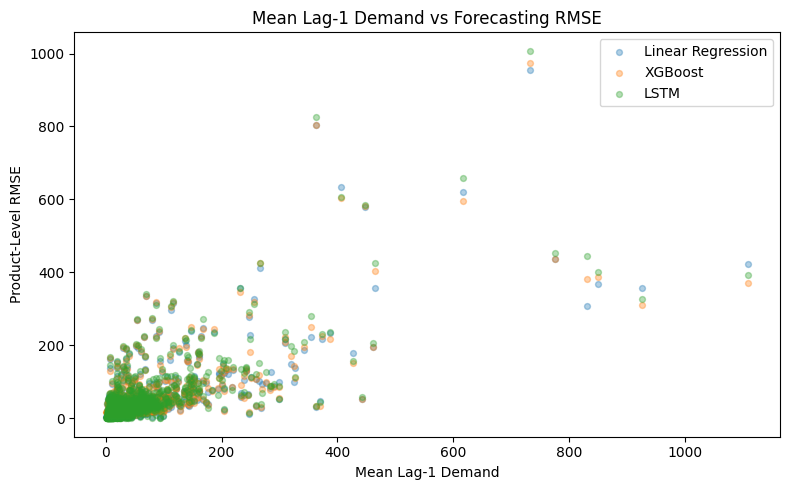

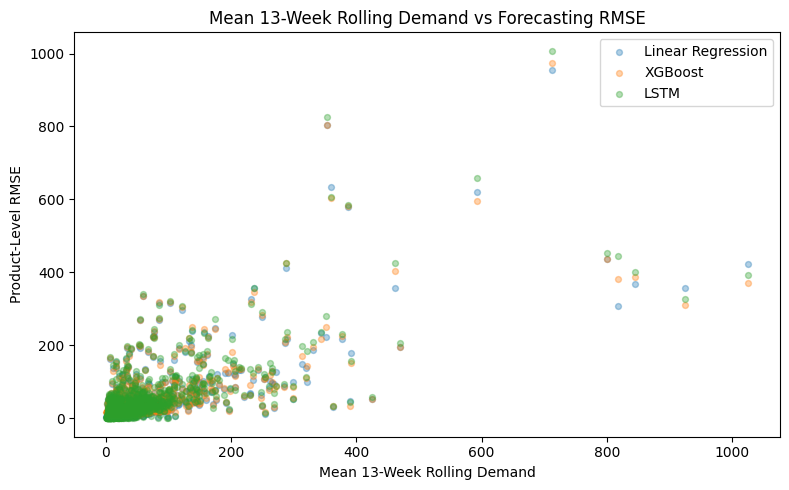

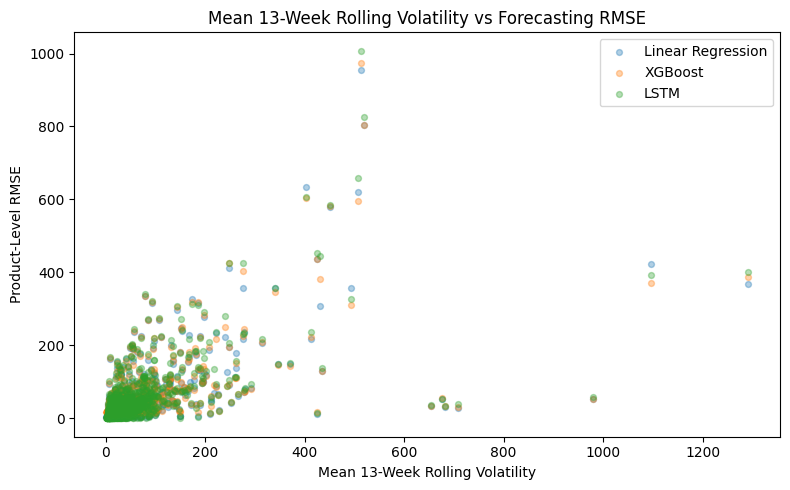

In [315]:
feature_labels = {
    "MeanLag1": "Mean Lag-1 Demand",
    "MeanRollingMean13": "Mean 13-Week Rolling Demand",
    "MeanRollingStd13": "Mean 13-Week Rolling Volatility"
}

model_labels = {
    "LinearRMSE": "Linear Regression",
    "XGBoostRMSE": "XGBoost",
    "LSTMRMSE": "LSTM"
}

for feature in mean_features:

    plt.figure(figsize=(8, 5))

    for rmse in rmse_columns:
        plt.scatter(
            mean_feature_rmse_analysis[feature],
            mean_feature_rmse_analysis[rmse],
            alpha=0.35,
            s=18,
            label=model_labels[rmse]
        )

    plt.xlabel(feature_labels[feature])
    plt.ylabel("Product-Level RMSE")
    plt.title(f"{feature_labels[feature]} vs Forecasting RMSE")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Result

The mean forecasting features show strong positive relationships with product-level RMSE across all three models.

Mean lag-1 demand and mean 13-week rolling demand have correlations of approximately 0.70–0.73 with RMSE, while mean rolling volatility has a slightly weaker relationship of around 0.61–0.62.

The scatter plots also show that products with larger demand and volatility values generally produce larger absolute forecasting errors. This suggests that much of the increase in raw RMSE is related to product scale.

## 127. Preparing Larger-Sample ARIMA Evaluation

I now extend the classical ARIMA forecasting approach from the five-product pilot to the full sample of 1,334 products.

ARIMA is fitted separately for each product because each product has its own demand time series. Model specification will be selected using only training-period information, while the existing validation and final test periods remain unchanged.

Unlike the feature-based models, ARIMA can also use the first 13 weeks of historical demand that were lost during lag-feature construction.

In [316]:
from statsmodels.tsa.arima.model import ARIMA
import warnings

# ARIMA can use all historical weeks before validation
arima_train_data = larger_weekly_demand[
    larger_weekly_demand["Week"] < validation_weeks[0]
].copy()

# Same 13-week validation period used by the other models
arima_validation_data = larger_weekly_demand[
    larger_weekly_demand["Week"].isin(validation_weeks)
].copy()

arima_train_weeks = sorted(arima_train_data["Week"].unique())
arima_validation_weeks = sorted(
    arima_validation_data["Week"].unique()
)

print("ARIMA Training:")
print("Products:", arima_train_data["StockCode"].nunique())
print("Weeks:", len(arima_train_weeks))
print(
    "Period:",
    arima_train_data["Week"].min(),
    "to",
    arima_train_data["Week"].max()
)

print("\nARIMA Validation:")
print("Products:", arima_validation_data["StockCode"].nunique())
print("Weeks:", len(arima_validation_weeks))
print(
    "Period:",
    arima_validation_data["Week"].min(),
    "to",
    arima_validation_data["Week"].max()
)

print(
    "\nFinal test observations accessed:",
    (
        arima_train_data["Week"].isin(test_weeks).any()
        or
        arima_validation_data["Week"].isin(test_weeks).any()
    )
)

ARIMA Training:
Products: 1334
Weeks: 77
Period: 2009-12-07 00:00:00 to 2011-05-23 00:00:00

ARIMA Validation:
Products: 1334
Weeks: 13
Period: 2011-05-30 00:00:00 to 2011-08-22 00:00:00

Final test observations accessed: False


### Result

ARIMA has 77 complete training weeks for each of the 1,334 products, followed by the same 13-week validation period used for the other models.

Because ARIMA works directly with the demand series, it can use 13 additional historical weeks that were unavailable to the lag-based models.

No observations from the final test period have been accessed.

## 128. Training-Only ARIMA Order Selection

For the larger sample, ARIMA order selection is performed using only the training period.

For each product, I evaluate a compact set of non-seasonal ARIMA specifications and select the order with the lowest Akaike Information Criterion (AIC).

AIC measures model fit while penalising unnecessary complexity. The validation and final test periods are therefore not used during ARIMA specification selection.

In [317]:
import itertools
import numpy as np
import pandas as pd
import warnings
from statsmodels.tsa.arima.model import ARIMA

# Same compact ARIMA search space used in the pilot
p_values = [0, 1, 2]
d_values = [0, 1]
q_values = [0, 1, 2]

arima_orders = list(
    itertools.product(p_values, d_values, q_values)
)

print("Candidate ARIMA orders:", len(arima_orders))
print(arima_orders)

Candidate ARIMA orders: 18
[(0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 1, 0), (0, 1, 1), (0, 1, 2), (1, 0, 0), (1, 0, 1), (1, 0, 2), (1, 1, 0), (1, 1, 1), (1, 1, 2), (2, 0, 0), (2, 0, 1), (2, 0, 2), (2, 1, 0), (2, 1, 1), (2, 1, 2)]


### Selecting the ARIMA Order for Each Product

I select a separate ARIMA specification for each product because demand dynamics may differ across products.

All candidate orders are fitted only to the 77-week training history. The order with the lowest AIC is retained for each product, and failed model fits are skipped.

In [318]:
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import time

warnings.simplefilter("ignore", ConvergenceWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

arima_order_results = []

product_codes = sorted(
    arima_train_data["StockCode"].astype(str).unique()
)

start_time = time.time()

for i, stock_code in enumerate(product_codes, start=1):

    product_train = (
        arima_train_data[
            arima_train_data["StockCode"].astype(str) == stock_code
        ]
        .sort_values("Week")
    )

    y_train_arima = (
        product_train["WeeklyDemand"]
        .astype(float)
        .to_numpy()
    )

    best_aic = np.inf
    best_order = None
    successful_fits = 0

    for order in arima_orders:

        try:
            fitted_model = ARIMA(
                y_train_arima,
                order=order
            ).fit()

            if np.isfinite(fitted_model.aic):

                successful_fits += 1

                if fitted_model.aic < best_aic:
                    best_aic = fitted_model.aic
                    best_order = order

        except Exception:
            continue

    arima_order_results.append({
        "StockCode": stock_code,
        "BestOrder": best_order,
        "BestAIC": best_aic if best_order is not None else np.nan,
        "SuccessfulFits": successful_fits
    })

    if i % 100 == 0:
        print(f"Completed {i}/{len(product_codes)} products")

arima_order_selection = pd.DataFrame(arima_order_results)

elapsed_minutes = (time.time() - start_time) / 60

print("\nProducts evaluated:", len(arima_order_selection))
print(
    "Products with valid ARIMA order:",
    arima_order_selection["BestOrder"].notna().sum()
)
print(
    "Products without valid ARIMA order:",
    arima_order_selection["BestOrder"].isna().sum()
)
print(f"Runtime: {elapsed_minutes:.2f} minutes")

print("\nMost frequently selected ARIMA orders:")
display(
    arima_order_selection["BestOrder"]
    .value_counts()
    .head(10)
)

display(arima_order_selection.head())

Completed 100/1334 products
Completed 200/1334 products
Completed 300/1334 products
Completed 400/1334 products
Completed 500/1334 products
Completed 600/1334 products
Completed 700/1334 products
Completed 800/1334 products
Completed 900/1334 products
Completed 1000/1334 products
Completed 1100/1334 products
Completed 1200/1334 products
Completed 1300/1334 products

Products evaluated: 1334
Products with valid ARIMA order: 1334
Products without valid ARIMA order: 0
Runtime: 42.13 minutes

Most frequently selected ARIMA orders:


,count
BestOrder,
"(0, 1, 1)",718
"(1, 1, 1)",138
"(0, 1, 2)",124
"(2, 1, 1)",100
"(2, 1, 2)",85
"(1, 1, 2)",77
"(2, 1, 0)",35
"(2, 0, 2)",20
"(1, 1, 0)",12


,StockCode,BestOrder,BestAIC,SuccessfulFits
0,10002,"(0, 1, 1)","1,002.64",18
1,10125,"(0, 1, 2)",675.33,18
2,10133,"(0, 1, 1)",682.09,18
3,10135,"(0, 1, 1)",920.30,18
4,11001,"(0, 1, 1)",913.10,18


### Result

A valid ARIMA specification was identified for all 1,334 products using training data only.

The most frequently selected specification was ARIMA(0,1,1), selected for 718 products, or approximately 53.8% of the larger sample. However, several alternative specifications were also selected, supporting the use of product-specific ARIMA orders rather than a single specification for every product.

No validation or test observations were used during order selection.

## 129. Rolling One-Step-Ahead ARIMA Validation

Using the training-only ARIMA specification selected for each product, I evaluate ARIMA over the same 13-week validation period used for the other models.

The evaluation follows a rolling one-step-ahead setting. Each next week is forecast before its actual demand is added to the model history.

The ARIMA parameters remain fixed during validation, so the validation period is used only for evaluation rather than model selection.

In [319]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import warnings
import time

arima_validation_predictions = []

start_time = time.time()
failed_products = []

order_map = dict(
    zip(
        arima_order_selection["StockCode"].astype(str),
        arima_order_selection["BestOrder"]
    )
)

for i, stock_code in enumerate(product_codes, start=1):

    product_train = (
        arima_train_data[
            arima_train_data["StockCode"].astype(str) == stock_code
        ]
        .sort_values("Week")
    )

    product_validation = (
        arima_validation_data[
            arima_validation_data["StockCode"].astype(str) == stock_code
        ]
        .sort_values("Week")
    )

    y_train = (
        product_train["WeeklyDemand"]
        .astype(float)
        .to_numpy()
    )

    order = order_map[stock_code]

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            fitted_model = ARIMA(
                y_train,
                order=order
            ).fit()

            current_model = fitted_model

            for _, row in product_validation.iterrows():

                forecast = float(
                    current_model.forecast(steps=1)[0]
                )

                # Demand cannot be negative
                forecast = max(forecast, 0)

                actual = float(row["WeeklyDemand"])

                arima_validation_predictions.append({
                    "StockCode": stock_code,
                    "Week": row["Week"],
                    "WeeklyDemand": actual,
                    "ARIMAPrediction": forecast,
                    "ARIMAOrder": order
                })

                # Add the newly observed real demand without refitting parameters
                current_model = current_model.append(
                    [actual],
                    refit=False
                )

    except Exception as e:
        failed_products.append((stock_code, str(e)))

    if i % 100 == 0:
        print(f"Completed {i}/{len(product_codes)} products")

arima_validation_predictions = pd.DataFrame(
    arima_validation_predictions
)

elapsed_minutes = (time.time() - start_time) / 60

print("\nPrediction rows:", len(arima_validation_predictions))
print(
    "Products predicted:",
    arima_validation_predictions["StockCode"].nunique()
)
print("Failed products:", len(failed_products))
print(f"Runtime: {elapsed_minutes:.2f} minutes")

display(arima_validation_predictions.head())

Completed 100/1334 products
Completed 200/1334 products
Completed 300/1334 products
Completed 400/1334 products
Completed 500/1334 products
Completed 600/1334 products
Completed 700/1334 products
Completed 800/1334 products
Completed 900/1334 products
Completed 1000/1334 products
Completed 1100/1334 products
Completed 1200/1334 products
Completed 1300/1334 products

Prediction rows: 17342
Products predicted: 1334
Failed products: 0
Runtime: 4.99 minutes


,StockCode,Week,WeeklyDemand,ARIMAPrediction,ARIMAOrder
0,10002,2011-05-30,0.00,29.67,"(0, 1, 1)"
1,10002,2011-06-06,0.00,27.55,"(0, 1, 1)"
2,10002,2011-06-13,0.00,25.59,"(0, 1, 1)"
3,10002,2011-06-20,0.00,23.77,"(0, 1, 1)"
4,10002,2011-06-27,0.00,22.07,"(0, 1, 1)"


### Result

ARIMA successfully generated rolling one-step-ahead forecasts for all 1,334 products across the 13-week validation period.

This produced 17,342 validation predictions with no failed product-level models.

The selected ARIMA parameters remained fixed during validation, while each newly observed weekly demand value was appended to the model history before forecasting the next week.

## 130. Larger-Sample ARIMA Validation Performance

I now evaluate the larger-sample ARIMA forecasts using the same MAE, RMSE, and sMAPE metrics used for the other forecasting approaches.

This allows ARIMA to be compared directly with Linear Regression, XGBoost, LSTM, and the baseline models on the same 13-week validation period.

In [320]:
arima_actual = arima_validation_predictions["WeeklyDemand"].to_numpy()
arima_pred = arima_validation_predictions["ARIMAPrediction"].to_numpy()

arima_validation_metrics = forecasting_metrics(
    arima_actual,
    arima_pred
)

print("ARIMA Validation Metrics:")
print(arima_validation_metrics)

final_validation_comparison_with_arima = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "XGBoost",
        "LSTM",
        "ARIMA",
        "Naive",
        "Seasonal Naive"
    ],
    "MAE": [
        larger_linear_metrics["MAE"],
        larger_xgb_metrics["MAE"],
        final_larger_lstm_metrics["MAE"],
        arima_validation_metrics["MAE"],
        larger_naive_metrics["MAE"],
        larger_seasonal_naive_metrics["MAE"]
    ],
    "RMSE": [
        larger_linear_metrics["RMSE"],
        larger_xgb_metrics["RMSE"],
        final_larger_lstm_metrics["RMSE"],
        arima_validation_metrics["RMSE"],
        larger_naive_metrics["RMSE"],
        larger_seasonal_naive_metrics["RMSE"]
    ],
    "sMAPE": [
        larger_linear_metrics["sMAPE"],
        larger_xgb_metrics["sMAPE"],
        final_larger_lstm_metrics["sMAPE"],
        arima_validation_metrics["sMAPE"],
        larger_naive_metrics["sMAPE"],
        larger_seasonal_naive_metrics["sMAPE"]
    ]
})

final_validation_comparison_with_arima = (
    final_validation_comparison_with_arima
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(
    final_validation_comparison_with_arima.round(2)
)

ARIMA Validation Metrics:
{'MAE': 30.663917846856457, 'RMSE': np.float64(87.66724505482823), 'sMAPE': np.float64(104.80987598917008)}


,Model,MAE,RMSE,sMAPE
0,Linear Regression,25.93,76.55,101.07
1,XGBoost,31.26,77.32,111.45
2,LSTM,26.55,81.01,121.16
3,ARIMA,30.66,87.67,104.81
4,Naive,32.88,109.45,98.37
5,Seasonal Naive,43.33,121.13,121.26


### Result

The larger-sample ARIMA model achieves an RMSE of 87.67 on the validation period.

ARIMA performs substantially better than both naive baselines, confirming that the classical time-series model captures useful temporal structure. However, it does not outperform Linear Regression, XGBoost, or LSTM on the primary RMSE metric.

Linear Regression remains the strongest validation model with an RMSE of 76.55.

## 131. Locking the Final Model Specifications

All model development and validation comparisons are now complete.

Before accessing the final test results, I lock the specification of each forecasting approach. No model will be selected or modified based on final test performance.

The final specifications are:

- **Linear Regression:** the original feature-based specification without product identity.
- **XGBoost:** 200 estimators, learning rate 0.01, maximum depth 2, subsample 0.8, and colsample 1.0.
- **LSTM:** 13-week raw-demand sequences with global MinMax scaling, 32 LSTM units, 0.2 dropout, and the preprocessing strategy selected using validation RMSE.
- **ARIMA:** product-specific non-seasonal `(p,d,q)` orders selected using training-only AIC.
- **Naive and Seasonal Naive:** retained as simple forecasting baselines.

RMSE remains the primary evaluation metric, with MAE and sMAPE reported as complementary measures.

## 132. Preparing the Final Test Evaluation

All model specifications have now been locked, so I can proceed to the untouched final test period.

I combine the original training and validation periods to form the final development dataset. The locked models will be fitted on this information and then used to predict the 14-week test period.

The test results will only be used for final evaluation and will not influence model selection or tuning.

In [321]:
# Combine training and validation for final model fitting
larger_development_data = pd.concat(
    [larger_train_data, larger_validation_data],
    ignore_index=True
).sort_values(["StockCode", "Week"])

X_development_large = larger_development_data[
    larger_feature_columns
]

y_development_large = larger_development_data[
    "WeeklyDemand"
]

X_test_large = larger_test_data[
    larger_feature_columns
]

y_test_large = larger_test_data[
    "WeeklyDemand"
]

print("Final Development Set:")
print("Products:", larger_development_data["StockCode"].nunique())
print("Weeks:", larger_development_data["Week"].nunique())
print("Rows:", len(larger_development_data))
print(
    "Period:",
    larger_development_data["Week"].min(),
    "to",
    larger_development_data["Week"].max()
)

print("\nFinal Test Set:")
print("Products:", larger_test_data["StockCode"].nunique())
print("Weeks:", larger_test_data["Week"].nunique())
print("Rows:", len(larger_test_data))
print(
    "Period:",
    larger_test_data["Week"].min(),
    "to",
    larger_test_data["Week"].max()
)

print(
    "\nOverlap between development and test:",
    bool(
        set(larger_development_data["Week"])
        & set(larger_test_data["Week"])
    )
)

Final Development Set:
Products: 1334
Weeks: 77
Rows: 102718
Period: 2010-03-08 00:00:00 to 2011-08-22 00:00:00

Final Test Set:
Products: 1334
Weeks: 14
Rows: 18676
Period: 2011-08-29 00:00:00 to 2011-11-28 00:00:00

Overlap between development and test: False


### Result

The final development dataset contains 77 weeks and 102,718 observations, while the untouched test set contains 14 weeks and 18,676 observations across all 1,334 products.

There is no overlap between the development and test periods.

The final evaluation follows a rolling one-step-ahead setting: when forecasting each test week, demand observed in earlier weeks may be used as historical information for the next weekly forecast.

## 133. Final Test Predictions: Linear Regression and XGBoost

I refit the locked Linear Regression and XGBoost specifications using the combined training and validation data.

I then use each fitted model to predict weekly product demand in the untouched 14-week test period.

No hyperparameters or model specifications are changed after observing the test predictions.

In [322]:
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

# -----------------------------
# Final Linear Regression
# -----------------------------

final_test_linear_model = LinearRegression()

final_test_linear_model.fit(
    X_development_large,
    y_development_large
)

final_test_linear_predictions = (
    final_test_linear_model.predict(X_test_large)
)

# -----------------------------
# Final XGBoost
# -----------------------------

final_test_xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.01,
    max_depth=2,
    subsample=0.8,
    colsample_bytree=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

final_test_xgb_model.fit(
    X_development_large,
    y_development_large
)

final_test_xgb_predictions = (
    final_test_xgb_model.predict(X_test_large)
)

print("Test observations:", len(y_test_large))

print(
    "Linear predictions:",
    len(final_test_linear_predictions)
)

print(
    "XGBoost predictions:",
    len(final_test_xgb_predictions)
)

print(
    "\nLinear negative predictions:",
    (final_test_linear_predictions < 0).sum()
)

print(
    "XGBoost negative predictions:",
    (final_test_xgb_predictions < 0).sum()
)

Test observations: 18676
Linear predictions: 18676
XGBoost predictions: 18676

Linear negative predictions: 175
XGBoost negative predictions: 0


### Result

Both final models generated predictions for all 18,676 observations in the untouched test period.

XGBoost produced no negative demand forecasts, while Linear Regression produced 175 negative predictions. These predictions are retained unchanged so that the final test evaluation remains consistent with the validation procedure.

## 134. Final Test Performance: Linear Regression and XGBoost

I now compare the test predictions with the actual weekly demand observed during the 14-week final test period.

These results represent out-of-sample performance after all model specifications were locked.

In [323]:
final_test_linear_metrics = forecasting_metrics(
    y_test_large,
    final_test_linear_predictions
)

final_test_xgb_metrics = forecasting_metrics(
    y_test_large,
    final_test_xgb_predictions
)

linear_xgb_test_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "XGBoost"
    ],
    "MAE": [
        final_test_linear_metrics["MAE"],
        final_test_xgb_metrics["MAE"]
    ],
    "RMSE": [
        final_test_linear_metrics["RMSE"],
        final_test_xgb_metrics["RMSE"]
    ],
    "sMAPE": [
        final_test_linear_metrics["sMAPE"],
        final_test_xgb_metrics["sMAPE"]
    ]
}).sort_values("RMSE")

print("Linear Regression Test Metrics:")
print(final_test_linear_metrics)

print("\nXGBoost Test Metrics:")
print(final_test_xgb_metrics)

print("\nCurrent Final Test Comparison:")
display(linear_xgb_test_comparison.round(2))

Linear Regression Test Metrics:
{'MAE': 31.58930766319355, 'RMSE': np.float64(99.6159707144844), 'sMAPE': np.float64(95.18484998982115)}

XGBoost Test Metrics:
{'MAE': 36.990608743846124, 'RMSE': np.float64(106.13699014374026), 'sMAPE': np.float64(104.38328569350045)}

Current Final Test Comparison:


,Model,MAE,RMSE,sMAPE
0,Linear Regression,31.59,99.62,95.18
1,XGBoost,36.99,106.14,104.38


### Result

Linear Regression achieves the better final test performance, with an RMSE of 99.62 compared with 106.14 for XGBoost.

Both models have higher RMSE on the final test period than on validation, indicating that the final 14 weeks contain more difficult unseen forecasting conditions.

The ranking nevertheless remains consistent with validation, with Linear Regression outperforming XGBoost.

## 135. Final Test Predictions: LSTM

I now refit the locked LSTM specification using all demand information available before the final test period.

The MinMax scaler is fitted only on pre-test demand, and the model is trained for the number of epochs previously selected during validation.

For each test week, the 13 previous observed weekly demand values are used to predict the next week. No test observations are used for model selection or tuning.

In [324]:
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

# --------------------------------------------------
# Prepare final LSTM scaling
# --------------------------------------------------

final_lstm_data = (
    larger_weekly_demand
    .sort_values(["StockCode", "Week"])
    .copy()
)

final_lstm_scaler = MinMaxScaler()

# Fit scaler using only observations before the test period
final_lstm_scaler.fit(
    final_lstm_data[
        final_lstm_data["Week"] < test_weeks[0]
    ][["WeeklyDemand"]]
)

final_lstm_data["ScaledDemand"] = (
    final_lstm_scaler.transform(
        final_lstm_data[["WeeklyDemand"]]
    )
)

# --------------------------------------------------
# Create development and test sequences
# --------------------------------------------------

X_final_lstm_train = []
y_final_lstm_train = []

X_final_lstm_test = []
y_final_lstm_test = []

final_lstm_test_info = []

for stock_code in eligible_product_codes:

    product_data = (
        final_lstm_data[
            final_lstm_data["StockCode"] == stock_code
        ]
        .sort_values("Week")
        .reset_index(drop=True)
    )

    for i in range(sequence_length, len(product_data)):

        target_week = product_data.loc[i, "Week"]

        sequence = product_data.loc[
            i-sequence_length:i-1,
            "ScaledDemand"
        ].values

        target = product_data.loc[
            i,
            "ScaledDemand"
        ]

        if target_week < test_weeks[0]:

            X_final_lstm_train.append(sequence)
            y_final_lstm_train.append(target)

        elif target_week in test_weeks:

            X_final_lstm_test.append(sequence)
            y_final_lstm_test.append(target)

            final_lstm_test_info.append({
                "StockCode": stock_code,
                "Week": target_week
            })

X_final_lstm_train = np.array(
    X_final_lstm_train
).reshape(-1, sequence_length, 1)

y_final_lstm_train = np.array(
    y_final_lstm_train
)

X_final_lstm_test = np.array(
    X_final_lstm_test
).reshape(-1, sequence_length, 1)

y_final_lstm_test = np.array(
    y_final_lstm_test
)

final_lstm_test_info = pd.DataFrame(
    final_lstm_test_info
)

print("Final LSTM training sequences:", X_final_lstm_train.shape)
print("Final LSTM test sequences:", X_final_lstm_test.shape)
print("Locked training epochs:", raw_best_epoch)

Final LSTM training sequences: (102718, 13, 1)
Final LSTM test sequences: (18676, 13, 1)
Locked training epochs: 6


### Result

The final LSTM dataset contains 102,718 development sequences and 18,676 test sequences.

The model specification remains unchanged, and the training duration is fixed at 6 epochs based on the earlier validation stage.

The final test period is used only for out-of-sample evaluation.

In [325]:
tf.keras.backend.clear_session()

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

final_test_lstm_model = Sequential([
    LSTM(32, input_shape=(sequence_length, 1)),
    Dropout(0.2),
    Dense(1)
])

final_test_lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

final_test_lstm_history = final_test_lstm_model.fit(
    X_final_lstm_train,
    y_final_lstm_train,
    epochs=raw_best_epoch,
    batch_size=64,
    verbose=1
)

final_test_lstm_scaled_predictions = (
    final_test_lstm_model.predict(
        X_final_lstm_test,
        verbose=0
    )
)

final_test_lstm_predictions = (
    final_lstm_scaler
    .inverse_transform(
        final_test_lstm_scaled_predictions
    )
    .ravel()
)

final_test_lstm_actual = (
    final_lstm_scaler
    .inverse_transform(
        y_final_lstm_test.reshape(-1, 1)
    )
    .ravel()
)

# Same non-negative treatment used for the final LSTM during validation
final_test_lstm_predictions = np.maximum(
    final_test_lstm_predictions,
    0
)

print("LSTM test predictions:", len(final_test_lstm_predictions))
print("LSTM test actual values:", len(final_test_lstm_actual))
print(
    "Negative predictions after clipping:",
    (final_test_lstm_predictions < 0).sum()
)

Epoch 1/6
1605/1605 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 1.5405e-04
Epoch 2/6
1605/1605 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 1.5078e-04
Epoch 3/6
1605/1605 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 1.4961e-04
Epoch 4/6
1605/1605 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 1.4927e-04
Epoch 5/6
1605/1605 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 1.4848e-04
Epoch 6/6
1605/1605 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 1.4831e-04
LSTM test predictions: 18676
LSTM test actual values: 18676
Negative predictions after clipping: 0


### Result

The final LSTM was trained for the locked 6 epochs using the combined development data.

It generated predictions for all 18,676 test observations, with no negative values after applying the same non-negative treatment used during validation.

The model specification was not changed after observing the test period.

## 136. Final Test Performance: LSTM

I evaluate the locked LSTM on the same 14-week final test period.

The results are added to the current final test comparison using MAE, RMSE, and sMAPE.

In [326]:
final_test_lstm_metrics = forecasting_metrics(
    final_test_lstm_actual,
    final_test_lstm_predictions
)

current_test_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "XGBoost",
        "LSTM"
    ],
    "MAE": [
        final_test_linear_metrics["MAE"],
        final_test_xgb_metrics["MAE"],
        final_test_lstm_metrics["MAE"]
    ],
    "RMSE": [
        final_test_linear_metrics["RMSE"],
        final_test_xgb_metrics["RMSE"],
        final_test_lstm_metrics["RMSE"]
    ],
    "sMAPE": [
        final_test_linear_metrics["sMAPE"],
        final_test_xgb_metrics["sMAPE"],
        final_test_lstm_metrics["sMAPE"]
    ]
}).sort_values("RMSE").reset_index(drop=True)

print("LSTM Test Metrics:")
print(final_test_lstm_metrics)

print("\nCurrent Final Test Comparison:")
display(current_test_comparison.round(2))

LSTM Test Metrics:
{'MAE': 33.33359533100267, 'RMSE': np.float64(102.444748142039), 'sMAPE': np.float64(96.08511668822393)}

Current Final Test Comparison:


,Model,MAE,RMSE,sMAPE
0,Linear Regression,31.59,99.62,95.18
1,LSTM,33.33,102.44,96.09
2,XGBoost,36.99,106.14,104.38


### Result

LSTM achieves a final test RMSE of 102.44, placing it between Linear Regression and XGBoost.

Linear Regression remains the strongest model so far with an RMSE of 99.62, while LSTM performs slightly worse at 102.44 and XGBoost at 106.14.

The differences between the three models are relatively small compared with the simple baseline errors observed during validation.

## 137. Final Test Predictions: ARIMA

I now evaluate the locked product-specific ARIMA specifications on the final test period.

Each ARIMA model is fitted using all 90 weeks available before the test period. The product-specific orders remain those previously selected using training-only AIC and are not re-selected using validation or test results.

The evaluation again follows a rolling one-step-ahead procedure. After each weekly forecast, the newly observed actual demand is appended to the history before forecasting the following week.

In [327]:
# All weekly demand available before the final test period
arima_final_development = larger_weekly_demand[
    larger_weekly_demand["Week"] < test_weeks[0]
].copy()

arima_final_test = larger_weekly_demand[
    larger_weekly_demand["Week"].isin(test_weeks)
].copy()

print("ARIMA final development weeks:",
      arima_final_development["Week"].nunique())

print("ARIMA final test weeks:",
      arima_final_test["Week"].nunique())

print("Products:",
      arima_final_development["StockCode"].nunique())

ARIMA final development weeks: 90
ARIMA final test weeks: 14
Products: 1334


In [328]:
arima_test_predictions = []
arima_test_failed_products = []

start_time = time.time()

for i, stock_code in enumerate(product_codes, start=1):

    product_development = (
        arima_final_development[
            arima_final_development["StockCode"].astype(str)
            == stock_code
        ]
        .sort_values("Week")
    )

    product_test = (
        arima_final_test[
            arima_final_test["StockCode"].astype(str)
            == stock_code
        ]
        .sort_values("Week")
    )

    y_development_arima = (
        product_development["WeeklyDemand"]
        .astype(float)
        .to_numpy()
    )

    order = order_map[stock_code]

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            current_model = ARIMA(
                y_development_arima,
                order=order
            ).fit()

            for _, row in product_test.iterrows():

                prediction = float(
                    current_model.forecast(steps=1)[0]
                )

                prediction = max(prediction, 0)

                actual = float(row["WeeklyDemand"])

                arima_test_predictions.append({
                    "StockCode": stock_code,
                    "Week": row["Week"],
                    "WeeklyDemand": actual,
                    "ARIMAPrediction": prediction
                })

                # Actual demand becomes available before
                # forecasting the following week
                current_model = current_model.append(
                    [actual],
                    refit=False
                )

    except Exception as e:
        arima_test_failed_products.append(
            (stock_code, str(e))
        )

    if i % 100 == 0:
        print(
            f"Completed {i}/{len(product_codes)} products"
        )

arima_test_predictions = pd.DataFrame(
    arima_test_predictions
)

elapsed_minutes = (
    time.time() - start_time
) / 60

print("\nPrediction rows:",
      len(arima_test_predictions))

print(
    "Products predicted:",
    arima_test_predictions["StockCode"].nunique()
)

print(
    "Failed products:",
    len(arima_test_failed_products)
)

print(
    f"Runtime: {elapsed_minutes:.2f} minutes"
)

display(arima_test_predictions.head())

Completed 100/1334 products
Completed 200/1334 products
Completed 300/1334 products
Completed 400/1334 products
Completed 500/1334 products
Completed 600/1334 products
Completed 700/1334 products
Completed 800/1334 products
Completed 900/1334 products
Completed 1000/1334 products
Completed 1100/1334 products
Completed 1200/1334 products
Completed 1300/1334 products

Prediction rows: 18676
Products predicted: 1334
Failed products: 0
Runtime: 5.33 minutes


,StockCode,Week,WeeklyDemand,ARIMAPrediction
0,10002,2011-08-29,0.00,9.25
1,10002,2011-09-05,0.00,8.53
2,10002,2011-09-12,0.00,7.87
3,10002,2011-09-19,0.00,7.25
4,10002,2011-09-26,0.00,6.69


### Result

ARIMA successfully generated rolling one-step-ahead forecasts for all 1,334 products across the 14-week final test period.

This produced 18,676 test predictions with no failed product-level models.

The product-specific ARIMA orders remained fixed from the earlier training-only selection stage.

## 138. Final Test Comparison Across All Models

I now evaluate all forecasting approaches on the untouched final test period.

The comparison includes Linear Regression, XGBoost, LSTM, ARIMA, Naive, and Seasonal Naive forecasting.

RMSE remains the primary evaluation metric, while MAE and sMAPE are reported as complementary measures.

In [329]:
# ARIMA
final_test_arima_metrics = forecasting_metrics(
    arima_test_predictions["WeeklyDemand"].to_numpy(),
    arima_test_predictions["ARIMAPrediction"].to_numpy()
)

# Naive: previous week's actual demand
final_test_naive_predictions = (
    larger_test_data["lag_1"]
    .astype(float)
    .to_numpy()
)

final_test_naive_metrics = forecasting_metrics(
    y_test_large,
    final_test_naive_predictions
)

# Seasonal Naive: demand from 52 weeks earlier
seasonal_reference = larger_weekly_demand[
    ["StockCode", "Week", "WeeklyDemand"]
].copy()

seasonal_reference["Week"] = (
    seasonal_reference["Week"]
    + pd.Timedelta(weeks=52)
)

seasonal_reference = seasonal_reference.rename(
    columns={
        "WeeklyDemand": "SeasonalNaivePrediction"
    }
)

final_test_seasonal = (
    larger_test_data[
        ["StockCode", "Week", "WeeklyDemand"]
    ]
    .merge(
        seasonal_reference,
        on=["StockCode", "Week"],
        how="left"
    )
)

print(
    "Missing seasonal predictions:",
    final_test_seasonal[
        "SeasonalNaivePrediction"
    ].isna().sum()
)

final_test_seasonal_metrics = forecasting_metrics(
    final_test_seasonal["WeeklyDemand"],
    final_test_seasonal["SeasonalNaivePrediction"]
)

# Final comparison table
final_test_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "XGBoost",
        "LSTM",
        "ARIMA",
        "Naive",
        "Seasonal Naive"
    ],
    "MAE": [
        final_test_linear_metrics["MAE"],
        final_test_xgb_metrics["MAE"],
        final_test_lstm_metrics["MAE"],
        final_test_arima_metrics["MAE"],
        final_test_naive_metrics["MAE"],
        final_test_seasonal_metrics["MAE"]
    ],
    "RMSE": [
        final_test_linear_metrics["RMSE"],
        final_test_xgb_metrics["RMSE"],
        final_test_lstm_metrics["RMSE"],
        final_test_arima_metrics["RMSE"],
        final_test_naive_metrics["RMSE"],
        final_test_seasonal_metrics["RMSE"]
    ],
    "sMAPE": [
        final_test_linear_metrics["sMAPE"],
        final_test_xgb_metrics["sMAPE"],
        final_test_lstm_metrics["sMAPE"],
        final_test_arima_metrics["sMAPE"],
        final_test_naive_metrics["sMAPE"],
        final_test_seasonal_metrics["sMAPE"]
    ]
})

final_test_comparison = (
    final_test_comparison
    .sort_values("RMSE")
    .reset_index(drop=True)
)

print("ARIMA Test Metrics:")
print(final_test_arima_metrics)

print("\nNaive Test Metrics:")
print(final_test_naive_metrics)

print("\nSeasonal Naive Test Metrics:")
print(final_test_seasonal_metrics)

print("\nFINAL TEST COMPARISON:")
display(final_test_comparison.round(2))

Missing seasonal predictions: 0
ARIMA Test Metrics:
{'MAE': 34.525950556552814, 'RMSE': np.float64(100.28810745615446), 'sMAPE': np.float64(96.92139067039814)}

Naive Test Metrics:
{'MAE': 39.797387020775325, 'RMSE': np.float64(124.06892736034318), 'sMAPE': np.float64(89.69377579514719)}

Seasonal Naive Test Metrics:
{'MAE': 58.21476761619191, 'RMSE': np.float64(208.57280006194483), 'sMAPE': np.float64(112.22597265816073)}

FINAL TEST COMPARISON:


,Model,MAE,RMSE,sMAPE
0,Linear Regression,31.59,99.62,95.18
1,ARIMA,34.53,100.29,96.92
2,LSTM,33.33,102.44,96.09
3,XGBoost,36.99,106.14,104.38
4,Naive,39.80,124.07,89.69
5,Seasonal Naive,58.21,208.57,112.23


### Result

Linear Regression achieves the lowest final test RMSE at 99.62, followed closely by ARIMA at 100.29 and LSTM at 102.44. XGBoost records a higher RMSE of 106.14.

All four main forecasting models outperform the Naive and Seasonal Naive baselines on the primary RMSE metric.

The final test therefore confirms Linear Regression as the strongest overall model by RMSE, although ARIMA and LSTM perform relatively close to it. The lower sMAPE of the Naive model should be interpreted separately because sMAPE behaves differently for low and zero-demand observations.

## 139. Actual vs Predicted Demand on the Final Test Set

To visualise the final out-of-sample forecasts, I align the predictions from the four main forecasting models with the actual test observations.

I then aggregate product-level demand across all 1,334 products for each test week and plot the predicted demand directly against the real observed demand.

The underlying forecasts remain product-level; aggregation is used only to make the overall test-period pattern clearly visible.

In [330]:
final_test_predictions = (
    larger_test_data[
        ["StockCode", "Week", "WeeklyDemand"]
    ]
    .copy()
)

final_test_predictions["StockCode"] = (
    final_test_predictions["StockCode"]
    .astype(str)
)

# Linear Regression and XGBoost
final_test_predictions["LinearPrediction"] = (
    final_test_linear_predictions
)

final_test_predictions["XGBoostPrediction"] = (
    final_test_xgb_predictions
)

# LSTM
final_lstm_predictions_df = (
    final_lstm_test_info.copy()
)

final_lstm_predictions_df["StockCode"] = (
    final_lstm_predictions_df["StockCode"]
    .astype(str)
)

final_lstm_predictions_df["LSTMPrediction"] = (
    final_test_lstm_predictions
)

final_test_predictions = (
    final_test_predictions
    .merge(
        final_lstm_predictions_df[
            ["StockCode", "Week", "LSTMPrediction"]
        ],
        on=["StockCode", "Week"],
        how="left"
    )
)

# ARIMA
arima_test_for_merge = (
    arima_test_predictions[
        ["StockCode", "Week", "ARIMAPrediction"]
    ]
    .copy()
)

arima_test_for_merge["StockCode"] = (
    arima_test_for_merge["StockCode"]
    .astype(str)
)

final_test_predictions = (
    final_test_predictions
    .merge(
        arima_test_for_merge,
        on=["StockCode", "Week"],
        how="left"
    )
)

print("Rows:", len(final_test_predictions))
print(
    "Products:",
    final_test_predictions["StockCode"].nunique()
)
print(
    "Weeks:",
    final_test_predictions["Week"].nunique()
)

print("\nMissing predictions:")
print(
    final_test_predictions[
        [
            "LinearPrediction",
            "XGBoostPrediction",
            "LSTMPrediction",
            "ARIMAPrediction"
        ]
    ].isna().sum()
)

display(final_test_predictions.head())

Rows: 18676
Products: 1334
Weeks: 14

Missing predictions:
LinearPrediction     0
XGBoostPrediction    0
LSTMPrediction       0
ARIMAPrediction      0
dtype: int64


,StockCode,Week,WeeklyDemand,LinearPrediction,XGBoostPrediction,LSTMPrediction,ARIMAPrediction
0,10002,2011-08-29,0.00,0.86,17.99,4.09,9.25
1,10002,2011-09-05,0.00,6.44,17.99,4.09,8.53
2,10002,2011-09-12,0.00,4.66,17.99,4.09,7.87
3,10002,2011-09-19,0.00,2.87,17.99,4.09,7.25
4,10002,2011-09-26,0.00,1.09,17.99,4.09,6.69


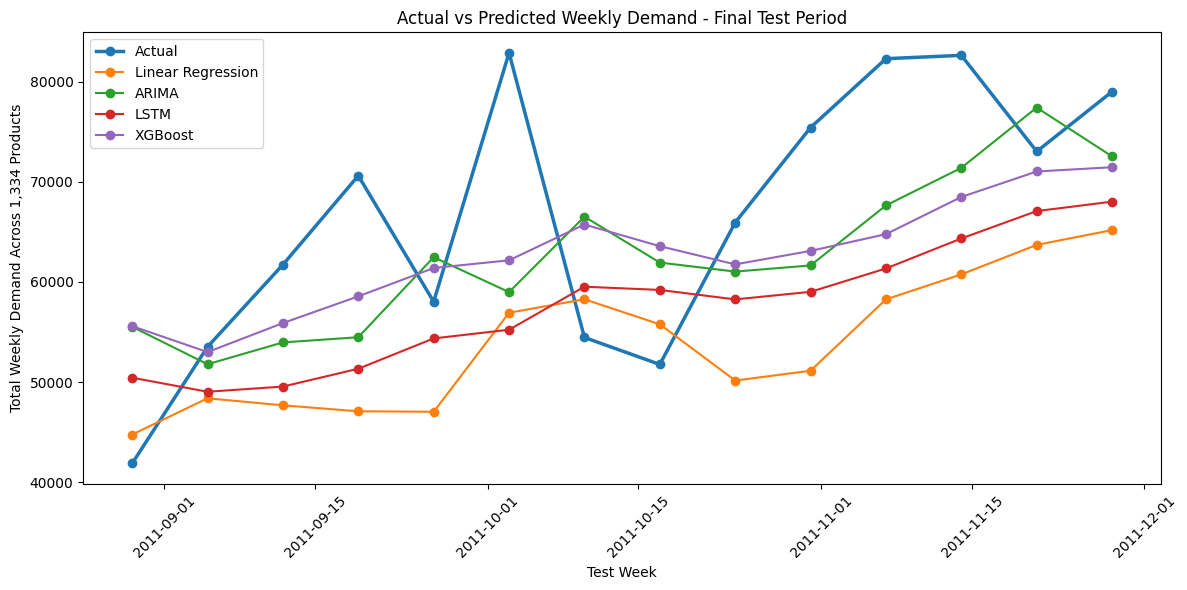

In [331]:
final_test_weekly_plot = (
    final_test_predictions
    .groupby("Week", as_index=False)
    .agg(
        Actual=("WeeklyDemand", "sum"),
        Linear=("LinearPrediction", "sum"),
        XGBoost=("XGBoostPrediction", "sum"),
        LSTM=("LSTMPrediction", "sum"),
        ARIMA=("ARIMAPrediction", "sum")
    )
)

plt.figure(figsize=(12, 6))

plt.plot(
    final_test_weekly_plot["Week"],
    final_test_weekly_plot["Actual"],
    marker="o",
    linewidth=2.5,
    label="Actual"
)

plt.plot(
    final_test_weekly_plot["Week"],
    final_test_weekly_plot["Linear"],
    marker="o",
    label="Linear Regression"
)

plt.plot(
    final_test_weekly_plot["Week"],
    final_test_weekly_plot["ARIMA"],
    marker="o",
    label="ARIMA"
)

plt.plot(
    final_test_weekly_plot["Week"],
    final_test_weekly_plot["LSTM"],
    marker="o",
    label="LSTM"
)

plt.plot(
    final_test_weekly_plot["Week"],
    final_test_weekly_plot["XGBoost"],
    marker="o",
    label="XGBoost"
)

plt.title(
    "Actual vs Predicted Weekly Demand - Final Test Period"
)
plt.xlabel("Test Week")
plt.ylabel("Total Weekly Demand Across 1,334 Products")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Result

The final test predictions were successfully aligned with the actual observations using `StockCode` and `Week`.

The test set contains 18,676 observations across 1,334 products and 14 weeks, and there are no missing predictions for Linear Regression, XGBoost, LSTM, or ARIMA.

The aggregate test-period plot shows that all models broadly follow the overall direction of total weekly demand, but they smooth the series and do not fully capture some of the stronger peaks.

Although ARIMA and LSTM appear visually competitive in some weeks, the final model ranking is still based on the overall test metrics. According to test RMSE, Linear Regression remains the best-performing model overall.

Because the aggregate view may hide product-level errors, the next step is to visualise actual and predicted demand for selected individual products.

## 140. Product-Week Actual vs Predicted Diagnostics

The aggregate weekly demand plot is useful for showing total assortment behaviour, but the formal forecasting evaluation is performed at product-week level. Therefore, the following diagnostic compares actual and predicted values directly across all 18,676 final-test product-week observations.

A density-based plot is used because a standard scatter plot would contain substantial overlap. The diagonal reference line represents perfect predictions.

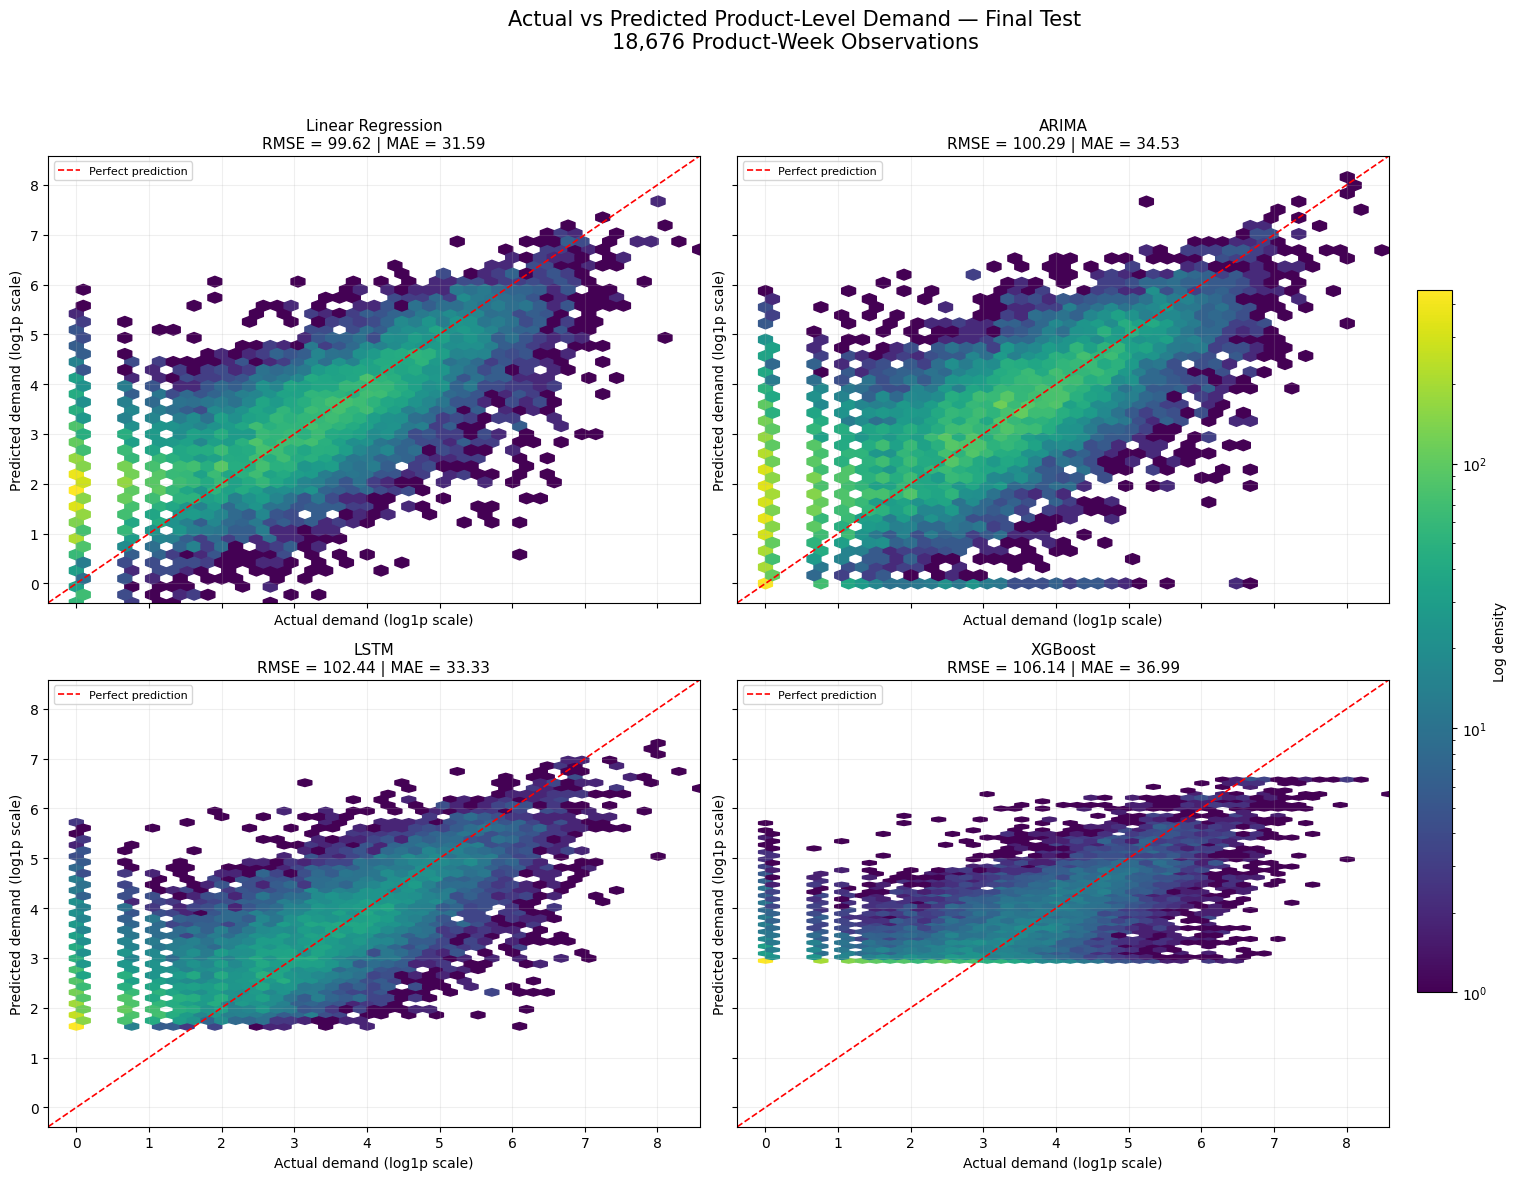

In [332]:
# Final test diagnostic plot: actual vs predicted at product-week level

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Try to find the final test prediction table automatically
if "final_test_predictions" in globals():
    plot_df = final_test_predictions.copy()
elif "final_test_results" in globals():
    plot_df = final_test_results.copy()
elif "test_predictions" in globals():
    plot_df = test_predictions.copy()
elif "all_test_predictions" in globals():
    plot_df = all_test_predictions.copy()
else:
    raise NameError(
        "Could not find the final test prediction dataframe. "
        "Make sure the table with WeeklyDemand, LinearPrediction, "
        "ARIMAPrediction, LSTMPrediction and XGBoostPrediction is already created."
    )

required_cols = [
    "WeeklyDemand",
    "LinearPrediction",
    "ARIMAPrediction",
    "LSTMPrediction",
    "XGBoostPrediction"
]

missing_cols = [col for col in required_cols if col not in plot_df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in prediction dataframe: {missing_cols}")

# Keep only needed columns and clean
plot_df = plot_df[required_cols].copy()
plot_df = plot_df.dropna()

def signed_log1p(x):
    x = np.asarray(x, dtype=float)
    return np.sign(x) * np.log1p(np.abs(x))


plot_df["Actual_log"] = signed_log1p(
    plot_df["WeeklyDemand"]
)

plot_df["Linear_log"] = signed_log1p(
    plot_df["LinearPrediction"]
)

plot_df["ARIMA_log"] = signed_log1p(
    plot_df["ARIMAPrediction"]
)

plot_df["LSTM_log"] = signed_log1p(
    plot_df["LSTMPrediction"]
)

plot_df["XGBoost_log"] = signed_log1p(
    plot_df["XGBoostPrediction"]
)

models = [
    ("Linear Regression", "LinearPrediction", "Linear_log"),
    ("ARIMA", "ARIMAPrediction", "ARIMA_log"),
    ("LSTM", "LSTMPrediction", "LSTM_log"),
    ("XGBoost", "XGBoostPrediction", "XGBoost_log"),
]

# Compute common axis range
all_logs = []
all_logs.append(plot_df["Actual_log"].values)
for _, _, log_col in models:
    all_logs.append(plot_df[log_col].values)

global_min = min(arr.min() for arr in all_logs)
global_max = max(arr.max() for arr in all_logs)

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

hb_for_cbar = None

for ax, (model_name, pred_col, log_col) in zip(axes, models):
    actual = plot_df["WeeklyDemand"].values
    pred = plot_df[pred_col].values

    mae = np.mean(np.abs(actual - pred))
    rmse = np.sqrt(np.mean((actual - pred) ** 2))

    hb = ax.hexbin(
        plot_df["Actual_log"],
        plot_df[log_col],
        gridsize=45,
        bins="log",
        mincnt=1
    )

    if hb_for_cbar is None:
        hb_for_cbar = hb

    ax.plot(
        [global_min, global_max],
        [global_min, global_max],
        "r--",
        linewidth=1.2,
        label="Perfect prediction"
    )

    ax.set_title(f"{model_name}\nRMSE = {rmse:.2f} | MAE = {mae:.2f}", fontsize=11)
    ax.set_xlabel("Actual demand (log1p scale)")
    ax.set_ylabel("Predicted demand (log1p scale)")
    ax.set_xlim(global_min, global_max)
    ax.set_ylim(global_min, global_max)
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(alpha=0.2)

fig.suptitle(
    "Actual vs Predicted Product-Level Demand — Final Test\n18,676 Product-Week Observations",
    fontsize=15,
    y=0.98
)

# Leave space on the right for colorbar so it does NOT overlap
fig.tight_layout(rect=[0, 0, 0.92, 0.95])

cbar = fig.colorbar(hb_for_cbar, ax=axes, fraction=0.025, pad=0.02)
cbar.set_label("Log density")

plt.show()

**Interpretation:**  
The product-week diagnostic shows that forecast accuracy varies across the demand range. Predictions are concentrated around typical demand levels, while very high-demand observations are frequently underpredicted. This indicates that sudden and extreme product-week demand is a major source of forecasting error. Linear Regression achieves the lowest observed overall RMSE, although substantial dispersion remains across all models.

## 141. Forecast Performance Across Actual Demand Levels

To examine whether forecast behaviour changes with the magnitude of realised demand, final-test observations are grouped according to their actual weekly demand. The average actual value and average model prediction are then compared within each group.

,ActualDemandGroup,Actual,Linear,ARIMA,LSTM,XGBoost,Observations
0,0,0.00,9.69,11.86,12.92,22.19,3387
1,1–10,4.16,12.04,13.96,15.21,22.78,5569
2,11–25,17.14,23.66,27.94,28.08,31.77,3162
3,26–50,36.37,38.99,47.66,44.33,46.00,2360
4,51–100,71.50,63.01,73.10,67.31,67.37,1952
5,101–250,154.27,116.57,131.67,115.95,112.04,1499
6,251–500,344.35,185.12,210.21,182.71,175.57,485
7,501–1000,680.62,327.50,354.10,301.65,277.57,208
8,1000+,"1,677.72",607.39,796.05,525.57,429.65,54


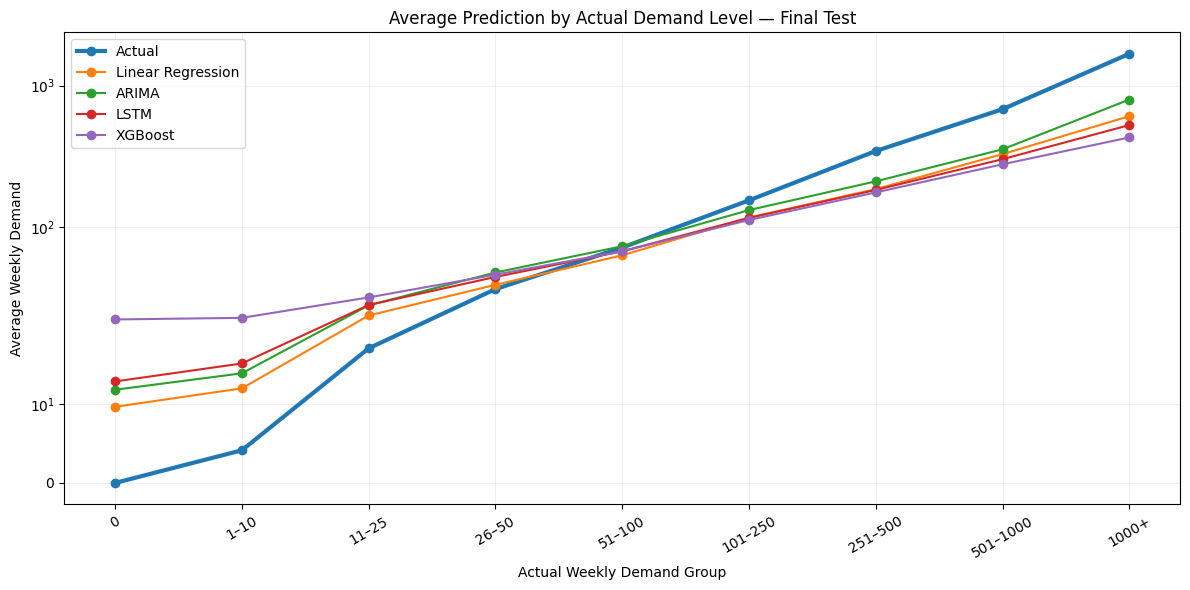

In [333]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


demand_analysis = (
    final_test_predictions
    .copy()
)


bins = [
    -0.1,
    0,
    10,
    25,
    50,
    100,
    250,
    500,
    1000,
    np.inf
]

labels = [
    "0",
    "1–10",
    "11–25",
    "26–50",
    "51–100",
    "101–250",
    "251–500",
    "501–1000",
    "1000+"
]


demand_analysis[
    "ActualDemandGroup"
] = pd.cut(
    demand_analysis[
        "WeeklyDemand"
    ],
    bins=bins,
    labels=labels,
    include_lowest=True
)


demand_group_summary = (
    demand_analysis
    .groupby(
        "ActualDemandGroup",
        observed=False
    )
    .agg(
        Actual=(
            "WeeklyDemand",
            "mean"
        ),
        Linear=(
            "LinearPrediction",
            "mean"
        ),
        ARIMA=(
            "ARIMAPrediction",
            "mean"
        ),
        LSTM=(
            "LSTMPrediction",
            "mean"
        ),
        XGBoost=(
            "XGBoostPrediction",
            "mean"
        ),
        Observations=(
            "WeeklyDemand",
            "size"
        )
    )
    .reset_index()
)


display(
    demand_group_summary.round(2)
)


plt.figure(
    figsize=(12, 6)
)


plt.plot(
    demand_group_summary[
        "ActualDemandGroup"
    ].astype(str),
    demand_group_summary[
        "Actual"
    ],
    marker="o",
    linewidth=3,
    label="Actual"
)


plt.plot(
    demand_group_summary[
        "ActualDemandGroup"
    ].astype(str),
    demand_group_summary[
        "Linear"
    ],
    marker="o",
    label="Linear Regression"
)


plt.plot(
    demand_group_summary[
        "ActualDemandGroup"
    ].astype(str),
    demand_group_summary[
        "ARIMA"
    ],
    marker="o",
    label="ARIMA"
)


plt.plot(
    demand_group_summary[
        "ActualDemandGroup"
    ].astype(str),
    demand_group_summary[
        "LSTM"
    ],
    marker="o",
    label="LSTM"
)


plt.plot(
    demand_group_summary[
        "ActualDemandGroup"
    ].astype(str),
    demand_group_summary[
        "XGBoost"
    ],
    marker="o",
    label="XGBoost"
)


plt.title(
    "Average Prediction by Actual Demand Level — Final Test"
)

plt.xlabel(
    "Actual Weekly Demand Group"
)

plt.ylabel(
    "Average Weekly Demand"
)

# Allows low and very high demand groups
# to remain visible on the same figure.
plt.yscale(
    "symlog",
    linthresh=20
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.xticks(
    rotation=30
)

plt.tight_layout()


plt.savefig(
    "/content/final_prediction_by_demand_level.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Interpretation:**  
Forecast behaviour varies substantially across realised demand levels. Predictions are relatively close to actual demand in the middle-demand groups, but the models increasingly underpredict as realised demand becomes larger. For observations above 1,000 units, the average actual demand is approximately 1,678 units, while average predictions remain substantially lower across all models. This provides direct evidence that sudden high-demand observations are a major source of forecasting error.

This analysis is descriptive and should not be interpreted as a causal relationship between realised demand level and forecasting error.

## 142. Distribution of Product-Week Forecast Errors

The overall RMSE provides a single summary measure, but it does not show how forecasting errors are distributed across individual observations. The following plot therefore compares the distribution of absolute product-week forecast errors across the four main models.

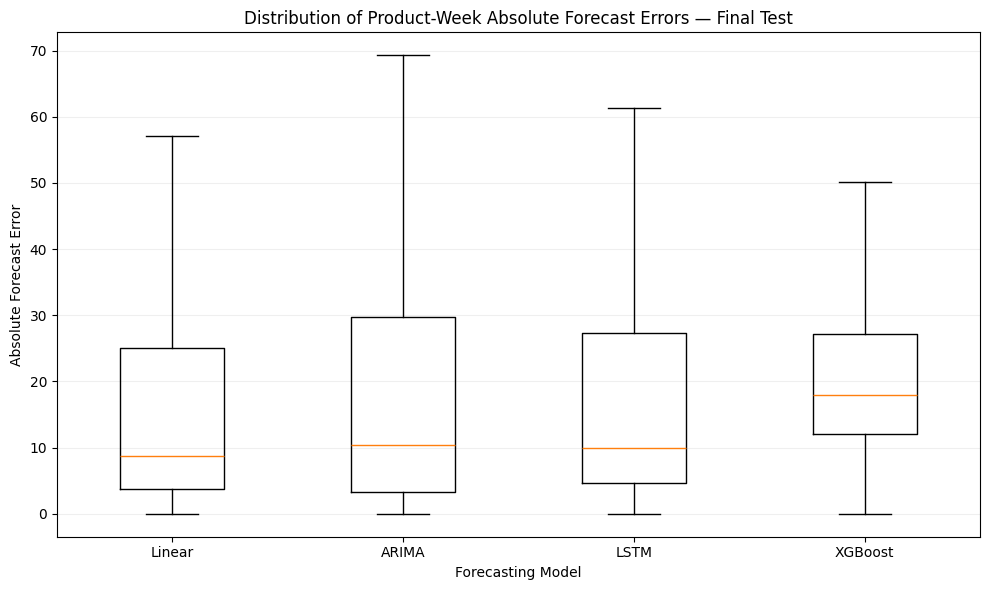

In [334]:
import numpy as np
import matplotlib.pyplot as plt


model_columns = {
    "Linear": "LinearPrediction",
    "ARIMA": "ARIMAPrediction",
    "LSTM": "LSTMPrediction",
    "XGBoost": "XGBoostPrediction"
}


absolute_error_data = []


for (
    model_name,
    prediction_column
) in model_columns.items():

    absolute_errors = np.abs(
        final_test_predictions[
            "WeeklyDemand"
        ]
        -
        final_test_predictions[
            prediction_column
        ]
    )

    absolute_error_data.append(
        absolute_errors
    )


plt.figure(
    figsize=(10, 6)
)


plt.boxplot(
    absolute_error_data,
    labels=model_columns.keys(),
    showfliers=False
)


plt.title(
    "Distribution of Product-Week Absolute Forecast Errors — Final Test"
)

plt.xlabel(
    "Forecasting Model"
)

plt.ylabel(
    "Absolute Forecast Error"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()


plt.savefig(
    "/content/final_absolute_error_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Interpretation:**  
Linear Regression has the lowest median absolute product-week error and a relatively compact central error distribution. ARIMA and LSTM remain close, while XGBoost shows a higher typical absolute error. This is consistent with the overall final-test ranking, although the boxplot excludes extreme outliers from display and therefore should be interpreted together with RMSE.

## 143. Product-Level Forecast Examples on the Final Test Set

To complement the aggregate test-period graph, I visualise forecasts for several higher-demand products.

These examples show how the models behave at product level and illustrate forecasting patterns that may be hidden when demand is aggregated across all 1,334 products.

In [335]:
product_test_totals = (
    final_test_predictions
    .groupby("StockCode", as_index=False)["WeeklyDemand"]
    .sum()
    .rename(columns={"WeeklyDemand": "TestTotalDemand"})
    .sort_values("TestTotalDemand", ascending=False)
)

display(product_test_totals.head(10))

,StockCode,TestTotalDemand
646,22197,"22,979.00"
1289,85099B,"15,308.00"
1176,84077,"15,158.00"
567,22086,"13,627.00"
1226,84879,"10,843.00"
477,21915,"9,080.00"
911,22577,"8,976.00"
1296,85123A,"8,394.00"
44,20668,"7,512.00"
781,22386,"7,258.00"


In [336]:
selected_plot_products = [
    product_test_totals.iloc[0]["StockCode"],
    product_test_totals.iloc[4]["StockCode"],
    product_test_totals.iloc[9]["StockCode"],
    product_test_totals.iloc[49]["StockCode"]
]

print("Selected products:", selected_plot_products)

Selected products: ['22197', '84879', '22386', '21232']


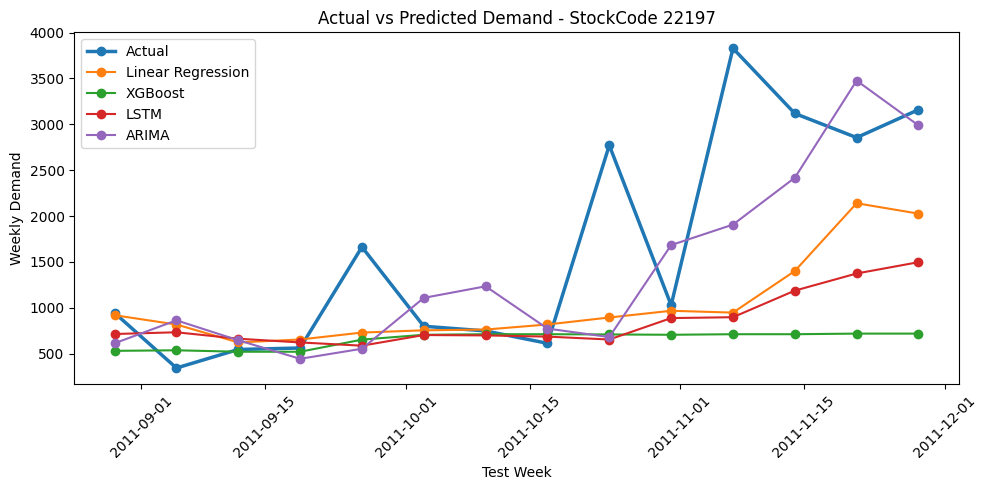

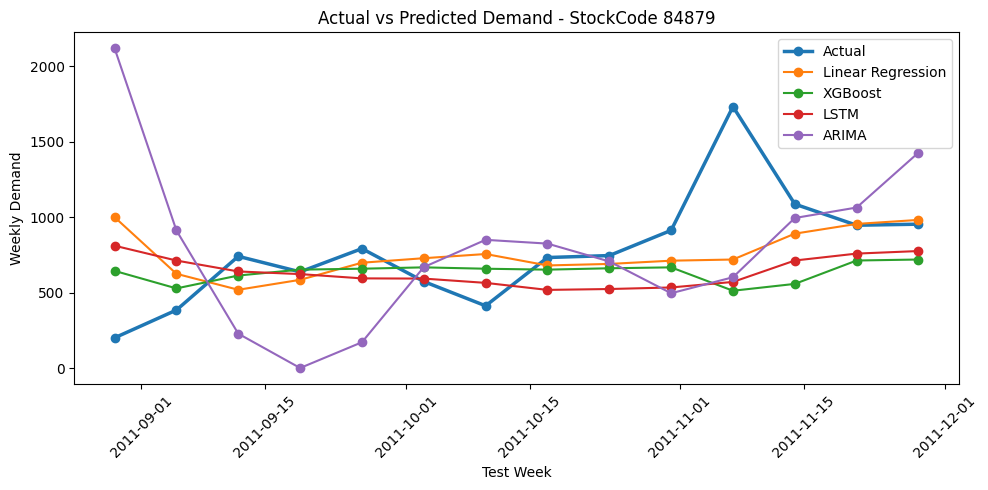

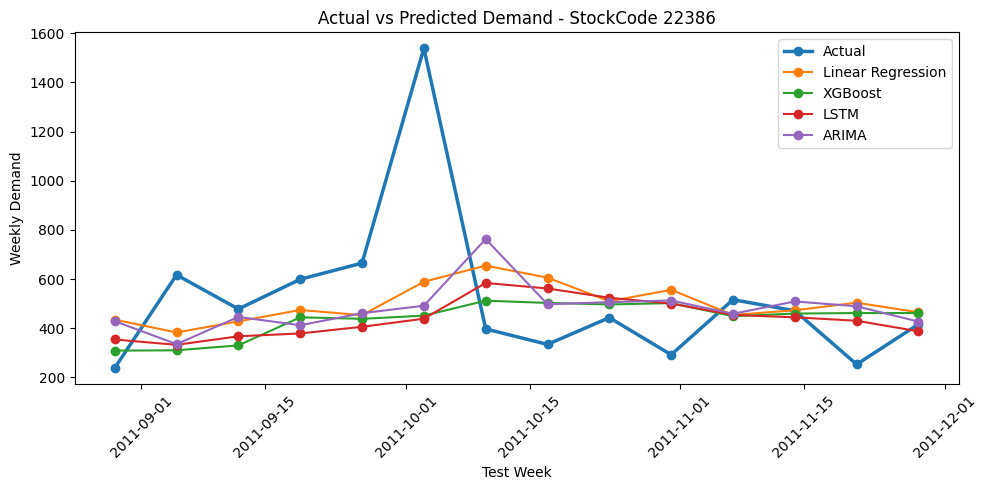

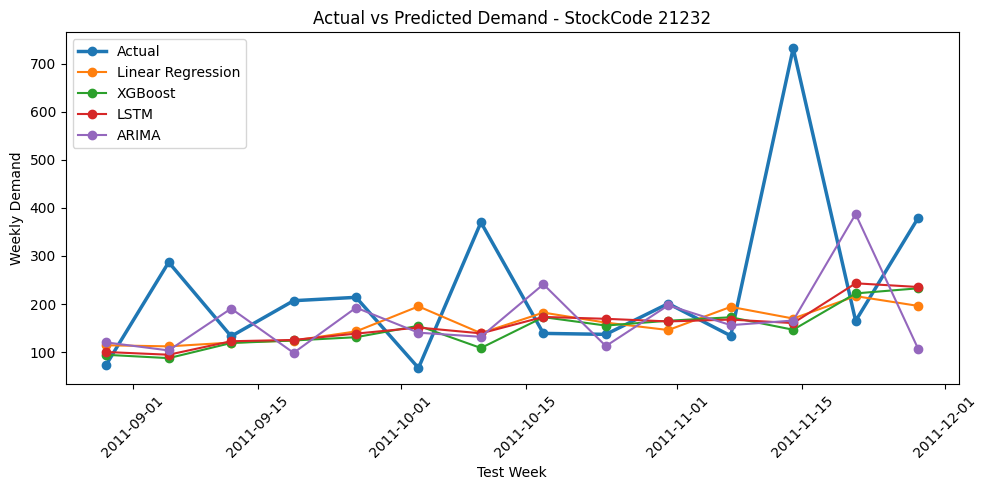

In [337]:
for product_code in selected_plot_products:

    product_plot_data = (
        final_test_predictions[
            final_test_predictions["StockCode"] == product_code
        ]
        .sort_values("Week")
    )

    plt.figure(figsize=(10, 5))

    plt.plot(
        product_plot_data["Week"],
        product_plot_data["WeeklyDemand"],
        marker="o",
        linewidth=2.5,
        label="Actual"
    )

    plt.plot(
        product_plot_data["Week"],
        product_plot_data["LinearPrediction"],
        marker="o",
        label="Linear Regression"
    )

    plt.plot(
        product_plot_data["Week"],
        product_plot_data["XGBoostPrediction"],
        marker="o",
        label="XGBoost"
    )

    plt.plot(
        product_plot_data["Week"],
        product_plot_data["LSTMPrediction"],
        marker="o",
        label="LSTM"
    )

    plt.plot(
        product_plot_data["Week"],
        product_plot_data["ARIMAPrediction"],
        marker="o",
        label="ARIMA"
    )

    plt.title(f"Actual vs Predicted Demand - StockCode {product_code}")
    plt.xlabel("Test Week")
    plt.ylabel("Weekly Demand")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Result

The product-level plots show substantial differences in forecasting behaviour across products.

The models generally capture the underlying demand level but tend to smooth sudden demand spikes. ARIMA reacts more strongly to recent changes for some products, while Linear Regression, XGBoost, and LSTM often produce more stable forecasts.

No single model visually dominates across all selected products, supporting the need for a product-level evaluation rather than relying only on aggregate performance.

## 144. Product-Level Model Performance on the Final Test Set

The overall test metrics identify the strongest model across all observations, but they do not show whether the same model performs best for every product.

I therefore calculate a separate test RMSE for each of the 1,334 products and identify the best-performing forecasting approach for each product.

This analysis directly supports the product-level model suitability objective of the dissertation.

In [338]:
final_product_test_rows = []

for stock_code, group in final_test_predictions.groupby("StockCode"):

    final_product_test_rows.append({
        "StockCode": stock_code,

        "LinearRMSE": np.sqrt(
            mean_squared_error(
                group["WeeklyDemand"],
                group["LinearPrediction"]
            )
        ),

        "XGBoostRMSE": np.sqrt(
            mean_squared_error(
                group["WeeklyDemand"],
                group["XGBoostPrediction"]
            )
        ),

        "LSTMRMSE": np.sqrt(
            mean_squared_error(
                group["WeeklyDemand"],
                group["LSTMPrediction"]
            )
        ),

        "ARIMARMSE": np.sqrt(
            mean_squared_error(
                group["WeeklyDemand"],
                group["ARIMAPrediction"]
            )
        )
    })

final_product_test_analysis = pd.DataFrame(
    final_product_test_rows
)

test_rmse_columns = [
    "LinearRMSE",
    "XGBoostRMSE",
    "LSTMRMSE",
    "ARIMARMSE"
]

final_product_test_analysis["BestModel"] = (
    final_product_test_analysis[
        test_rmse_columns
    ]
    .idxmin(axis=1)
    .str.replace("RMSE", "", regex=False)
)

final_test_winners = (
    final_product_test_analysis["BestModel"]
    .value_counts()
    .rename_axis("Model")
    .reset_index(name="Products")
)

final_test_winners["Percentage"] = (
    final_test_winners["Products"]
    / len(final_product_test_analysis)
    * 100
)

print("Products evaluated:",
      len(final_product_test_analysis))

display(
    final_test_winners.round(2)
)

Products evaluated: 1334


,Model,Products,Percentage
0,ARIMA,498,37.33
1,Linear,379,28.41
2,LSTM,271,20.31
3,XGBoost,186,13.94


### Result

The final test results show substantial variation in the best-performing model across individual products.

ARIMA achieves the lowest product-level RMSE for 498 products (37.33%), followed by Linear Regression for 379 products (28.41%), LSTM for 271 products (20.31%), and XGBoost for 186 products (13.94%).

This differs from the pooled overall test comparison, where Linear Regression achieves the lowest RMSE. The difference occurs because the pooled RMSE is influenced more strongly by higher-demand products and large forecasting errors, whereas the product-level comparison gives each product equal importance.

These results provide strong evidence that there is no universally best forecasting model across all retail products.

## 145. Demand Characteristics by Final Test Winner

I now investigate whether the model that performs best on the final test period is associated with the historical demand characteristics of each product.

To avoid using future test behaviour to describe the products, demand characteristics are calculated only from the 90 weeks available before the test period.

I compare demand level, volatility, skewness, and zero-demand frequency across the products won by each forecasting model.

In [339]:
pretest_product_characteristics = (
    larger_weekly_demand[
        larger_weekly_demand["Week"] < test_weeks[0]
    ]
    .groupby("StockCode")["WeeklyDemand"]
    .agg(
        MeanDemand="mean",
        DemandStd="std",
        DemandSkew="skew"
    )
    .reset_index()
)

pretest_zero_demand = (
    larger_weekly_demand[
        larger_weekly_demand["Week"] < test_weeks[0]
    ]
    .assign(
        ZeroDemand=lambda x: x["WeeklyDemand"] == 0
    )
    .groupby("StockCode")["ZeroDemand"]
    .mean()
    .mul(100)
    .reset_index(name="ZeroDemandPct")
)

pretest_product_characteristics = (
    pretest_product_characteristics
    .merge(
        pretest_zero_demand,
        on="StockCode",
        how="left"
    )
)

pretest_product_characteristics["StockCode"] = (
    pretest_product_characteristics["StockCode"]
    .astype(str)
)

final_product_test_analysis["StockCode"] = (
    final_product_test_analysis["StockCode"]
    .astype(str)
)

final_test_characteristic_analysis = (
    final_product_test_analysis
    .merge(
        pretest_product_characteristics,
        on="StockCode",
        how="left"
    )
)

winner_characteristics = (
    final_test_characteristic_analysis
    .groupby("BestModel")
    .agg(
        Products=("StockCode", "count"),
        MedianDemand=("MeanDemand", "median"),
        MedianDemandStd=("DemandStd", "median"),
        MedianSkew=("DemandSkew", "median"),
        MedianZeroDemandPct=("ZeroDemandPct", "median")
    )
    .sort_values("Products", ascending=False)
)

display(winner_characteristics.round(2))

,Products,MedianDemand,MedianDemandStd,MedianSkew,MedianZeroDemandPct
BestModel,,,,,
ARIMA,498,15.43,25.31,2.77,22.78
Linear,379,20.88,37.54,2.96,22.22
LSTM,271,21.78,36.80,2.83,21.11
XGBoost,186,36.21,53.24,2.74,17.78


### Result

The final test results show some differences in historical demand characteristics across the products won by each model.

ARIMA performs best more often for products with lower median demand and lower demand volatility, while XGBoost is associated with higher-demand and higher-volatility products.

Linear Regression and LSTM show relatively similar median demand characteristics, and skewness differs only slightly across the four winner groups.

Overall, demand level and volatility appear to be more informative for model suitability than skewness alone.

## 146. Best Model Across Demand and Volatility Levels

To make the relationship between product characteristics and model suitability easier to interpret, I divide products into quartiles based on their pre-test demand level and volatility.

I then calculate the percentage of products won by each forecasting model within each group.

In [340]:
final_test_characteristic_analysis["DemandLevel"] = pd.qcut(
    final_test_characteristic_analysis["MeanDemand"],
    q=4,
    labels=[
        "Low",
        "Medium-Low",
        "Medium-High",
        "High"
    ]
)

final_test_characteristic_analysis["VolatilityLevel"] = pd.qcut(
    final_test_characteristic_analysis["DemandStd"],
    q=4,
    labels=[
        "Low",
        "Medium-Low",
        "Medium-High",
        "High"
    ]
)

demand_winner_share = (
    pd.crosstab(
        final_test_characteristic_analysis["DemandLevel"],
        final_test_characteristic_analysis["BestModel"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

volatility_winner_share = (
    pd.crosstab(
        final_test_characteristic_analysis["VolatilityLevel"],
        final_test_characteristic_analysis["BestModel"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

print("Best Model Across Demand Levels:")
display(demand_winner_share)

print("\nBest Model Across Volatility Levels:")
display(volatility_winner_share)

Best Model Across Demand Levels:


BestModel,ARIMA,LSTM,Linear,XGBoost
DemandLevel,,,,
Low,56.59,16.47,23.05,3.89
Medium-Low,32.13,23.12,34.23,10.51
Medium-High,27.25,21.86,28.74,22.16
High,33.33,19.82,27.63,19.22



Best Model Across Volatility Levels:


BestModel,ARIMA,LSTM,Linear,XGBoost
VolatilityLevel,,,,
Low,55.39,17.96,22.46,4.19
Medium-Low,35.74,21.32,31.53,11.41
Medium-High,25.83,22.82,30.63,20.72
High,32.34,19.16,29.04,19.46


### Result

ARIMA is clearly the most frequent winner for products with low demand and low volatility, winning approximately 56% of products in both groups.

As demand level and volatility increase, ARIMA becomes less dominant and XGBoost becomes more competitive. Linear Regression performs particularly strongly in the middle demand and volatility groups, while LSTM remains relatively stable across the different categories.

The relationship is not perfectly monotonic, especially in the highest groups, so these results should be interpreted as differences in model suitability rather than a strict rule.

Overall, the final test results confirm that the best forecasting approach varies with product demand characteristics.

## 147. Best Model Across Demand Sparsity Levels

I also examine whether model suitability varies with demand sparsity.

Products are divided into four groups according to their pre-test zero-demand frequency. I then compare the percentage of products won by each forecasting model within each sparsity group.

The sparsity measure is calculated only from observations available before the final test period.

In [341]:
final_test_characteristic_analysis["SparsityLevel"] = pd.qcut(
    final_test_characteristic_analysis["ZeroDemandPct"],
    q=4,
    labels=[
        "Low",
        "Medium-Low",
        "Medium-High",
        "High"
    ]
)

sparsity_winner_share = (
    pd.crosstab(
        final_test_characteristic_analysis["SparsityLevel"],
        final_test_characteristic_analysis["BestModel"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

print("Best Model Across Demand Sparsity Levels:")
display(sparsity_winner_share)

Best Model Across Demand Sparsity Levels:


BestModel,ARIMA,LSTM,Linear,XGBoost
SparsityLevel,,,,
Low,33.24,21.59,27.56,17.61
Medium-Low,36.65,18.63,28.57,16.15
Medium-High,45.40,18.10,25.52,10.98
High,34.06,22.91,32.20,10.84


### Result

Model suitability also varies across sparsity levels, although the relationship is not strictly monotonic.

ARIMA is the most frequent winner in the medium-high sparsity group, where it performs best for 45.40% of products. In the highest sparsity group, Linear Regression and LSTM become more competitive, while XGBoost has its lowest winner share.

These results suggest that sparsity influences model suitability, but it does not determine the best model on its own.

## 148. Demand Characteristics and Final Test Forecasting Error

To complement the model-winner analysis, I examine how product demand characteristics are related to forecasting difficulty on the final test set.

I compare pre-test demand level, volatility, skewness, and zero-demand frequency with both raw RMSE and normalized RMSE for each forecasting model.

Normalized RMSE is included because raw RMSE is naturally affected by product demand scale.

In [342]:
# Normalized RMSE for each model
for model in ["Linear", "XGBoost", "LSTM", "ARIMA"]:
    final_test_characteristic_analysis[f"{model}NRMSE"] = (
        final_test_characteristic_analysis[f"{model}RMSE"]
        / final_test_characteristic_analysis["MeanDemand"].clip(lower=1)
    )

characteristic_columns = [
    "MeanDemand",
    "DemandStd",
    "DemandSkew",
    "ZeroDemandPct"
]

error_columns_test = [
    "LinearRMSE",
    "XGBoostRMSE",
    "LSTMRMSE",
    "ARIMARMSE",
    "LinearNRMSE",
    "XGBoostNRMSE",
    "LSTMNRMSE",
    "ARIMANRMSE"
]

final_test_pearson = (
    final_test_characteristic_analysis[
        characteristic_columns + error_columns_test
    ]
    .corr(method="pearson")
    .loc[
        characteristic_columns,
        error_columns_test
    ]
)

final_test_spearman = (
    final_test_characteristic_analysis[
        characteristic_columns + error_columns_test
    ]
    .corr(method="spearman")
    .loc[
        characteristic_columns,
        error_columns_test
    ]
)

print("Pearson Correlations:")
display(final_test_pearson.round(2))

print("\nSpearman Correlations:")
display(final_test_spearman.round(2))

Pearson Correlations:


,LinearRMSE,XGBoostRMSE,LSTMRMSE,ARIMARMSE,LinearNRMSE,XGBoostNRMSE,LSTMNRMSE,ARIMANRMSE
MeanDemand,0.71,0.69,0.70,0.73,-0.10,-0.20,-0.10,-0.09
DemandStd,0.58,0.57,0.58,0.62,-0.08,-0.17,-0.08,-0.06
DemandSkew,-0.10,-0.08,-0.09,-0.08,0.04,0.08,0.04,0.05
ZeroDemandPct,-0.22,-0.20,-0.21,-0.22,0.18,0.30,0.18,0.17



Spearman Correlations:


,LinearRMSE,XGBoostRMSE,LSTMRMSE,ARIMARMSE,LinearNRMSE,XGBoostNRMSE,LSTMNRMSE,ARIMANRMSE
MeanDemand,0.72,0.65,0.72,0.74,-0.20,-0.62,-0.23,-0.08
DemandStd,0.66,0.62,0.67,0.70,-0.18,-0.53,-0.20,-0.04
DemandSkew,-0.18,-0.14,-0.17,-0.14,-0.00,0.14,0.01,0.04
ZeroDemandPct,-0.32,-0.27,-0.32,-0.32,0.28,0.45,0.29,0.23


### Result

Raw RMSE is strongly related to product demand scale across all four models, with correlations around 0.7. Demand volatility also shows a clear positive relationship with absolute forecasting error.

After adjusting RMSE for product scale, skewness shows very little consistent relationship with forecasting difficulty. Zero-demand frequency shows a clearer positive relationship with normalized error, particularly for XGBoost.

Overall, the final test results suggest that demand scale explains much of the variation in raw RMSE, while sparsity is more informative than skewness for scale-adjusted forecasting difficulty.

## 149. Final Answers to the Research Questions

### RQ1: Which forecasting approach provides the most accurate weekly product-level demand forecasts?

Based on the primary RMSE metric on the untouched final test set, **Linear Regression performs best overall**, with an RMSE of **99.62**.

ARIMA follows very closely with an RMSE of **100.29**, followed by LSTM at **102.44** and XGBoost at **106.14**. All four main forecasting approaches outperform the Naive and Seasonal Naive baselines on RMSE.

### RQ2: How does forecasting performance vary across products with different demand characteristics?

Forecasting performance varies substantially across products.

Raw forecasting error is strongly related to demand scale and volatility. After adjusting for scale, demand skewness has little consistent relationship with forecasting error, while zero-demand frequency shows a clearer relationship with forecasting difficulty.

The best-performing model also varies across demand characteristics. ARIMA is particularly competitive for low-demand and low-volatility products, while XGBoost becomes more competitive among products with higher demand and volatility.

### RQ3: Are different forecasting approaches better suited to different types of product demand?

Yes. The final product-level test analysis shows that no single model performs best for every product.

ARIMA achieves the lowest RMSE for **498 products (37.33%)**, Linear Regression for **379 (28.41%)**, LSTM for **271 (20.31%)**, and XGBoost for **186 (13.94%)**.

Therefore, although Linear Regression is the strongest model overall, product-level model suitability varies considerably across the retail assortment.

## 150. Research Contribution

The main contribution of this dissertation goes beyond generating future demand forecasts.

First, I develop and evaluate a product-level weekly demand forecasting framework across 1,334 retail products using multiple forecasting approaches, including statistical, machine-learning, deep-learning, and baseline methods.

Second, I show that the model with the best overall forecasting accuracy is not necessarily the best model for every product. While Linear Regression achieves the lowest overall test RMSE, ARIMA is the best-performing model for the largest number of individual products.

Third, I investigate how model suitability varies with historical product demand characteristics such as demand level, volatility, sparsity, and skewness.

Overall, the study contributes a more product-specific view of retail demand forecasting and provides evidence that forecasting model selection should consider product demand characteristics rather than relying on a single model for the entire assortment.

## 151. Practical Implications

The results suggest that a retailer does not necessarily need to apply one forecasting model to every product.

A simple model such as Linear Regression can provide strong overall performance, while ARIMA, LSTM, or XGBoost may be more suitable for specific subsets of products.

This means that a product segmentation or model-selection strategy could potentially improve forecasting performance by assigning different models to products with different demand characteristics.

However, the current analysis is empirical and should be interpreted as evidence of model suitability rather than as a fixed automated selection rule.

## 152. Key Limitations

Several limitations should be considered when interpreting the results.

The dataset covers a single online retailer and a limited historical period, so the findings may not generalise directly to other industries or retail environments.

The product eligibility criteria were defined retrospectively using the full product history. Although these criteria are not used as forecasting features, a fully prospective operational system should ideally determine product eligibility using only information available before the forecast origin.

The current evaluation uses rolling one-step-ahead forecasting. It does not evaluate a fully recursive multi-week forecast generated from a single forecast origin.

Finally, some products contain sparse and highly irregular demand, which makes percentage-based metrics such as sMAPE difficult to interpret.